In [7]:
from spd.models.component_utils import (
    # calc_component_acts,
    calc_causal_importances,
    calc_stochastic_masks,
    calc_ci_l_zero,
    component_activation_statistics,
)

from spd.utils import calc_kl_divergence_lm
from spd.models.components import EmbeddingComponent, Gate, GateMLP, LinearComponent
from transformers import AutoTokenizer
import torch
from spd.models.component_model import ComponentModel
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
# model_path = "out/last_mlp/model_50000.pth"
# model_path = "out/decent_run/model_50000.pth"
# model_path = "out/decent_run_100k/model_100000.pth"
# model_path = "out/nmasks1_stochrecon3.00e-01_p2.00e+00_impmin1.00e+00_C300_sd0_lr1.00e-04_bs2_rmsimportance_mlp__pretrainedroneneldan/TinyStories-1M_seq64_20250707_193819_485/model_50000.pth"
# model_path = "out/pnorm_0_5/model_50000.pth"
# model_dir = "out/clamp=1.0e+00_stoch=3.0e-03_all=1.0e-01/"
# model_dir = "out/clamp=1.0e+00_stoch=1.0e+00_all=1.0e-01/"
# model_dir = "out/clamp=3.0e-01_stoch=1.0e+00_all=1.0e-01/"
model_dir = "out/clamp=1.0e+00_stoch=1.0e-03_all=1.0e+00_fill=True_rem_ded=False_fil_scalar=1.0_faith=1.0/"
steps = 40000
model_path = os.path.join(model_dir, f"model_{steps}.pth")
config_path = os.path.join(model_dir, f"final_config.yaml")
model, config, out_dir = ComponentModel.from_pretrained(model_path)
model.to(device)
model.requires_grad_(False)
model_name = "roneneldan/TinyStories-1M"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Create dataloader
dataset = load_dataset("roneneldan/TinyStories", split="train[:10_000]")


# Track specific components
target_modules = {
    config.target_module_patterns[0]: [i for i in range(100)],  # module: component_idx
}

module_comp = [key.replace('-', '.') for key in model.components.keys()]


# text = " Once upon a time, a boy named"
text = "One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt."
tokens = torch.tensor([tokenizer.encode(text)])

gates: dict[str, Gate | GateMLP] = {
    k.removeprefix("gates.").replace("-", "."): v for k, v in model.gates.items()
}  # type: ignore
components: dict[str, LinearComponent | EmbeddingComponent] = {
    k.removeprefix("components.").replace("-", "."): v for k, v in model.components.items()
}  
As = {module_name: components[module_name].A for module_name in components}
with torch.no_grad():
    orig_logits, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
        tokens.to(device),
        module_names = module_comp
    )
    # target_component_acts = calc_component_acts(pre_weight_acts=pre_weight_acts, As=As)  # type: ignore
    causal_importances, causal_importances_upper_leaky = calc_causal_importances(
        pre_weight_acts=pre_weight_acts, As=As, gates=gates, detach_inputs=False
    )

    # new_mask = masks.copy()
    # new_mask['transformer.h.7.mlp.c_fc'][0, 6, 1534]  = 0.0
    masked_logits = model.forward_with_components(
        tokens.to(device),
        # components=model.components,
        components=components,
        masks=causal_importances
        # masks=new_mask,
    )
    stochastic_masks = calc_stochastic_masks(causal_importances, n_mask_samples=1)[0]
    logits_stochastic = model.forward_with_components(
        tokens.to(device),
        components=components,
        masks=stochastic_masks
    )

    ones_mask = {k: torch.ones_like(v) for k, v in causal_importances.items()}
    logits_ones = model.forward_with_components(
        tokens.to(device),
        components=components,
        masks=ones_mask
    )
    
# seq_pos = -2
# val, idx = logits_masked_softmax[:, seq_pos].topk(10)
# val_o, idx_o = orig_logits[:, seq_pos].topk(10)
# print(f"Original: {tokenizer.batch_decode(idx)}, {tokenizer.batch_decode(idx_o)}")

# val_s, idx_s = logits_stochastic[:, seq_pos].topk(10)
# print(f"Stochastic: {tokenizer.batch_decode(idx_s)}")

from torch.nn import functional as F

# logits_masked_softmax = F.log_softmax(masked_logits, dim=-1)
# logits_stochastic_softmax = F.log_softmax(logits_stochastic, dim=-1)
# logits_original_softmax = F.log_softmax(orig_logits, dim=-1)

kl_div_masked = calc_kl_divergence_lm(masked_logits, orig_logits)
print(f"KL-divergence masked: {kl_div_masked:.3f}")
kl_div_stochastic = calc_kl_divergence_lm(logits_stochastic, orig_logits)
print(f"KL-divergence stochast: {kl_div_stochastic:.3f}")
ones_kl_div = calc_kl_divergence_lm(logits_ones, orig_logits)
print(f"KL-divergence unmasked: {ones_kl_div:.3f}")

Filler comp: True
KL-divergence masked: 0.089
KL-divergence stochast: 1.058
KL-divergence unmasked: 0.093


In [8]:
config

Config(wandb_project='spd-lm', wandb_run_name='hist_test', wandb_run_name_prefix='', seed=0, C=1000, n_mask_samples=1, target_module_patterns=['transformer.h.3.mlp.c_fc'], faithfulness_coeff=1.0, importance_minimality_coeff=0.008, pnorm=1.0, pnorm_min=0.5, pannealing=False, p_anneal_schedule_type='cosine', p_anneal_steps=None, p_anneal_warmup_pct=0.6, schatten_coeff=None, recon_coeff=None, filler_recon_coeff=None, clamped_recon_coeff=1.0, stochastic_recon_coeff=0.001, recon_layerwise_coeff=None, stochastic_recon_layerwise_coeff=None, all_components_recon_coeff=1.0, embedding_recon_coeff=None, is_embed_unembed_recon=False, output_loss_type='kl', learned_filler_comp=True, remove_dead_components=False, max_filler_scalar=1.0, init_filler_comp_to_residual=False, faithfulness_scale=None, lr=0.0001, steps=40000, batch_size=4, lr_schedule='constant', lr_exponential_halflife=None, lr_warmup_pct=0.03, n_eval_steps=500, image_freq=5000, image_on_first_step=True, print_freq=200, check_dead_compone

# Cos Sim Graphs

# Data based

In [9]:
# set up dataloader 
from spd.data import DatasetConfig, create_data_loader
batch_size = 4

# split = 'train'
eval_data_config = DatasetConfig(
    name=config.task_config.dataset_name,
    hf_tokenizer_path=config.pretrained_model_name_hf,
    split=config.task_config.eval_data_split,
    n_ctx=config.task_config.max_seq_len,
    is_tokenized=False,
    streaming=False,
    column_name=config.task_config.column_name,
)
eval_loader, _ = create_data_loader(
    dataset_config=eval_data_config,
    batch_size=batch_size,
    buffer_size=config.task_config.buffer_size,
    global_seed=config.seed,
    ddp_rank=0,
    ddp_world_size=1,
)
print(f" eval dataset name: {eval_data_config.name}")
print(f" split: {eval_data_config.split}")
print(f" number of batches: {len(eval_loader)}")

 eval dataset name: roneneldan/TinyStories
 split: validation[:10_000]
 number of batches: 7990


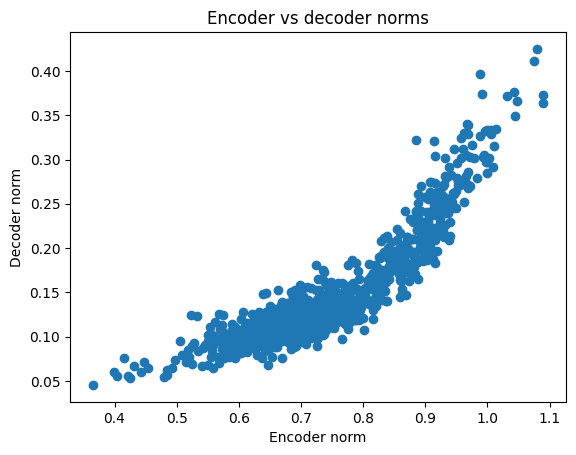

In [10]:
from matplotlib import pyplot as plt

# We want to find all the feautres that activate on a large-dataset. Mostly just keeping up w/ frequency.
module_name = config.target_module_patterns[0]
comp_encoders = components[module_name].A # [d_model, n_components]
comp_decoders = components[module_name].B

enc_norms = comp_encoders.norm(dim=0)
dec_norms = comp_decoders.norm(dim=1)

# plot both against each other
plt.scatter(enc_norms.cpu().numpy(), dec_norms.cpu().numpy())
# plt.xscale('log')
# plt.yscale('log')
plt.title("Encoder vs decoder norms")
plt.xlabel("Encoder norm")
plt.ylabel("Decoder norm")
plt.show()

100%|██████████| 1000/1000 [00:01<00:00, 586.32it/s]


Text(0.5, 1.0, 'Weight sim importances')

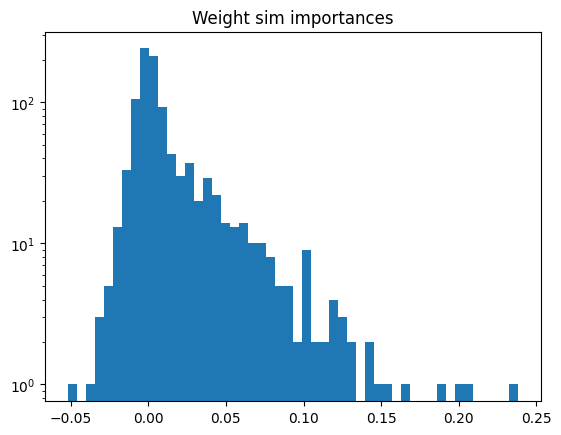

In [11]:
import torch
import einops
from tqdm import tqdm
from matplotlib import pyplot as plt

from typing import Dict, Optional, Union, List

num_components = config.C
# Try removing all dead components for weight-sim score
def weight_sim(
    components,
    model,
    exclude_mask = None,
):
    # Initialize parameter dictionaries
    component_params = {}
    target_params = {}
    

    # Create exclusion mask if needed
    if exclude_mask is not None:
        # Convert single index to list for uniform handling
        if isinstance(exclude_mask, int):
            include_mask = torch.tensor([True for _ in range(num_components)])
            include_mask[exclude_mask] = False
        else:
            include_mask = ~exclude_mask

    # Process each component
    for comp_name, component in components.items():
        # Compute component parameters
        if exclude_mask is not None:
            # Use only included components
            A_filtered = component.A[:, include_mask]
            B_filtered = component.B[include_mask]
            component_params[comp_name] = einops.einsum(
                A_filtered, B_filtered,
                "d_in C, C d_out -> d_out d_in"
            )
        else:
            # Use all components
            
            component_params[comp_name] = einops.einsum(
                component.A, component.B,
                "d_in C, C d_out -> d_out d_in"
            )
        
        # Get target parameters from model
        submodule = model.model.get_submodule(comp_name)
        target_params[comp_name] = submodule.weight
    
    # Calculate faithfulness loss
    faithfulness_loss = torch.tensor(0.0, device=device)
    
    for name in component_params:
        # Compute squared difference between target and component params
        diff = target_params[name] - component_params[name]
        faithfulness_loss += (diff ** 2).sum()
    
    return faithfulness_loss

# def weight_sim(components, model, exclude_idx=None):
#     target_params = {}
#     component_params = {}
#     for comp_name, component in components.items():
#         if exclude_idx is not None:
#             idx_excluding = torch.arange(num_components) != exclude_idx # C
#             if isinstance(exclude_idx, list):
#                 idx_excluding = ~torch.tensor([i in exclude_idx for i in range(num_components)]) # C
#             component_params[comp_name] = einops.einsum(component.A[:, idx_excluding], component.B[idx_excluding], "d_in C, C d_out -> d_out d_in")
#         else:
#             component_params[comp_name] = einops.einsum(component.A, component.B, "d_in C, C d_out -> d_out d_in")

#         submodule = model.model.get_submodule(comp_name)
#         # assert isinstance(submodule, nn.Linear | nn.Embedding)
#         target_params[comp_name] = submodule.weight
#         # assert component_params[comp_name].shape == target_params[comp_name].shape
#     params1 = component_params
#     params2 = target_params
#     faithfulness_loss = torch.tensor(0.0, device=device)
#     for name in params1:
#         diff = params2[name] - params1[name] # [d_in, d_out]
#         faithfulness_loss += (diff ** 2).sum()
#     return faithfulness_loss

weight_sim_importances = torch.zeros(num_components)
original_loss = weight_sim(components, model)
for i in tqdm(range(num_components)):
    weight_sim_importances[i] = weight_sim(components, model, i) - original_loss

# plot as a hist
plt.hist(weight_sim_importances.cpu().numpy(), bins=50)
plt.yscale('log')
plt.title("Weight sim importances")

100%|██████████| 7990/7990 [01:43<00:00, 77.55it/s]


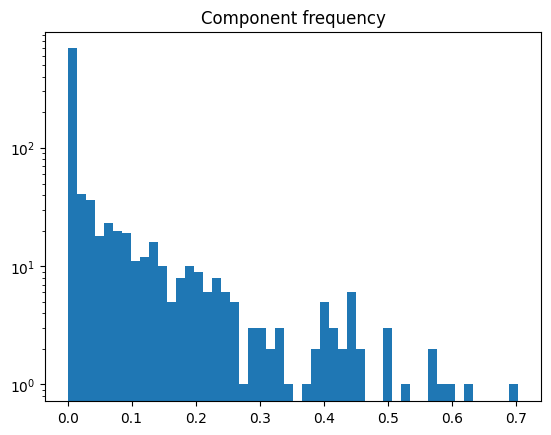

In [12]:
# Now we want component frequency
module_name = config.target_module_patterns[0]
dataset = iter(eval_loader)
component_freq = torch.zeros(num_components)
total_data_points = 0
for batch in tqdm(dataset):
    batch = batch["input_ids"].to(device)
    orig_logits, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
        batch,
        module_names = module_comp
    )
    # target_component_acts = calc_component_acts(pre_weight_acts=pre_weight_acts, As=As)  # type: ignore
    causal_importances, causal_importances_upper_leaky = calc_causal_importances(
        pre_weight_acts=pre_weight_acts, As=As, gates=gates, detach_inputs=False
    )
    activated = (causal_importances[module_name] > 0).sum(dim=(0,1)).cpu()
    component_freq += activated
    total_data_points += batch.numel()
    # if fail, print activated.max() & batch.shape
    # if total_data_points < component_freq.max():
    #     print(f"activated.max(): {activated.max()}, batch.shape: {batch.shape}")
    # assert total_data_points > component_freq.max() 

freq = component_freq / total_data_points
plt.hist(freq.cpu().numpy(), bins=50)
plt.yscale('log')
plt.title("Component frequency")
plt.show()


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

def create_similarity_graph(similarity_matrix, threshold=0.6, matrix_type="AA", 
                          alive_dead_type="alive", node_labels=None, 
                          alive_norms=None, dead_norms=None,
                          figsize=(12, 10), seed=42):
    """
    Create a force-directed graph from a cosine similarity matrix.
    
    Parameters:
    -----------
    similarity_matrix : torch.Tensor or numpy.ndarray
        Cosine similarity matrix (can be rectangular for alive-dead comparisons)
    threshold : float
        Only show edges with |similarity| > threshold
    matrix_type : str
        "AA" or "BB" to indicate which type of components
    alive_dead_type : str
        "alive", "dead", "alive-dead", or "dead-alive"
    node_labels : list, optional
        Custom labels for nodes
    alive_norms : array-like, optional
        Norms for alive components
    dead_norms : array-like, optional
        Norms for dead components
    figsize : tuple
        Figure size
    seed : int
        Random seed for reproducible layout
    """
    
    # Convert to numpy if torch tensor
    if hasattr(similarity_matrix, 'cpu'):
        sim_matrix = similarity_matrix.cpu().numpy()
    else:
        sim_matrix = similarity_matrix
    
    # Convert norms to numpy if needed
    if alive_norms is not None and hasattr(alive_norms, 'cpu'):
        alive_norms = alive_norms.cpu().numpy()
    if dead_norms is not None and hasattr(dead_norms, 'cpu'):
        dead_norms = dead_norms.cpu().numpy()
    
    # Create graph
    G = nx.Graph()
    
    # First, find all edges that meet the threshold
    edges_to_add = []
    nodes_to_keep = set()
    
    if alive_dead_type in ["alive", "dead"]:
        # Square matrix case - only check lower triangle
        n_nodes = sim_matrix.shape[0]
        for i in range(n_nodes):
            for j in range(i):
                weight = sim_matrix[i, j]
                if abs(weight) > threshold:
                    edges_to_add.append((i, j, weight))
                    nodes_to_keep.add(i)
                    nodes_to_keep.add(j)
                    
    else:  # alive-dead or dead-alive
        # Rectangular matrix case
        n_rows, n_cols = sim_matrix.shape
        for i in range(n_rows):
            for j in range(n_cols):
                weight = sim_matrix[i, j]
                if abs(weight) > threshold:
                    edges_to_add.append((f"row_{i}", f"col_{j}", weight))
                    nodes_to_keep.add(f"row_{i}")
                    nodes_to_keep.add(f"col_{j}")
    
    # If no edges meet threshold, return empty graph
    if not edges_to_add:
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, f"No connections found with threshold > {threshold}", 
                transform=ax.transAxes, ha='center', va='center', fontsize=16)
        ax.axis('off')
        return fig, G
    
    # Now add only the nodes that have edges
    if alive_dead_type in ["alive", "dead"]:
        # Square matrix case
        for i in nodes_to_keep:
            label = node_labels[i] if node_labels else f"{matrix_type}_{i}"
            G.add_node(i, label=label, type=alive_dead_type, component=matrix_type)
    else:
        # Rectangular matrix case
        if alive_dead_type == "alive-dead":
            row_type, col_type = "alive", "dead"
        else:
            row_type, col_type = "dead", "alive"
            
        for node in nodes_to_keep:
            if node.startswith("row_"):
                idx = int(node.split("_")[1])
                label = f"{matrix_type}_{row_type}_{idx}"
                G.add_node(node, label=label, type=row_type, component=matrix_type, index=idx)
            else:  # col_
                idx = int(node.split("_")[1])
                label = f"{matrix_type}_{col_type}_{idx}"
                G.add_node(node, label=label, type=col_type, component=matrix_type, index=idx)
    
    # Add edges
    for u, v, weight in edges_to_add:
        G.add_edge(u, v, weight=weight)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Calculate layout
    pos = nx.spring_layout(G, k=2/np.sqrt(len(G.nodes())), iterations=50, seed=seed)
    
    # Create node colors and sizes based on actual nodes in graph
    node_colors = []
    node_sizes = []
    
    for node in G.nodes():
        node_type = G.nodes[node]['type']
        component = G.nodes[node]['component']
        
        # Set colors
        if component == "AA":
            if node_type == "alive":
                node_colors.append('#2E7D32')  # Green for AA alive
            else:
                node_colors.append('#B71C1C')  # Dark red for AA dead
        else:  # BB
            if node_type == "alive":
                node_colors.append('#1976D2')  # Blue for BB alive
            else:
                node_colors.append('#F57C00')  # Orange for BB dead
        
        # Set sizes based on norms
        if alive_dead_type in ["alive", "dead"]:
            # Square matrix - use alive or dead norms based on type
            if node_type == "alive" and alive_norms is not None:
                node_sizes.append(alive_norms[node])
            elif node_type == "dead" and dead_norms is not None:
                node_sizes.append(dead_norms[node])
            else:
                node_sizes.append(1.0)  # default if no norms provided
        else:
            # Rectangular matrix - use index stored in node
            idx = G.nodes[node]['index']
            if node_type == "alive" and alive_norms is not None:
                node_sizes.append(alive_norms[idx])
            elif node_type == "dead" and dead_norms is not None:
                node_sizes.append(dead_norms[idx])
            else:
                node_sizes.append(1.0)  # default if no norms provided
    
    # Scale node sizes (adjust multiplier as needed)
    if any(norms is not None for norms in [alive_norms, dead_norms]):
        node_sizes = [max(50, size * 100) for size in node_sizes]  # min size 50, scale by 100
    else:
        node_sizes = 300  # default size when no norms provided
    
    # Separate positive and negative edges
    pos_edges = [(u, v) for u, v, w in G.edges(data='weight') if w > 0]
    neg_edges = [(u, v) for u, v, w in G.edges(data='weight') if w < 0]
    
    # Draw positive edges in blue
    if pos_edges:
        pos_weights = [G[u][v]['weight'] for u, v in pos_edges]
        nx.draw_networkx_edges(G, pos, pos_edges, 
                              width=[w*4 for w in pos_weights],
                              alpha=[min((w - threshold) / (1 - threshold), 1) for w in pos_weights],
                              edge_color='blue', ax=ax)
    
    # Draw negative edges in red
    if neg_edges:
        neg_weights = [abs(G[u][v]['weight']) for u, v in neg_edges]
        nx.draw_networkx_edges(G, pos, neg_edges,
                              width=[w*4 for w in neg_weights],
                              alpha=[min((w - threshold) / (1 - threshold), 1) for w in neg_weights],
                              edge_color='red', ax=ax)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=node_sizes, alpha=0.8, ax=ax)
    
    # Draw labels
    labels = {node: G.nodes[node]['label'] for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=8, ax=ax)
    
    # Add title and legend
    title = f"{matrix_type} Cosine Similarity Network ({alive_dead_type})"
    ax.set_title(title, fontsize=16, fontweight='bold')
    
    # Create legend
    legend_elements = []
    
    # Only add legend items for node types that actually exist in the graph
    node_types_in_graph = set((G.nodes[node]['component'], G.nodes[node]['type']) for node in G.nodes())
    
    if ('AA', 'alive') in node_types_in_graph:
        legend_elements.append(mpatches.Patch(color='#2E7D32', label='AA Alive'))
    if ('AA', 'dead') in node_types_in_graph:
        legend_elements.append(mpatches.Patch(color='#B71C1C', label='AA Dead'))
    if ('BB', 'alive') in node_types_in_graph:
        legend_elements.append(mpatches.Patch(color='#1976D2', label='BB Alive'))
    if ('BB', 'dead') in node_types_in_graph:
        legend_elements.append(mpatches.Patch(color='#F57C00', label='BB Dead'))
    
    if pos_edges:
        legend_elements.append(mpatches.Patch(color='blue', label='Positive Similarity'))
    if neg_edges:
        legend_elements.append(mpatches.Patch(color='red', label='Negative Similarity'))
    
    if any(norms is not None for norms in [alive_norms, dead_norms]):
        legend_elements.append(mpatches.Patch(color='gray', label='Node size = vector norm'))
    
    ax.legend(handles=legend_elements, loc='upper right')
    
    # Add statistics
    stats_text = f"Nodes: {len(G.nodes())}\nEdges: {len(G.edges())}\nThreshold: {threshold}"
    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5),
            verticalalignment='bottom')
    
    ax.axis('off')
    plt.tight_layout()
    
    return fig, G


def plot_all_similarity_graphs(aa_cos_sim_alive, bb_cos_sim_alive, 
                              aa_cos_sim_alive_dead=None, bb_cos_sim_alive_dead=None,
                              aa_cos_sim_dead=None, bb_cos_sim_dead=None,
                              A_alive_norms=None, A_dead_norms=None,
                              B_alive_norms=None, B_dead_norms=None,
                              threshold=0.6, save_path=None):
    """
    Plot all cosine similarity graphs for different component combinations.
    
    Parameters:
    -----------
    aa_cos_sim_alive : torch.Tensor
        AA cosine similarities for alive components (lower triangular)
    bb_cos_sim_alive : torch.Tensor
        BB cosine similarities for alive components (lower triangular)
    aa_cos_sim_alive_dead : torch.Tensor, optional
        AA cosine similarities between alive and dead components
    bb_cos_sim_alive_dead : torch.Tensor, optional
        BB cosine similarities between alive and dead components
    aa_cos_sim_dead : torch.Tensor, optional
        AA cosine similarities for dead components (lower triangular)
    bb_cos_sim_dead : torch.Tensor, optional
        BB cosine similarities for dead components (lower triangular)
    A_alive_norms : array-like, optional
        Norms for alive A components
    A_dead_norms : array-like, optional
        Norms for dead A components
    B_alive_norms : array-like, optional
        Norms for alive B components
    B_dead_norms : array-like, optional
        Norms for dead B components
    threshold : float
        Similarity threshold for displaying edges
    save_path : str, optional
        Path to save the figures
    """
    
    figures = []
    
    # Plot AA alive
    fig1, G1 = create_similarity_graph(aa_cos_sim_alive, threshold=threshold, 
                                      matrix_type="AA", alive_dead_type="alive",
                                      alive_norms=A_alive_norms)
    figures.append(('AA_alive', fig1))
    
    # Plot BB alive
    fig2, G2 = create_similarity_graph(bb_cos_sim_alive, threshold=threshold,
                                      matrix_type="BB", alive_dead_type="alive",
                                      alive_norms=B_alive_norms)
    figures.append(('BB_alive', fig2))
    
    # Plot alive-dead connections if provided
    if aa_cos_sim_alive_dead is not None:
        fig3, G3 = create_similarity_graph(aa_cos_sim_alive_dead, threshold=threshold,
                                          matrix_type="AA", alive_dead_type="alive-dead",
                                          alive_norms=A_alive_norms, dead_norms=A_dead_norms)
        figures.append(('AA_alive_dead', fig3))
    
    if bb_cos_sim_alive_dead is not None:
        fig4, G4 = create_similarity_graph(bb_cos_sim_alive_dead, threshold=threshold,
                                          matrix_type="BB", alive_dead_type="alive-dead",
                                          alive_norms=B_alive_norms, dead_norms=B_dead_norms)
        figures.append(('BB_alive_dead', fig4))
    
    # Plot dead-dead connections if provided
    if aa_cos_sim_dead is not None:
        fig5, G5 = create_similarity_graph(aa_cos_sim_dead, threshold=threshold,
                                          matrix_type="AA", alive_dead_type="dead",
                                          dead_norms=A_dead_norms)
        figures.append(('AA_dead', fig5))
    
    if bb_cos_sim_dead is not None:
        fig6, G6 = create_similarity_graph(bb_cos_sim_dead, threshold=threshold,
                                          matrix_type="BB", alive_dead_type="dead",
                                          dead_norms=B_dead_norms)
        figures.append(('BB_dead', fig6))
    
    # Save figures if path provided
    if save_path:
        for name, fig in figures:
            fig.savefig(f"{save_path}_{name}.png", dpi=300, bbox_inches='tight')
    
    return figures



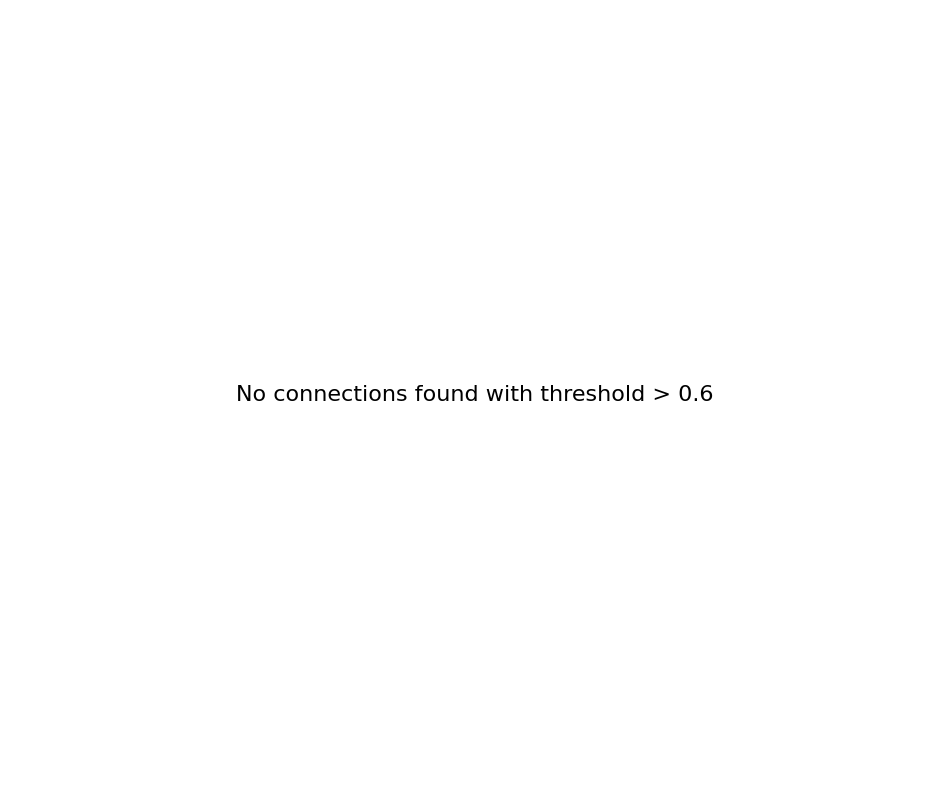

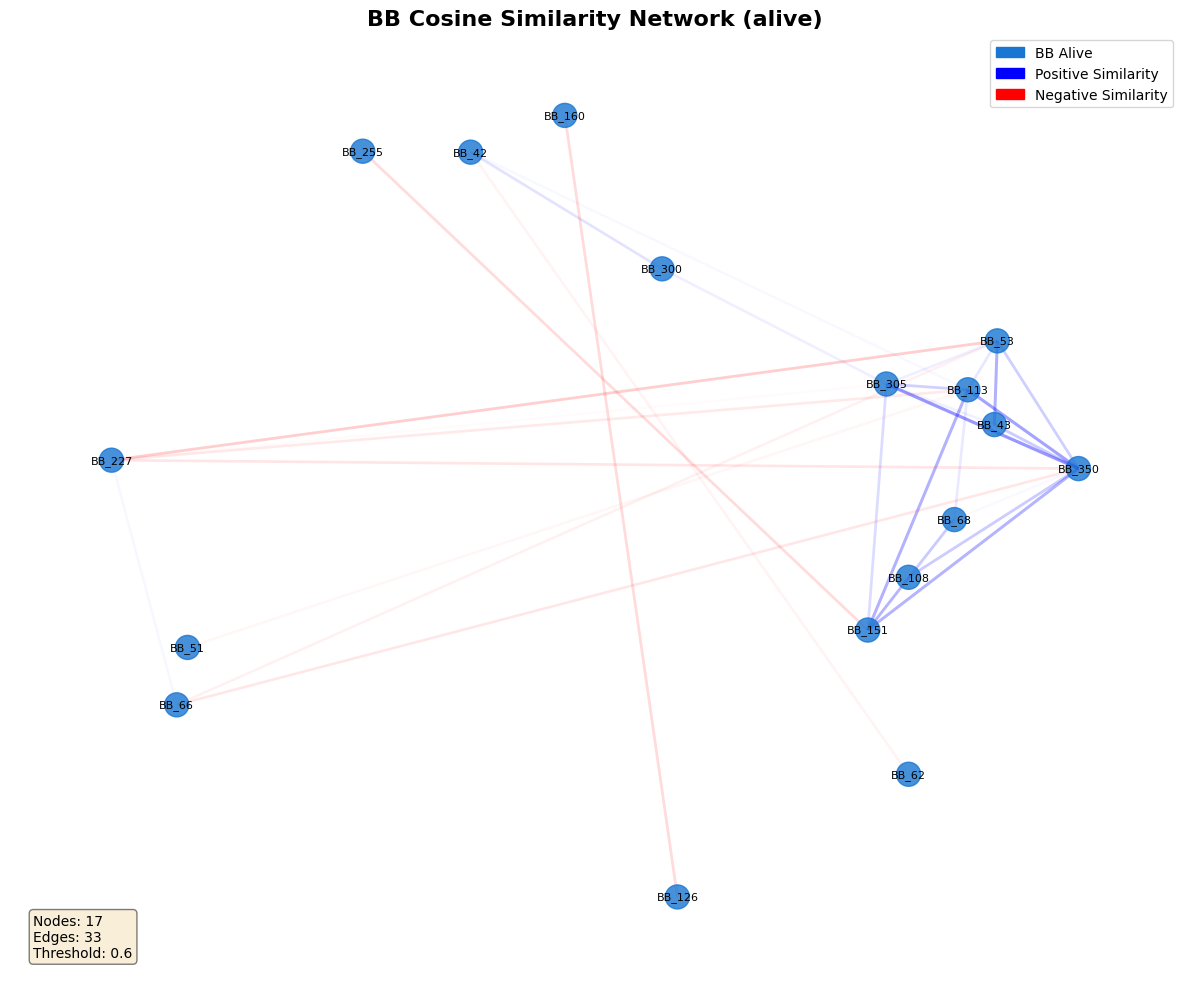

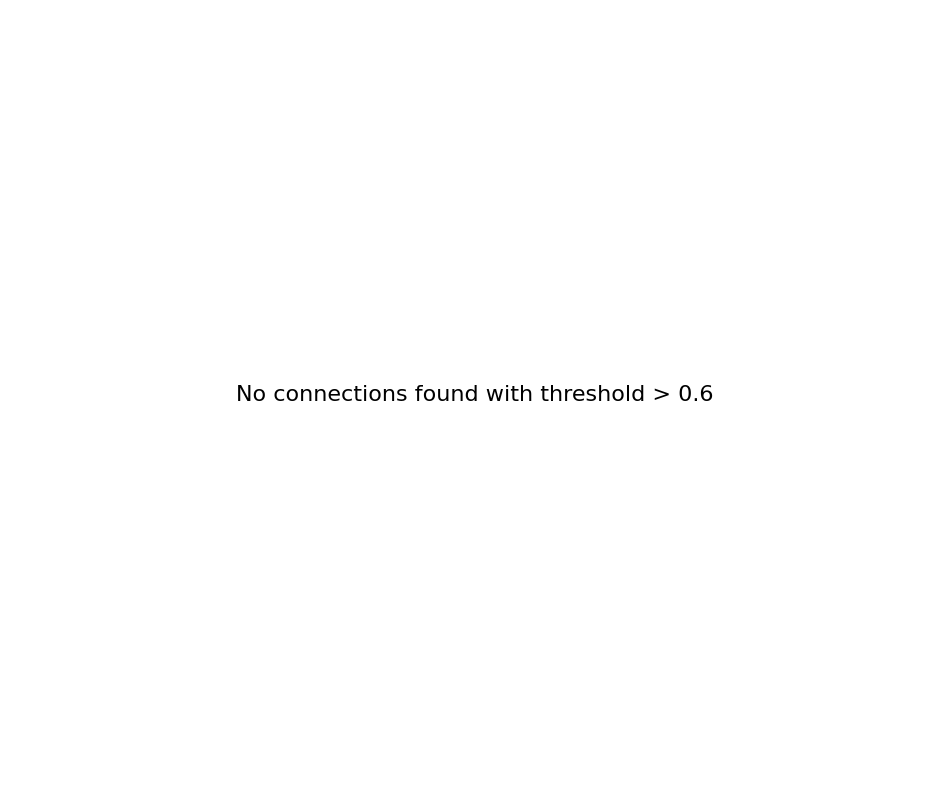

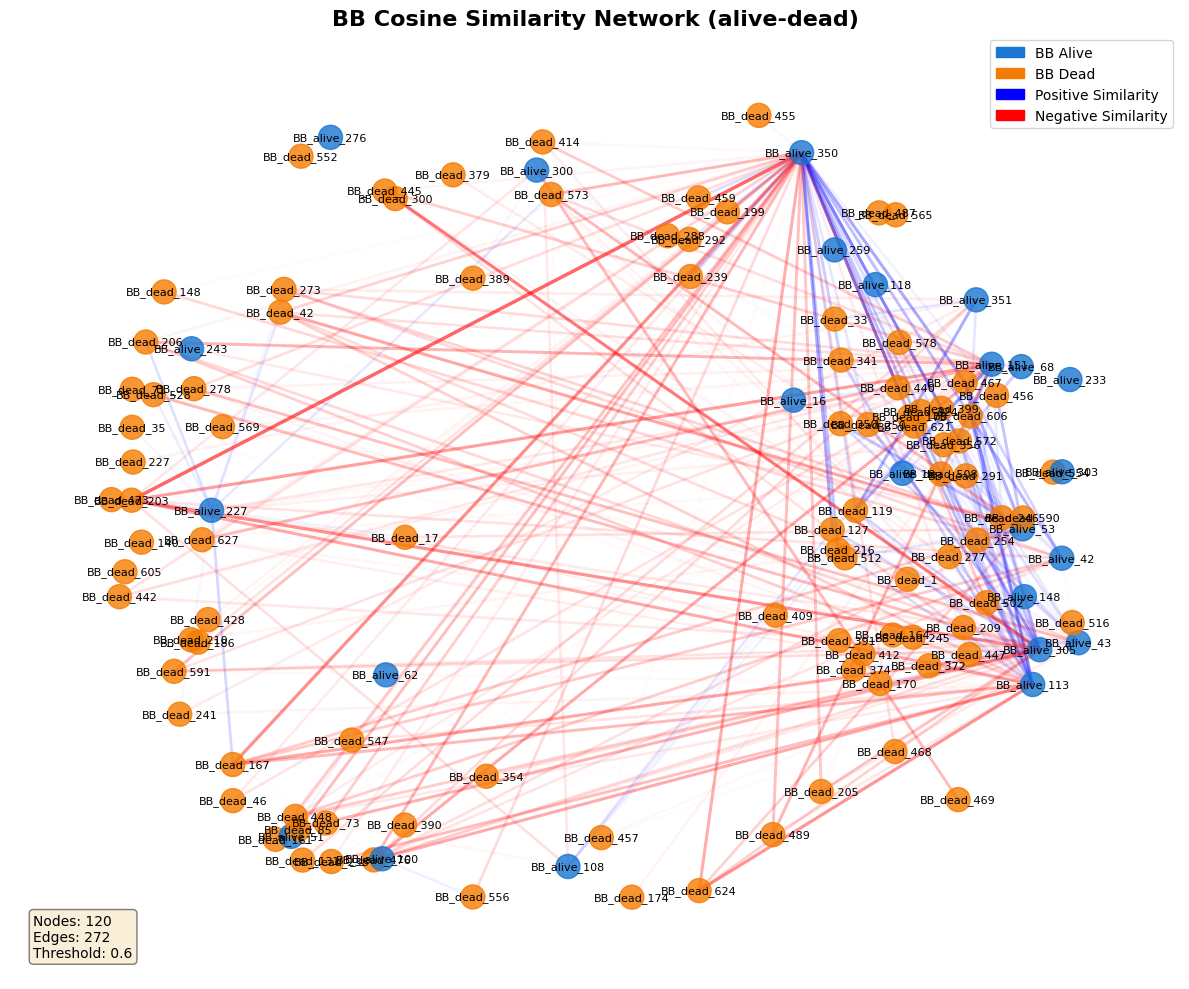

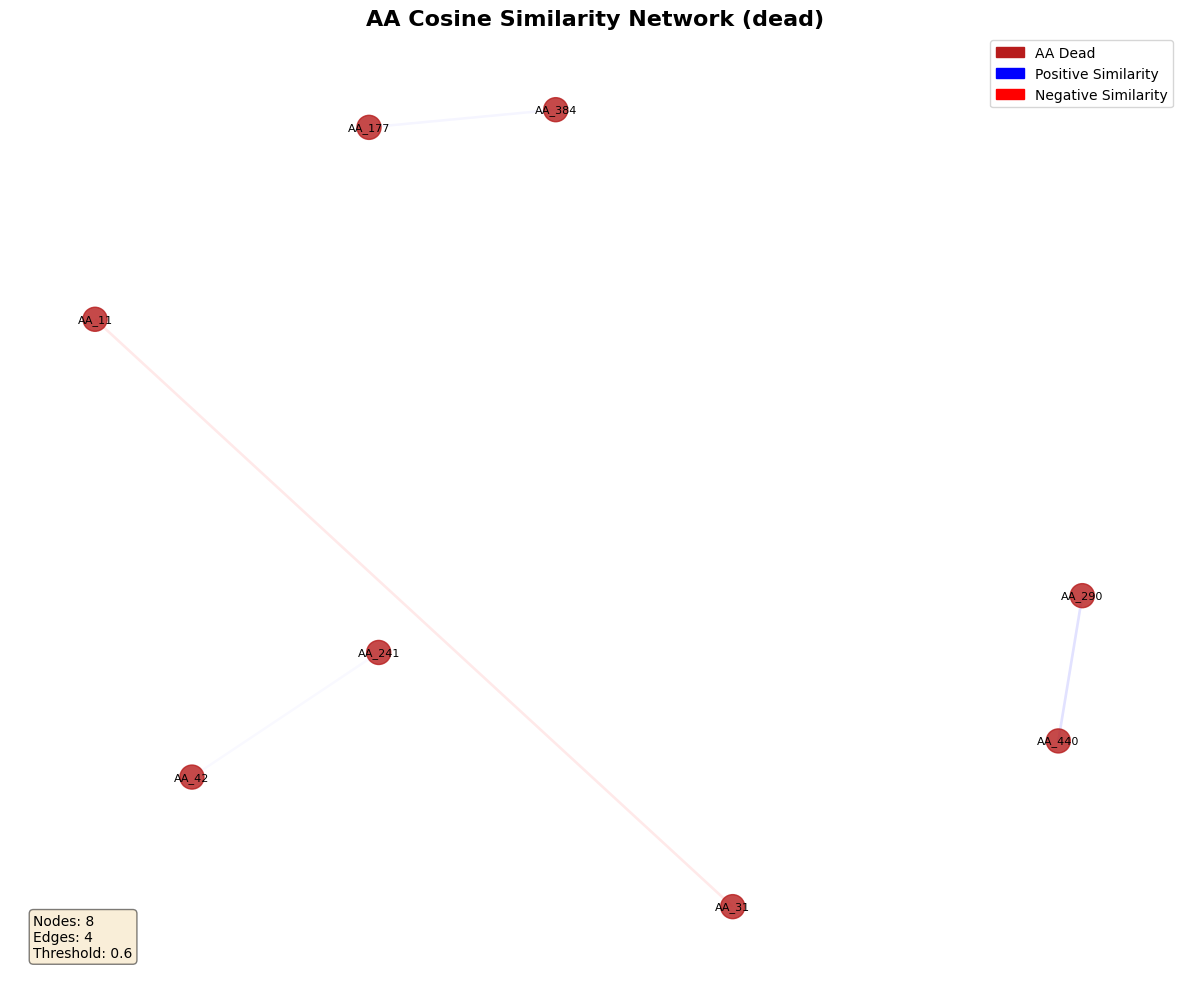

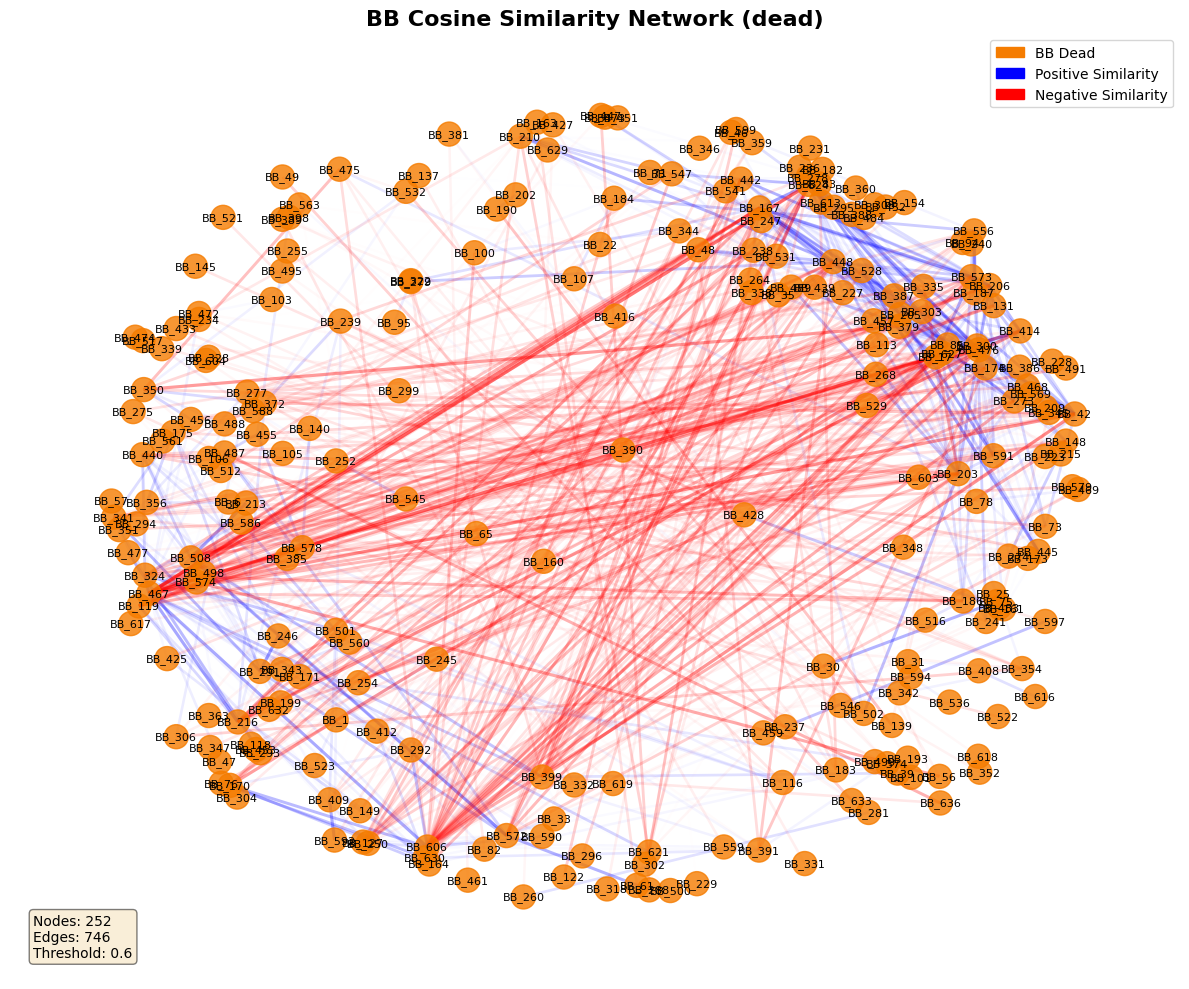

In [ ]:

alive_mask = (freq > 0)
dead_mask = (freq == 0)

layer_name = module_name

# Split components into alive and dead
A_alive = components[layer_name].A[:, alive_mask]
B_alive = components[layer_name].B[alive_mask, :]
A_dead = components[layer_name].A[:, dead_mask]
B_dead = components[layer_name].B[dead_mask, :]

alive_frequencies = freq[alive_mask].cpu().numpy()

# Normalize alive components
normed_A_alive = torch.nn.functional.normalize(A_alive, dim=0)  # [d_model, n_components_alive]
normed_B_alive = torch.nn.functional.normalize(B_alive, dim=1)  # [n_components_alive, d_out]

# Normalize dead components (if any exist)
normed_A_dead = torch.nn.functional.normalize(A_dead, dim=0)  # [d_model, n_components_dead]
normed_B_dead = torch.nn.functional.normalize(B_dead, dim=1)  # [n_components_dead, d_out]

# Compute cosine similarities for alive components
aa_cos_sim_alive = (normed_A_alive.T @ normed_A_alive).tril(diagonal=-1)
bb_cos_sim_alive = (normed_B_alive @ normed_B_alive.T).tril(diagonal=-1)

# Compute cosine similarities between alive and dead A components
aa_cos_sim_alive_dead = normed_A_alive.T @ normed_A_dead  # [n_alive, n_dead]
# Compute cosine similarities between alive and dead B components
bb_cos_sim_alive_dead = normed_B_alive @ normed_B_dead.T  # [n_alive, n_dead]

# Compute cosine similarities for dead components among themselves
aa_cos_sim_dead = (normed_A_dead.T @ normed_A_dead).tril(diagonal=-1)
bb_cos_sim_dead = (normed_B_dead @ normed_B_dead.T).tril(diagonal=-1)

# Example usage with norms:
A_alive_norms = A_alive.norm(dim=0).cpu().numpy()
B_alive_norms = B_alive.norm(dim=1).cpu().numpy()
A_dead_norms = A_dead.norm(dim=0).cpu().numpy()
B_dead_norms = B_dead.norm(dim=1).cpu().numpy()

# Plot with norms
figures = plot_all_similarity_graphs(
    aa_cos_sim_alive=aa_cos_sim_alive,
    bb_cos_sim_alive=bb_cos_sim_alive,
    aa_cos_sim_alive_dead=aa_cos_sim_alive_dead,
    bb_cos_sim_alive_dead=bb_cos_sim_alive_dead,
    aa_cos_sim_dead=aa_cos_sim_dead,
    bb_cos_sim_dead=bb_cos_sim_dead,
    A_alive_norms=A_alive_norms,
    A_dead_norms=A_dead_norms,
    B_alive_norms=B_alive_norms,
    B_dead_norms=B_dead_norms,
    threshold=0.6,
    save_path="similarity_graphs_with_norms"
)
# # Or plot individual graphs with custom settings
# fig, G = create_similarity_graph(bb_cos_sim_alive_dead, threshold=0.6,
#                                           matrix_type="BB", alive_dead_type="alive-dead")

# plt.show()

In [27]:
aa_cos_sim_alive_dead.max(), aa_cos_sim_alive_dead.min()
bb_cos_sim_alive_dead.max(), bb_cos_sim_alive_dead.min()

(tensor(0.7564, device='cuda:0'), tensor(-0.8365, device='cuda:0'))

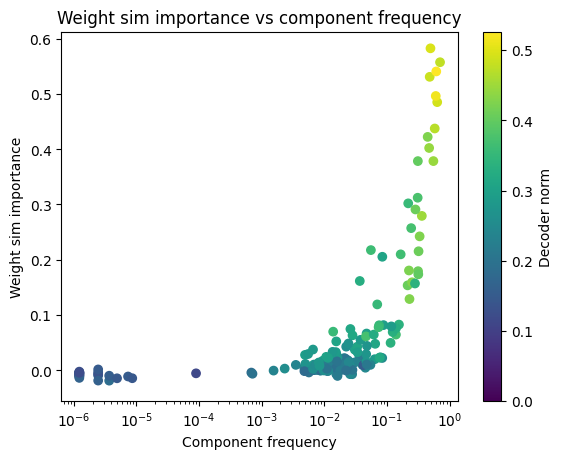

In [424]:
# Also color by decoder norm
plt.scatter(freq.cpu().numpy(), weight_sim_importances.cpu().numpy(), c=dec_norms.cpu().numpy())
# plt.xscale('log')
# plt.yscale('log')
plt.title("Weight sim importance vs component frequency")
plt.ylabel("Weight sim importance")
plt.xlabel("Component frequency")
plt.xscale("log")
# set colorbar min to 0
cbar = plt.colorbar()
# cbar.set_clim(vmin=0)
# AttributeError: 'Colorbar' object has no attribute 'set_clim'
# cbar.set_clim(vmin=0)
cbar.mappable.set_clim(vmin=0)
# label colorbar as decoder norm
cbar.set_label("Decoder norm")
plt.show()

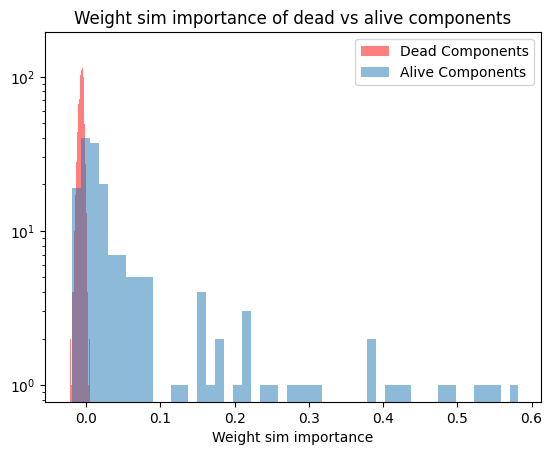

In [233]:
freq.topk(600, largest=False)
dead_component_mask = freq ==0
weight_sim_imp_dead = weight_sim_importances[dead_component_mask]
weight_sim_imp_alive = weight_sim_importances[~dead_component_mask]

plt.hist(weight_sim_imp_dead.cpu().numpy(), bins=50, alpha=0.5, label="Dead Components", color="red")
plt.hist(weight_sim_imp_alive.cpu().numpy(), bins=50, alpha=0.5, label="Alive Components")
plt.title("Weight sim importance of dead vs alive components")
plt.legend()
# plt.xscale('log')
plt.xlabel("Weight sim importance")

plt.yscale('log')
plt.show()
# plt.xscale('log')
# plt.yscale('log')
# plt.title("Weight sim importance of alive components")
# plt.show()

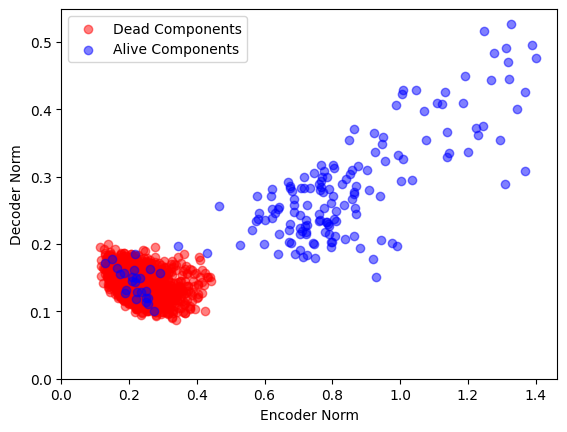

/tmp/ipykernel_1217281/2758369991.py:51: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0)


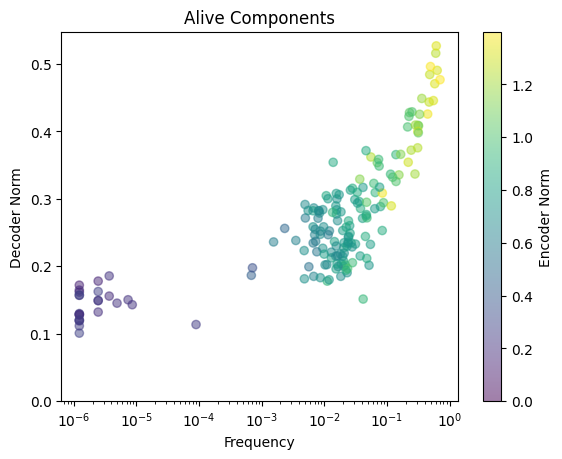

Correlations between dec_norm, encoder_norm, and freq
Correlation between dec_norm and encoder_norm: 0.799
Correlation between dec_norm and freq: 0.743
Correlation between encoder_norm and freq: 0.682


Correlations but restricted to alive components
Correlation between alive dec_norm and alive encoder_norm: 0.836
Correlation between alive dec_norm and alive freq: 0.809


Correlations but restricted to dead components (ignoring freq since that's 0)
Correlation between dead dec_norm and dead encoder_norm: -0.378


In [280]:
dead_encoder_norms = enc_norms[dead_component_mask]
alive_encoder_norms = enc_norms[~dead_component_mask]

dead_dec_norms = dec_norms[dead_component_mask]
alive_dec_norms = dec_norms[~dead_component_mask]

same_norms = False

plt.scatter(dead_encoder_norms.cpu().numpy(), dead_dec_norms.cpu().numpy(), alpha=0.5, label="Dead Components", color="red")
plt.scatter(alive_encoder_norms.cpu().numpy(), alive_dec_norms.cpu().numpy(), alpha=0.5, label="Alive Components", color="blue")
plt.xlabel("Encoder Norm")
plt.ylabel("Decoder Norm")
max_enc_norm = max(enc_norms.cpu().numpy())
max_dec_norm = max(dec_norms.cpu().numpy())
max_of_norms = max(max_enc_norm, max_dec_norm)
if same_norms:
    plt.xlim(0, max_of_norms)
    plt.ylim(0, max_of_norms)
else:
    # set y and x min to 0
    plt.xlim(0)
    plt.ylim(0)
plt.legend()
plt.show()

# alive_freq
alive_freq = freq[~dead_component_mask]
dead_freq = freq[dead_component_mask]

plt.scatter(alive_freq.cpu().numpy(), alive_dec_norms.cpu().numpy(), alpha=0.5, c=alive_encoder_norms.cpu().numpy(), cmap="viridis")
plt.xlabel("Frequency")
plt.ylabel("Decoder Norm")

# plt.scatter(alive_encoder_norms.cpu().numpy(), alive_dec_norms.cpu().numpy(), alpha=0.5, c=alive_freq.cpu().numpy(), cmap="viridis")
# plt.colorbar(label="Frequency")
# plt.xlabel("Encoder Norm")
# plt.ylabel("Decoder Norm")
# log colorbar
# plt.xlim(0)
# Set colorbar min to 0
cbar = plt.colorbar()
cbar.set_label("Encoder Norm")
if same_norms:
    cbar.mappable.set_clim(vmin=0, vmax=max_of_norms)
    plt.ylim(0, max_of_norms)
else:
    cbar.mappable.set_clim(vmin=0)
    plt.ylim(0)
plt.title("Alive Components")
plt.xscale("log")
plt.xlim(0)
plt.show()

print("Correlations between dec_norm, encoder_norm, and freq")
# Correlation between dec_norm, encoder_norm, and freq
correlation_dec_norm_encoder_norm = np.corrcoef(dec_norms.cpu().numpy(), enc_norms.cpu().numpy())[0, 1]
print(f"Correlation between dec_norm and encoder_norm: {correlation_dec_norm_encoder_norm:.3f}")
correlation_dec_norm_freq = np.corrcoef(dec_norms.cpu().numpy(), freq.cpu().numpy())[0, 1]
print(f"Correlation between dec_norm and freq: {correlation_dec_norm_freq:.3f}")
correlation_encoder_norm_freq = np.corrcoef(enc_norms.cpu().numpy(), freq.cpu().numpy())[0, 1]
print(f"Correlation between encoder_norm and freq: {correlation_encoder_norm_freq:.3f}")

print("\n\nCorrelations but restricted to alive components")
# Repeat for only alive components
alive_dec_norms = dec_norms[~dead_component_mask]
alive_enc_norms = enc_norms[~dead_component_mask]
alive_freq = freq[~dead_component_mask]

correlation_alive_dec_norm_alive_encoder_norm = np.corrcoef(alive_dec_norms.cpu().numpy(), alive_enc_norms.cpu().numpy())[0, 1]
print(f"Correlation between alive dec_norm and alive encoder_norm: {correlation_alive_dec_norm_alive_encoder_norm:.3f}")
correlation_alive_dec_norm_alive_freq = np.corrcoef(alive_dec_norms.cpu().numpy(), alive_freq.cpu().numpy())[0, 1]
print(f"Correlation between alive dec_norm and alive freq: {correlation_alive_dec_norm_alive_freq:.3f}")
correlation_alive_encoder_norm_alive_freq = np.corrcoef(alive_enc_norms.cpu().numpy(), alive_freq.cpu().numpy())[0, 1]

print("\n\nCorrelations but restricted to dead components (ignoring freq since that's 0)")
# Repeat for only dead components but no freq since that's 0
dead_dec_norms = dec_norms[dead_component_mask]
dead_enc_norms = enc_norms[dead_component_mask]
dead_freq = freq[dead_component_mask]

correlation_dead_dec_norm_dead_encoder_norm = np.corrcoef(dead_dec_norms.cpu().numpy(), dead_enc_norms.cpu().numpy())[0, 1]
print(f"Correlation between dead dec_norm and dead encoder_norm: {correlation_dead_dec_norm_dead_encoder_norm:.3f}")

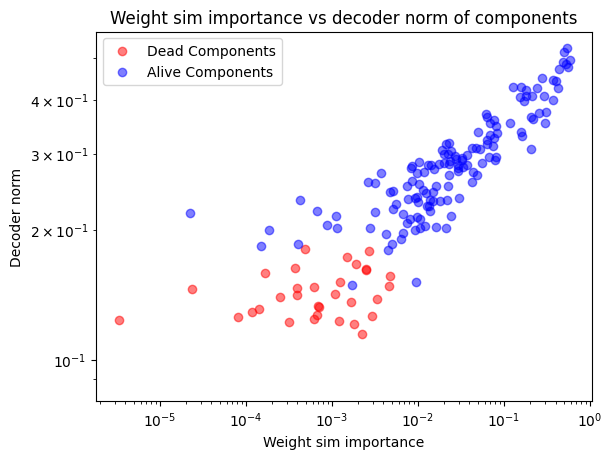

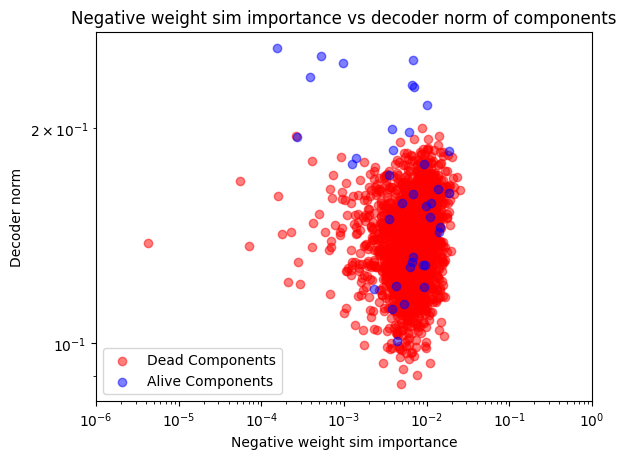

In [248]:
# Plot weight-sim importance vs encoder norm of dead components

dead_component_mask = freq ==0
weight_sim_imp_dead = weight_sim_importances[dead_component_mask]
weight_sim_imp_alive = weight_sim_importances[~dead_component_mask]

dec_norms_dead = dec_norms[dead_component_mask]
dec_norms_alive = dec_norms[~dead_component_mask]

plt.scatter(weight_sim_imp_dead.cpu().numpy(), dec_norms_dead.cpu().numpy(), alpha=0.5, label="Dead Components", color="red")
plt.scatter(weight_sim_imp_alive.cpu().numpy(), dec_norms_alive.cpu().numpy(), alpha=0.5, label="Alive Components", color="blue")
plt.xscale('log')
plt.yscale('log')
plt.title("Weight sim importance vs decoder norm of components")
plt.xlabel("Weight sim importance")
plt.ylabel("Decoder norm")
plt.legend()
plt.show()

# Also log-plot the abs neg weight-sim importance vs decoder norm of dead components
dead_neg_mask = weight_sim_imp_dead < 0
alive_neg_mask = weight_sim_imp_alive < 0
negative_weight_sim_imp_dead = weight_sim_imp_dead[dead_neg_mask]
negative_weight_sim_imp_alive = weight_sim_imp_alive[alive_neg_mask]
neg_dec_norms_dead = dec_norms_dead[dead_neg_mask]
neg_dec_norms_alive = dec_norms_alive[alive_neg_mask]

plt.scatter(negative_weight_sim_imp_dead.abs().cpu().numpy(), neg_dec_norms_dead.cpu().numpy(), alpha=0.5, label="Dead Components", color="red")
plt.scatter(negative_weight_sim_imp_alive.abs().cpu().numpy(), neg_dec_norms_alive.cpu().numpy(), alpha=0.5, label="Alive Components", color="blue")
plt.xscale('log')
# set xlim to 1e-5, 1e-1
plt.xlim(1e-6, 1)
plt.yscale('log')
plt.title("Negative weight sim importance vs decoder norm of components")
plt.xlabel("Negative weight sim importance")
plt.ylabel("Decoder norm")
plt.legend()
plt.show()

In [239]:
negative_weight_sim_imp_dead

tensor([-0.0056, -0.0067, -0.0051,  ..., -0.0034, -0.0066, -0.0049])

In [489]:
weight_sim_importances = torch.zeros(num_components)
dead_component_mask = freq ==0
original_loss = weight_sim(components, model)
all_dead = torch.tensor([True for _ in range(num_components)])
mse_diff_removing_all_dead_components= weight_sim(components, model, dead_component_mask)
ablate_all_alive = weight_sim(components, model, ~dead_component_mask)
ablate_all = weight_sim(components, model, all_dead)
print(f"Setting                    | Weight Faithfulness MSE")
print(f"Ablate_all_dead_components: {mse_diff_removing_all_dead_components:.3f}")
print(f"ablate_all_alive:           {ablate_all_alive:.3f}")
print(f"ablate_all:                 {ablate_all:.3f}")
print(f"Original loss:              {original_loss:.3f}")

Setting                    | Weight Faithfulness MSE
Ablate_all_dead_components: 8.054
ablate_all_alive:           18.782
ablate_all:                 10.653
Original loss:              5.309


In [491]:
dead_component_mask

tensor([False,  True,  True,  ...,  True,  True,  True])

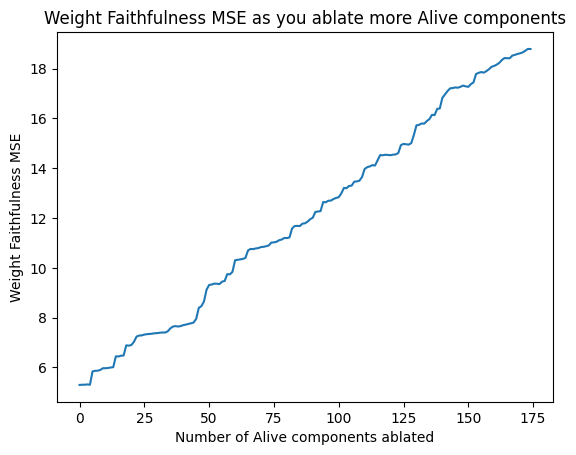

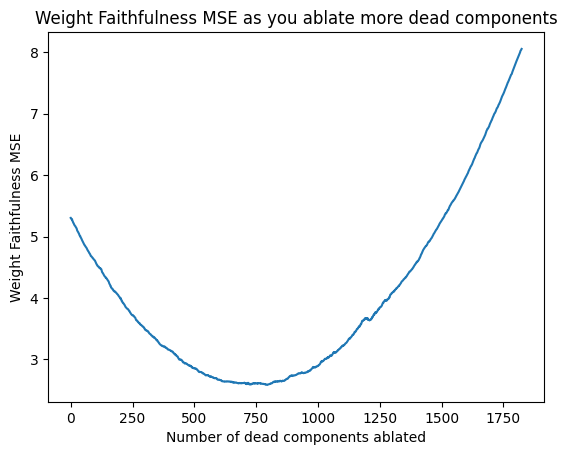

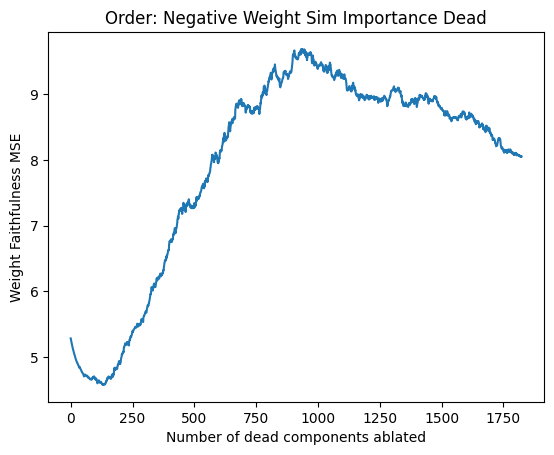

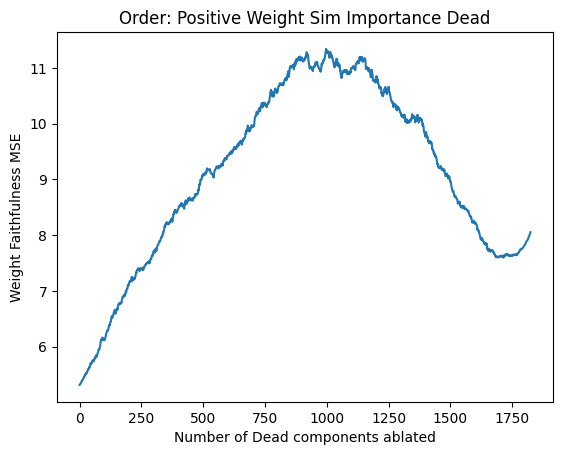

In [536]:
# Iteratively ablate more and more dead components, plotting the results
iterative_ablate_alive_components = []
# exclude_mask = torch.bool(num_components)
# make a tensor of false
exclude_mask = torch.zeros(num_components, dtype=torch.bool)
shuffled_dead_component_indices = torch.randperm(num_dead)
# for i in range(num_dead):

# dead_component_mask = freq ==0
dead_indices = torch.where(freq == 0)[0]
alive_indices = torch.where(freq > 0)[0]
for i in range(2000-num_dead):
    exclude_mask[alive_indices[i].item()] = True
    iterative_ablate_alive_components.append(weight_sim(components, model, exclude_mask).item())

plt.plot(iterative_ablate_alive_components)
plt.xlabel("Number of Alive components ablated")
plt.ylabel("Weight Faithfulness MSE")
plt.title("Weight Faithfulness MSE as you ablate more Alive components")
plt.show()

# Iteratively ablate more and more dead components, plotting the results
iterative_ablate_dead_components = []
# exclude_mask = torch.bool(num_components)
# make a tensor of false
exclude_mask2 = torch.zeros(num_components, dtype=torch.bool)
shuffled_dead_component_indices = torch.randperm(num_dead)
for i in shuffled_dead_component_indices:
    exclude_mask2[dead_indices[i].item()] = True
    iterative_ablate_dead_components.append(weight_sim(components, model, exclude_mask2).item())

plt.plot(iterative_ablate_dead_components)
plt.xlabel("Number of dead components ablated")
plt.ylabel("Weight Faithfulness MSE")
plt.title("Weight Faithfulness MSE as you ablate more dead components")
plt.show()

# Now do it for weight_sim_imp_dead
iterative_sorted_dead = []
sorted_indices = weight_sim_imp_dead.argsort()
reversed_indices = torch.flip(sorted_indices, dims=[0])
iterative_ablate_weight_sim_imp_dead = []
exclude_mask3 = torch.zeros(num_components, dtype=torch.bool)
for i in range(num_dead):
    exclude_mask3[dead_indices[sorted_indices[i].item()]] = True
    iterative_sorted_dead.append(weight_sim(components, model, exclude_mask3).item())

plt.plot(iterative_sorted_dead)
plt.xlabel("Number of dead components ablated")
plt.ylabel("Weight Faithfulness MSE")
plt.title("Order: Negative Weight Sim Importance Dead")
plt.show()

iterative_ablate_negative_weight_sim_imp_alive = []
exclude_mask4 = torch.zeros(num_components, dtype=torch.bool)
for i in range(num_dead):
    exclude_mask4[dead_indices[reversed_indices[i].item()]] = True
    iterative_ablate_negative_weight_sim_imp_alive.append(weight_sim(components, model, exclude_mask4).item())

plt.plot(iterative_ablate_negative_weight_sim_imp_alive)
plt.xlabel("Number of Dead components ablated")
plt.ylabel("Weight Faithfulness MSE")
plt.title("Order: Positive Weight Sim Importance Dead")
plt.show()  

In [541]:
(weight_sim_imp_dead < -0.0001).sum()

tensor(1790)

In [530]:
weight_sim_imp_dead

tensor([-0.0056, -0.0067, -0.0051,  ..., -0.0034, -0.0066, -0.0049])

In [529]:
dead_indices

torch.Size([1825])

In [523]:
iterative_ablate_dead_components[-3: ], iterative_sorted_dead[-3: ], iterative_ablate_negative_weight_sim_imp_alive[-3: ]

([8.045580863952637, 8.049217224121094, 8.054460525512695],
 [9.92909049987793, 9.9317626953125, 9.936113357543945],
 [9.925069808959961, 9.929780960083008, 9.936113357543945])

In [527]:
(exclude_mask4 == exclude_mask2).all()

tensor(False)

In [515]:
sorted_indices.max(), i, num_dead

(tensor(1792), 1793, 1825)

In [509]:
sorted_indices = negative_weight_sim_imp_dead.argsort()
sorted_indices
# reversed_indices = sorted_indices[::-1]
# ValueError: step must be greater than zero, so we should 
# To reverse the indices correctly, we can use torch.flip
reversed_indices = torch.flip(sorted_indices, dims=[0])

reversed_indices

tensor([ 242,  693,  959,  ..., 1186, 1267,  646])

In [ ]:
# # Find the stochastic CE-loss when you turn on dead components
# # Do clamped mask for alive components & zero for dead, except for 1 at a time.

# dead_component_mask = freq == 0
# num_dead_components = dead_component_mask.sum().item()
# dead_component_indices = dead_component_mask.nonzero()[:, 0]
# dead_component_kl = torch.zeros(num_dead_components)
# all_dead_activated_kl = 0.0
# all_dead_activated_kl_list = []
# clamped_kl = 0.0
# clamped_kl_list = []
# eval_iter = iter(eval_loader)
# total_batches = len(eval_iter)
# diff_datapoints_idx = 0

# for batch_idx, batch in tqdm(enumerate(eval_iter), total=total_batches):
#     batch = batch["input_ids"].to(device)
#     orig_logits, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
#         batch,
#         module_names = module_comp
#     )
#     # target_component_acts = calc_component_acts(pre_weight_acts=pre_weight_acts, As=As)  # type: ignore
#     causal_importances, _ = calc_causal_importances(
#         pre_weight_acts=pre_weight_acts, As=As, gates=gates, detach_inputs=False
#     )

#     clamped_mask = {k: v.clamp(0, 1) for k, v in causal_importances.items()}
#     # set all dead components to 0
#     # clamped_mask[module_name][:, :, dead_component_indices] = 0
#     clamped_logits = model.forward_with_components(
#         batch, components=components, masks=clamped_mask
#     )
#     kl_clamped = calc_kl_divergence_lm(clamped_logits, orig_logits).item()
#     clamped_kl_list.append(kl_clamped)
#     clamped_kl += kl_clamped

#     clamped_mask[module_name][:, :, dead_component_indices] = 1
#     all_dead_activated_logits = model.forward_with_components(
#         batch, components=components, masks=clamped_mask
#     )
#     kl_dead_act = calc_kl_divergence_lm(all_dead_activated_logits, orig_logits).item()
#     all_dead_activated_kl_list.append(kl_dead_act)
#     all_dead_activated_kl += kl_dead_act

#     if kl_dead_act > kl_clamped:
#         print(f"kl_dead_act > kl_clamped: {kl_dead_act} > {kl_clamped}")
#         clamped_mask[module_name][:, :, dead_component_indices] = 0.0
#         for local_dead_idx, dead_idx in enumerate(dead_component_indices):
#             clamped_mask[module_name][:, :, dead_idx] = 1
#             per_component_dead_logits = model.forward_with_components(
#                 batch, components=components, masks=clamped_mask
#             )
#             dead_component_kl[local_dead_idx] += calc_kl_divergence_lm(per_component_dead_logits, orig_logits).item()
#             clamped_mask[module_name][:, :, dead_idx] = 0
#         diff_datapoints_idx += 1
#     # print(batch_idx)
#     if diff_datapoints_idx > 10:
#         break
    
# dead_component_kl /= diff_datapoints_idx
# all_dead_activated_kl /= batch_idx + 1
# clamped_kl /= batch_idx + 1

In [43]:
# import torch
# import numpy as np
# from tqdm import tqdm
# from collections import defaultdict
# # dead_component_mask = freq == 0
# # dead_component_indices = dead_component_mask.nonzero()[:, 0]

# def estimate_dead_component_importance(
#     model,
#     eval_loader,
#     components,
#     As,
#     gates,
#     module_name,
#     module_comp,
#     dead_component_indices,
#     n_samples_per_batch=100,
#     max_batches=10,
#     kl_threshold=0.01,
#     marginal_threshold=0.01,  # 1% relative change threshold
#     device='cuda'
# ):
#     """
#     Estimate importance of dead components using weighted co-occurrence scoring.
    
#     Components get weighted points based on their participation in subsets that increase KL divergence.
#     Normalizes positive and negative scores separately, then averages across batches.
    
#     Args:
#         model: The model to evaluate
#         eval_loader: DataLoader for evaluation
#         components: Component dictionary
#         As: Component matrices
#         gates: Gate values
#         module_name: Name of the module being analyzed
#         module_comp: Module component for forward hooks
#         dead_component_indices: Indices of dead components
#         n_samples_per_batch: Number of subset samples per batch
#         max_batches: Maximum number of batches to process
#         kl_threshold: Minimum KL increase to count subset as harmful
#         marginal_threshold: Relative change threshold for minimal/maximal analysis
#         device: Device to run on
    
#     Returns:
#         importance_scores: Score for each dead component (higher = more harmful)
#         stats: Dictionary with analysis statistics
#     """
    
#     num_dead = len(dead_component_indices)
    
#     # Track per-batch statistics
#     batch_positive_scores = []
#     batch_negative_scores = []
#     batch_positive_counts = []
#     batch_negative_counts = []
    
#     # Global statistics
#     harmful_subsets = []
#     subset_cache = {}  # Cache all evaluated subsets
#     subset_size_distribution = defaultdict(int)
#     total_samples = 0
#     baseline_kls = []
#     all_dead_kls = []
    
#     eval_iter = iter(eval_loader)
    
#     for batch_idx in tqdm(range(min(max_batches, len(eval_loader))), desc="Processing batches"):
#         try:
#             batch = next(eval_iter)
#         except StopIteration:
#             break
            
#         batch = batch["input_ids"].to(device)
        
#         # Initialize batch-specific accumulators
#         batch_pos_scores = np.zeros(num_dead)
#         batch_neg_scores = np.zeros(num_dead)
#         batch_pos_counts = np.zeros(num_dead)
#         batch_neg_counts = np.zeros(num_dead)
        
#         # Get original forward pass
#         orig_logits, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
#             batch, module_names=module_comp
#         )
        
#         # Calculate causal importances
#         causal_importances, _ = calc_causal_importances(
#             pre_weight_acts=pre_weight_acts, As=As, gates=gates, detach_inputs=False
#         )
        
#         # Baseline: all alive components clamped, all dead at 0
#         baseline_mask = {k: v.clamp(0, 1) for k, v in causal_importances.items()}
#         baseline_mask[module_name][:, :, dead_component_indices] = 0
#         # print(f"baseline_mask: {baseline_mask}")
#         # print(f"dead_component_indices: {dead_component_indices}")
#         baseline_logits = model.forward_with_components(
#             batch, components=components, masks=baseline_mask
#         )
#         baseline_kl = calc_kl_divergence_lm(baseline_logits, orig_logits).item()
#         baseline_kls.append(baseline_kl)
        
#         # All dead activated to get normalization factor
#         all_dead_mask = {k: v.clone() for k, v in baseline_mask.items()}
#         all_dead_mask[module_name][:, :, dead_component_indices] = 1
#         all_dead_logits = model.forward_with_components(
#             batch, components=components, masks=all_dead_mask
#         )
#         all_dead_kl = calc_kl_divergence_lm(all_dead_logits, orig_logits).item()
#         all_dead_kls.append(all_dead_kl)
#         max_kl_increase = all_dead_kl - baseline_kl
#         print(f"max_kl_increase: {max_kl_increase}")
#         # Sample random subsets
#         for _ in range(n_samples_per_batch):
#             # Sample subset size (excluding empty set)
#             # subset_size = np.random.randint(1, num_dead + 1)
#             subset_size = np.random.randint(0, 1)
#             subset_indices = np.random.choice(num_dead, size=subset_size, replace=False)
#             subset_key = tuple(sorted(subset_indices))
            
#             # Create mask with this subset activated
#             subset_mask = {k: v.clone() for k, v in baseline_mask.items()}
#             # for idx in subset_indices:
#                 # subset_mask[module_name][:, :, dead_component_indices[idx]] = 1
#             subset_mask[module_name][:, :, dead_component_indices[subset_indices]] = 1
            
#             # Calculate KL with subset
#             subset_logits = model.forward_with_components(
#                 batch, components=components, masks=subset_mask
#             )
#             subset_kl = calc_kl_divergence_lm(subset_logits, orig_logits).item()
#             kl_increase = subset_kl - baseline_kl
            
#             # Normalized score (0 = no effect, 1 = as bad as all dead)
#             normalized_score = kl_increase / max_kl_increase if max_kl_increase > 0 else 0
            
            
#             total_samples += 1
#             subset_size_distribution[subset_size] += 1
            
#             # Store subset info
#             subset_info = {
#                 'indices': list(subset_indices),
#                 'kl_increase': kl_increase,
#                 'normalized_score': normalized_score,
#                 'size': subset_size,
#                 'batch_idx': batch_idx
#             }
            
#             # Update scores based on whether subset is harmful or safe
#             if kl_increase > kl_threshold:
#                 # print(f"kl_increase: {kl_increase}, subset_indices: {subset_indices}")
#                 # Harmful subset
#                 # for idx in subset_indices:
#                 #     batch_pos_scores[idx] += normalized_score
#                 #     batch_pos_counts[idx] += 1
#                 batch_pos_scores[subset_indices] += normalized_score
#                 batch_pos_counts[subset_indices] += 1
#                 print(f"normalized_score: {normalized_score}")
#                 harmful_subsets.append(subset_info)
                
#             elif kl_increase < kl_threshold / 10:  # Very safe subset
#                     # # Safe subset
#                     # for idx in subset_indices:
#                     #     batch_neg_scores[idx] += 1
#                     #     batch_neg_counts[idx] += 1
#                 batch_neg_scores[subset_indices] += 1
#                 batch_neg_counts[subset_indices] += 1
        
#         # Calculate batch averages (avoid division by zero)
#         batch_avg_pos = np.zeros(num_dead)
#         batch_avg_neg = np.zeros(num_dead)
        
#         for i in range(num_dead):
#             if batch_pos_counts[i] > 0:
#                 batch_avg_pos[i] = batch_pos_scores[i] / batch_pos_counts[i]
#             if batch_neg_counts[i] > 0:
#                 batch_avg_neg[i] = batch_neg_scores[i] / batch_neg_counts[i]
        
#         batch_positive_scores.append(batch_avg_pos)
#         batch_negative_scores.append(batch_avg_neg)
#         batch_positive_counts.append(batch_pos_counts)
#         batch_negative_counts.append(batch_neg_counts)

#     print(f"batch_positive_scores: {torch.tensor(batch_positive_scores).topk(10)}")
#     print(f"batch_negative_scores: {torch.tensor(batch_negative_scores).topk(10)}")
#     print(f"batch_positive_counts: {torch.tensor(batch_positive_counts).topk(10)}")
#     print(f"batch_negative_counts: {torch.tensor(batch_negative_counts).topk(10)}")
    
#     # Average across batches
#     final_positive_scores = np.zeros(num_dead)
#     final_negative_scores = np.zeros(num_dead)
    
#     for i in range(num_dead):
#         # For positive scores: average only over batches where component appeared in harmful subsets
#         pos_batch_scores = [batch_positive_scores[b][i] for b in range(len(batch_positive_scores)) 
#                            if batch_positive_counts[b][i] > 0]
#         if pos_batch_scores:
#             final_positive_scores[i] = np.mean(pos_batch_scores)
        
#         # For negative scores: average only over batches where component appeared in safe subsets
#         neg_batch_scores = [batch_negative_scores[b][i] for b in range(len(batch_negative_scores)) 
#                            if batch_negative_counts[b][i] > 0]
#         if neg_batch_scores:
#             final_negative_scores[i] = np.mean(neg_batch_scores)
    
#     # Net importance: high if often in harmful subsets, low if often in safe subsets
#     importance_scores = final_positive_scores - 0.1 * final_negative_scores
    
    
#     stats = {
#         'importance_scores': importance_scores,
#         'baseline_kl': np.mean(baseline_kls),
#         'all_dead_kl': np.mean(all_dead_kls),
#         'total_samples': total_samples,
#         'num_harmful_subsets': len(harmful_subsets),
#         'harmful_ratio': len(harmful_subsets) / total_samples if total_samples > 0 else 0,
#         'avg_harmful_subset_size': np.mean([s['size'] for s in harmful_subsets]) if harmful_subsets else 0,
#         'avg_kl_increase_harmful': np.mean([s['kl_increase'] for s in harmful_subsets]) if harmful_subsets else 0,
#         'avg_normalized_score_harmful': np.mean([s['normalized_score'] for s in harmful_subsets]) if harmful_subsets else 0,
#         'subset_size_distribution': dict(subset_size_distribution),
#         # 'minimal_harmful_subsets': minimal_harmful_subsets,
#         # 'maximal_safe_subsets': maximal_safe_subsets,
#         'positive_scores': final_positive_scores,
#         'negative_scores': final_negative_scores,
#         'subset_cache_size': len(subset_cache)
#     }
    
#     return importance_scores, stats


In [ ]:
# # Usage example:
# # Find dead components
# dead_component_mask = freq == 0
# dead_component_indices = dead_component_mask.nonzero()[:, 0]

# # Estimate importance using weighted co-occurrence
# # importance_scores, stats = estimate_dead_component_importance(
# #     model=model,
# #     eval_loader=eval_loader,
# #     components=components,
# #     As=As,
# #     gates=gates,
# #     module_name=module_name,
# #     module_comp=module_comp,
# #     dead_component_indices=dead_component_indices,
# #     n_samples_per_batch=20,
# #     max_batches=10,
# #     kl_threshold=0.01,
# #     device=device
# # )
# n_samples_per_batch = 100
# max_batches = 200
# kl_threshold = 0.01



# num_dead = len(dead_component_indices)

# # Track per-batch statistics
# batch_positive_scores = []
# batch_negative_scores = []
# batch_positive_counts = []
# batch_negative_counts = []

# # Global statistics
# harmful_subsets = []
# subset_cache = {}  # Cache all evaluated subsets
# subset_size_distribution = defaultdict(int)
# total_samples = 0
# baseline_kls = []
# all_dead_kls = []

# eval_iter = iter(eval_loader)

# for batch_idx in tqdm(range(min(max_batches, len(eval_loader))), desc="Processing batches"):
#     try:
#         batch = next(eval_iter)
#     except StopIteration:
#         break
        
#     batch = batch["input_ids"].to(device)
    
#     # Initialize batch-specific accumulators
#     batch_pos_scores = np.zeros(num_dead)
#     batch_neg_scores = np.zeros(num_dead)
#     batch_pos_counts = np.zeros(num_dead)
#     batch_neg_counts = np.zeros(num_dead)
    
#     # Get original forward pass
#     orig_logits, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
#         batch, module_names=module_comp
#     )
    
#     # Calculate causal importances
#     causal_importances, _ = calc_causal_importances(
#         pre_weight_acts=pre_weight_acts, As=As, gates=gates, detach_inputs=False
#     )
    
#     # Baseline: all alive components clamped, all dead at 0
#     baseline_mask = {k: v.clamp(0, 1) for k, v in causal_importances.items()}
#     baseline_mask[module_name][:, :, dead_component_indices] = 0
#     # print(f"baseline_mask: {baseline_mask}")
#     # print(f"dead_component_indices: {dead_component_indices}")
#     baseline_logits = model.forward_with_components(
#         batch, components=components, masks=baseline_mask
#     )
#     baseline_kl = calc_kl_divergence_lm(baseline_logits, orig_logits).item()
#     baseline_kls.append(baseline_kl)
    
#     # All dead activated to get normalization factor
#     all_dead_mask = {k: v.clone() for k, v in baseline_mask.items()}
#     all_dead_mask[module_name][:, :, dead_component_indices] = 1
#     all_dead_logits = model.forward_with_components(
#         batch, components=components, masks=all_dead_mask
#     )
#     all_dead_kl = calc_kl_divergence_lm(all_dead_logits, orig_logits).item()
#     all_dead_kls.append(all_dead_kl)
#     max_kl_increase = all_dead_kl - baseline_kl
#     # print(f"max_kl_increase: {max_kl_increase}")
#     # Sample random subsets
#     for _ in range(n_samples_per_batch):
#         # Sample subset size (excluding empty set)
#         subset_size = np.random.randint(1, num_dead + 1)
#         # subset_size = np.random.randint(0, 1)
#         subset_indices = np.random.choice(num_dead, size=subset_size, replace=False)
#         subset_key = tuple(sorted(subset_indices))
        
#         # Create mask with this subset activated
#         subset_mask = {k: v.clone() for k, v in baseline_mask.items()}
#         # for idx in subset_indices:
#             # subset_mask[module_name][:, :, dead_component_indices[idx]] = 1
#         subset_mask[module_name][:, :, dead_component_indices[subset_indices]] = 1
        
#         # Calculate KL with subset
#         subset_logits = model.forward_with_components(
#             batch, components=components, masks=subset_mask
#         )
#         subset_kl = calc_kl_divergence_lm(subset_logits, orig_logits).item()
#         kl_increase = subset_kl - baseline_kl
        
#         # Normalized score (0 = no effect, 1 = as bad as all dead)
#         normalized_score = kl_increase / max_kl_increase if max_kl_increase > 0 else 0
        
        
#         total_samples += 1
#         subset_size_distribution[subset_size] += 1
        
#         # Store subset info
#         subset_info = {
#             'indices': list(subset_indices),
#             'kl_increase': kl_increase,
#             'normalized_score': normalized_score,
#             'size': subset_size,
#             'batch_idx': batch_idx
#         }
        
#         # Update scores based on whether subset is harmful or safe
#         if kl_increase > 1e-4:
#             # print(f"kl_increase: {kl_increase}, subset_indices: {subset_indices}")
#             # Harmful subset
#             # for idx in subset_indices:
#             #     batch_pos_scores[idx] += normalized_score
#             #     batch_pos_counts[idx] += 1
#             batch_pos_scores[subset_indices] += normalized_score
#             batch_pos_counts[subset_indices] += 1
#             # print(f"normalized_score: {normalized_score}")
#             harmful_subsets.append(subset_info)
            
#         elif kl_increase < -1e-4:  # Very safe subset
#                 # # Safe subset
#                 # for idx in subset_indices:
#                 #     batch_neg_scores[idx] += 1
#                 #     batch_neg_counts[idx] += 1
#             batch_neg_scores[subset_indices] += 1
#             batch_neg_counts[subset_indices] += 1
#     # Calculate batch averages (avoid division by zero)
#     batch_avg_pos = np.zeros(num_dead)
#     batch_avg_neg = np.zeros(num_dead)

    
#     for i in range(num_dead):
#         if batch_pos_counts[i] > 0:
#             batch_avg_pos[i] = batch_pos_scores[i] / batch_pos_counts[i]
#         if batch_neg_counts[i] > 0:
#             batch_avg_neg[i] = batch_neg_scores[i] / batch_neg_counts[i]
    
#     batch_positive_scores.append(batch_avg_pos)
#     batch_negative_scores.append(batch_avg_neg)
#     batch_positive_counts.append(batch_pos_counts)
#     batch_negative_counts.append(batch_neg_counts)
#     # break

# print(f"batch_positive_scores: {torch.tensor(batch_positive_scores).topk(10)}")
# print(f"batch_negative_scores: {torch.tensor(batch_negative_scores).topk(10)}")
# print(f"batch_positive_counts: {torch.tensor(batch_positive_counts).topk(10)}")
# print(f"batch_negative_counts: {torch.tensor(batch_negative_counts).topk(10)}")

# # Average across batches
# final_positive_scores = np.zeros(num_dead)
# final_negative_scores = np.zeros(num_dead)

# for i in range(num_dead):
#     # For positive scores: average only over batches where component appeared in harmful subsets
#     pos_batch_scores = [batch_positive_scores[b][i] for b in range(len(batch_positive_scores)) 
#                         if batch_positive_counts[b][i] > 0]
#     if pos_batch_scores:
#         final_positive_scores[i] = np.mean(pos_batch_scores)
    
#     # For negative scores: average only over batches where component appeared in safe subsets
#     neg_batch_scores = [batch_negative_scores[b][i] for b in range(len(batch_negative_scores)) 
#                         if batch_negative_counts[b][i] > 0]
#     if neg_batch_scores:
#         final_negative_scores[i] = np.mean(neg_batch_scores)

# # Net importance: high if often in harmful subsets, low if often in safe subsets
# importance_scores = final_positive_scores - 0.1 * final_negative_scores


In [ ]:
# kl_increase, batch_avg_pos
# # plot batch avg pos as hist
# from matplotlib import pyplot as plt
# plt.hist(batch_avg_pos, bins=25)
# plt.title("Dead Components that make KL worse")
# plt.yscale("log")
# plt.show()

# plt.hist(batch_avg_neg, bins=25)
# plt.title("Dead Components that make KL better(??)")
# plt.yscale("log")
# plt.show()

In [66]:
# bad_val, bad_ind = torch.tensor(batch_avg_pos).topk(100)

# good_val, good_ind = torch.tensor(batch_avg_neg).topk(100)

# # We want to run over the data again, but only turn on the good or bad ones

# eval_iter = iter(eval_loader)

# baseline_kls = []
# all_dead_kls = []
# max_kl_increases = []
# bad_kl_increases = []
# good_kl_increases = []

# for batch_idx in tqdm(range(min(max_batches, len(eval_loader))), desc="Processing batches"):
#     try:
#         batch = next(eval_iter)
#     except StopIteration:
#         break
        
#     batch = batch["input_ids"].to(device)
    
#     # Initialize batch-specific accumulators
#     batch_pos_scores = np.zeros(num_dead)
#     batch_neg_scores = np.zeros(num_dead)
#     batch_pos_counts = np.zeros(num_dead)
#     batch_neg_counts = np.zeros(num_dead)
    
#     # Get original forward pass
#     orig_logits, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
#         batch, module_names=module_comp
#     )
    
#     # Calculate causal importances
#     causal_importances, _ = calc_causal_importances(
#         pre_weight_acts=pre_weight_acts, As=As, gates=gates, detach_inputs=False
#     )
    
#     # Baseline: all alive components clamped, all dead at 0
#     baseline_mask = {k: v.clamp(0, 1) for k, v in causal_importances.items()}
#     baseline_mask[module_name][:, :, dead_component_indices] = 0
#     # print(f"baseline_mask: {baseline_mask}")
#     # print(f"dead_component_indices: {dead_component_indices}")
#     baseline_logits = model.forward_with_components(
#         batch, components=components, masks=baseline_mask
#     )
#     baseline_kl = calc_kl_divergence_lm(baseline_logits, orig_logits).item()
#     baseline_kls.append(baseline_kl)
    
#     # All dead activated to get normalization factor
#     all_dead_mask = {k: v.clone() for k, v in baseline_mask.items()}
#     all_dead_mask[module_name][:, :, dead_component_indices] = 1
#     all_dead_logits = model.forward_with_components(
#         batch, components=components, masks=all_dead_mask
#     )
#     all_dead_kl = calc_kl_divergence_lm(all_dead_logits, orig_logits).item()
#     all_dead_kls.append(all_dead_kl)
#     max_kl_increase = all_dead_kl - baseline_kl

#     max_kl_increases.append(max_kl_increase)

#     bad_mask = {k: v.clone() for k, v in baseline_mask.items()}
#     bad_mask[module_name][:, :, bad_ind] = 1
#     bad_logits = model.forward_with_components(
#         batch, components=components, masks=bad_mask
#     )
#     bad_kl = calc_kl_divergence_lm(bad_logits, orig_logits).item()
#     bad_kl_inc = bad_kl - baseline_kl
#     bad_kl_increases.append(bad_kl_inc)

#     good_mask = {k: v.clone() for k, v in baseline_mask.items()}
#     good_mask[module_name][:, :, good_ind] = 1
#     good_logits = model.forward_with_components(
#         batch, components=components, masks=good_mask
#     )
#     good_kl = calc_kl_divergence_lm(good_logits, orig_logits).item()
#     good_kl_inc = good_kl - baseline_kl
#     good_kl_increases.append(good_kl_inc)

Processing batches: 100%|██████████| 200/200 [00:15<00:00, 12.94it/s]


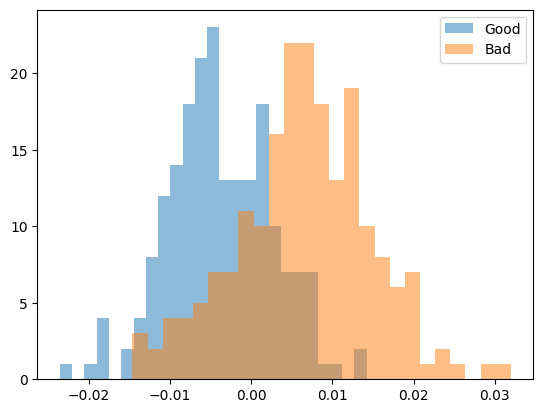

In [69]:
# # Plot good & bad kl increase
# plt.hist(good_kl_increases, bins=25, alpha=0.5, label="Good")
# plt.hist(bad_kl_increases, bins=25, alpha=0.5, label="Bad")
# plt.legend()
# plt.show()

In [133]:


# bad_val, bad_ind = torch.tensor(batch_avg_pos).topk(100)
# good_val, good_ind = torch.tensor(batch_avg_neg).topk(100)
import torch
import numpy as np
from tqdm import tqdm
from collections import defaultdict
dead_component_mask = freq == 0
dead_component_indices = dead_component_mask.nonzero()[:, 0]

n_samples_per_batch = 100
max_batches = 200
kl_threshold = 0.01



num_dead = len(dead_component_indices)
# We want to run over the data again, but only turn on the good or bad ones
batch_amount = 20

eval_iter = iter(eval_loader)

baseline_kls = []
all_dead_kls = []
max_kl_increases = []

per_datapoint_effect = torch.zeros(len(eval_loader), num_dead)

for batch_idx in tqdm(range(min(max_batches, len(eval_loader))), desc="Processing batches"):
    try:
        batch = next(eval_iter)
    except StopIteration:
        break
        
    batch = batch["input_ids"].to(device)
    
    # Initialize batch-specific accumulators
    batch_pos_scores = np.zeros(num_dead)
    batch_neg_scores = np.zeros(num_dead)
    batch_pos_counts = np.zeros(num_dead)
    batch_neg_counts = np.zeros(num_dead)
    
    # Get original forward pass
    orig_logits, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
        batch, module_names=module_comp
    )
    
    # Calculate causal importances
    causal_importances, _ = calc_causal_importances(
        pre_weight_acts=pre_weight_acts, As=As, gates=gates, detach_inputs=False
    )
    
    # Baseline: all alive components clamped, all dead at 0
    baseline_mask = {k: v.clamp(0, 1) for k, v in causal_importances.items()}
    baseline_mask[module_name][:, :, dead_component_indices] = 0
    # print(f"baseline_mask: {baseline_mask}")
    # print(f"dead_component_indices: {dead_component_indices}")
    baseline_logits = model.forward_with_components(
        batch, components=components, masks=baseline_mask
    )
    baseline_kl = calc_kl_divergence_lm(baseline_logits, orig_logits).item()
    baseline_kls.append(baseline_kl)
    
    # All dead activated to get normalization factor
    all_dead_mask = {k: v.clone() for k, v in baseline_mask.items()}
    all_dead_mask[module_name][:, :, dead_component_indices] = 1
    all_dead_logits = model.forward_with_components(
        batch, components=components, masks=all_dead_mask
    )
    all_dead_kl = calc_kl_divergence_lm(all_dead_logits, orig_logits).item()
    all_dead_kls.append(all_dead_kl)
    max_kl_increase = all_dead_kl - baseline_kl

    max_kl_increases.append(max_kl_increase)

    # Iterate through all dead components
    for i in range(num_dead):
        dead_component_index = dead_component_indices[i]
        dead_component_mask = {k: v.clone() for k, v in baseline_mask.items()}
        dead_component_mask[module_name][:, :, dead_component_index] = 1
        dead_component_logits = model.forward_with_components(
            batch, components=components, masks=dead_component_mask
        )
        dead_component_kl = calc_kl_divergence_lm(dead_component_logits, orig_logits).item()

        per_datapoint_effect[batch_idx, i] = dead_component_kl - baseline_kl
    # if batch_idx == batch_amount:
    #     break


Processing batches:  10%|█         | 20/200 [08:29<1:16:29, 25.50s/it]


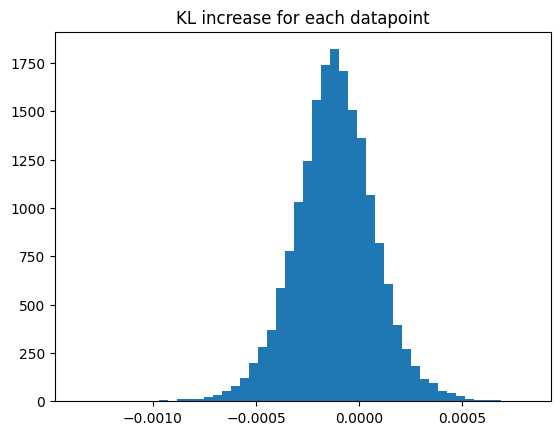

In [134]:
# per_datapoint_effect[0].topk(10, largest=False)
plt.hist(per_datapoint_effect[:10].flatten().cpu().numpy(), bins=50)
plt.title("KL increase for each datapoint")
plt.show()

In [135]:
baseline_kls


[0.2075701653957367,
 0.20433425903320312,
 0.14125314354896545,
 0.20401068031787872,
 0.15791726112365723,
 0.16963502764701843,
 0.208701953291893,
 0.16461972892284393,
 0.1847483217716217,
 0.19115480780601501,
 0.18604177236557007,
 0.1996646225452423,
 0.22144612669944763,
 0.20257793366909027,
 0.17299842834472656,
 0.17708052694797516,
 0.20386260747909546,
 0.1760319173336029,
 0.23111706972122192,
 0.1870097517967224,
 0.18120059370994568]

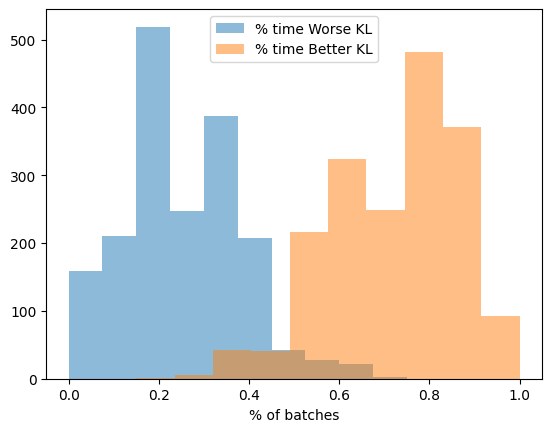

In [251]:
pos_threshold = 1e-5
# pos_threshold = 0
neg_threshold = -pos_threshold

above_pos = per_datapoint_effect[:batch_amount] > pos_threshold
below_neg = per_datapoint_effect[:batch_amount] < neg_threshold

normed_pos = above_pos.sum(dim=0) / batch_amount
normed_neg =  below_neg.sum(dim=0) / batch_amount

# Plot as hist
plt.hist(normed_pos.cpu().numpy(), bins=10, alpha=0.5, label="% time Worse KL")
plt.hist(normed_neg.cpu().numpy(), bins=10, alpha=0.5, label="% time Better KL")
plt.xlabel("% of batches")
plt.legend()
plt.show()

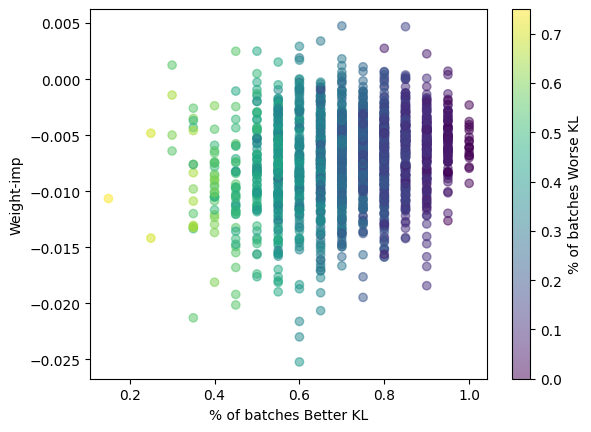

KL helpful: 1518, KL harmful: 25, KL total: 1825
Weight helpful: 1763, Weight harmful: 15, Weight total: 1825
KL helpful, Weight helpful: 1465
KL helpful, Weight harmful: 11
KL harmful, Weight helpful: 25
KL harmful, Weight harmful: 0


In [462]:
# Scatter plot of normed_pos & normed_neg colored by weight-imp
# plt.scatter(normed_pos.cpu().numpy(), normed_neg.cpu().numpy(), c=weight_sim_imp_dead.cpu().numpy(), cmap="viridis", alpha=0.5)
# plt.scatter(normed_pos.cpu().numpy(), normed_neg.cpu().numpy(), c=weight_sim_imp_dead.cpu().numpy(), cmap="viridis", alpha=0.5)
plt.scatter(normed_neg.cpu().numpy(), weight_sim_imp_dead.cpu().numpy(), c=normed_pos.cpu().numpy(), cmap="viridis", alpha=0.5)
plt.colorbar(label="% of batches Worse KL")
# set color bar min to 0
# plt.clim(0, max(weight_sim_imp_dead.cpu().numpy()))
plt.xlabel("% of batches Better KL")
plt.ylabel("Weight-imp")
plt.show()

# Also see how many are net-positive to keep for weight-faithful and kl-faithful

threshold_margin = 0.1
kl_helpful_threshold = 0.5 + threshold_margin
kl_harmful_threshold = 0.5 - threshold_margin

# weight_harmful_threshold = 1e-4 # positive is actually bad for weight-faithful
weight_harmful_threshold = 1e-3# positive is actually bad for weight-faithful
weight_helpful_threshold = -weight_harmful_threshold # negative is actually good for weight-faithful

kl_helpful_mask = (normed_neg >= kl_helpful_threshold)
kl_harmful_mask = (normed_pos >=  kl_helpful_threshold)
# kl_harmful_mask = (normed_neg < kl_harmful_threshold)
weight_helpful_mask = (weight_sim_imp_dead < weight_helpful_threshold)
weight_harmful_mask = (weight_sim_imp_dead > weight_harmful_threshold)

# Count how many are helpful, harmful, and faithful
kl_helpful_count = kl_helpful_mask.sum()
kl_harmful_count = kl_harmful_mask.sum()
weight_helpful_count = weight_helpful_mask.sum()
weight_harmful_count = weight_harmful_mask.sum()

print(f"KL helpful: {kl_helpful_count}, KL harmful: {kl_harmful_count}, KL total: {len(normed_neg)}")
print(f"Weight helpful: {weight_helpful_count}, Weight harmful: {weight_harmful_count}, Weight total: {len(weight_sim_imp_dead)}")

# Now the 2x2 table
kl_helpful_weight_helpful = (kl_helpful_mask & weight_helpful_mask).sum()
kl_helpful_weight_harmful = (kl_helpful_mask & weight_harmful_mask).sum()
kl_harmful_weight_helpful = (kl_harmful_mask & weight_helpful_mask).sum()
kl_harmful_weight_harmful = (kl_harmful_mask & weight_harmful_mask).sum()

print(f"KL helpful, Weight helpful: {kl_helpful_weight_helpful}")
print(f"KL helpful, Weight harmful: {kl_helpful_weight_harmful}")
print(f"KL harmful, Weight helpful: {kl_harmful_weight_helpful}")
print(f"KL harmful, Weight harmful: {kl_harmful_weight_harmful}")

In [453]:
kl_helpful_mask.sum(), weight_helpful_mask.sum(),  (weight_sim_imp_dead < ).sum()

(tensor(945), tensor(1796), tensor(0))

In [461]:
(normed_neg >= 0.6).sum()

tensor(1518)

In [312]:
# Now let's do cos-sim between decoder_vectors of both dead and alive components
# comp_encoders = components[module_name].A # [d_model, n_components]
# comp_decoders = components[module_name].B # [n_components, d_model]
alive_enc_vectors = comp_encoders[:, ~dead_component_mask]
alive_dec_vectors = comp_decoders[~dead_component_mask, :]

dead_enc_vectors = comp_encoders[:, dead_component_mask]
dead_dec_vectors = comp_decoders[dead_component_mask, :]

# Cos-sim between alive_enc_vectors and alive_dec_vectors
# alive_cos_sim = torch.nn.functional.cosine_similarity(alive_enc_vectors, alive_dec_vectors, dim=0)
# dead_cos_sim = torch.nn.functional.cosine_similarity(dead_enc_vectors, dead_dec_vectors, dim=0)

# alive_cos_sim_enc = torch.nn.functional.cosine_similarity(alive_enc_vectors, alive_enc_vectors, dim=0)
# alive_cos_sim_dec = torch.nn.functional.cosine_similarity(alive_dec_vectors, alive_dec_vectors, dim=1)
# Above is only shape [alive_components] but I want [alive_components, alive_components]
# Calculate full cosine similarity matrices for alive components
# For encoders: normalize and then do matmul
alive_enc_norm = torch.nn.functional.normalize(alive_enc_vectors, dim=0)
alive_cos_sim_enc = torch.matmul(alive_enc_norm.T, alive_enc_norm)

# For decoders: normalize and then do matmul 
alive_dec_norm = torch.nn.functional.normalize(alive_dec_vectors, dim=1) 
alive_cos_sim_dec = torch.matmul(alive_dec_norm, alive_dec_norm.T)

dead_enc_norm = torch.nn.functional.normalize(dead_enc_vectors, dim=0)
dead_cos_sim_enc = torch.matmul(dead_enc_norm.T, dead_enc_norm)

dead_dec_norm = torch.nn.functional.normalize(dead_dec_vectors, dim=1)
dead_cos_sim_dec = torch.matmul(dead_dec_norm, dead_dec_norm.T)

alive_dead_cos_sim_enc = torch.matmul(alive_enc_norm.T, dead_enc_norm)
alive_dead_cos_sim_dec = torch.matmul(alive_dec_norm, dead_dec_norm.T)



# dead_cos_sim_enc = torch.nn.functional.cosine_similarity(dead_enc_vectors, dead_enc_vectors, dim=0)
# dead_cos_sim_dec = torch.nn.functional.cosine_similarity(dead_dec_vectors, dead_dec_vectors, dim=1)

# alive_dead_cos_sim_enc = torch.nn.functional.cosine_similarity(alive_enc_vectors, dead_enc_vectors, dim=0)
# alive_dead_cos_sim_dec = torch.nn.functional.cosine_similarity(alive_dec_vectors, dead_dec_vectors, dim=1)

# # Plot as scatter
# plt.scatter(alive_cos_sim.cpu().numpy(), alive_dec_vectors.cpu().numpy(), alpha=0.5, label="Alive")
# plt.scatter(dead_cos_sim.cpu().numpy(), dead_dec_vectors.cpu().numpy(), alpha=0.5, label="Dead")
# plt.legend()

# # Plot as hist
# plt.hist(alive_cos_sim.cpu().numpy(), bins=25, alpha=0.5, label="Alive")
# plt.hist(dead_cos_sim.cpu().numpy(), bins=25, alpha=0.5, label="Dead")
# plt.legend()
alive_cos_sim_enc.shape, alive_cos_sim_dec.shape, alive_dead_cos_sim_enc.shape, alive_dead_cos_sim_dec.shape

(torch.Size([175, 175]),
 torch.Size([175, 175]),
 torch.Size([175, 1825]),
 torch.Size([175, 1825]))

Maximums:
MMCS alive-alive enc: 0.069
MMCS alive-alive dec: 0.041
MMCS dead-dead enc: 0.002
MMCS dead-dead dec: 0.023
MMCS dead-alive enc: 0.042
MMCS dead-alive dec: 0.238
Minimums:
MMCS alive-alive enc: -0.070
MMCS alive-alive dec: -0.040
MMCS dead-dead enc: -0.002
MMCS dead-dead dec: -0.023
MMCS dead-alive enc: -0.042
MMCS dead-alive dec: -0.238


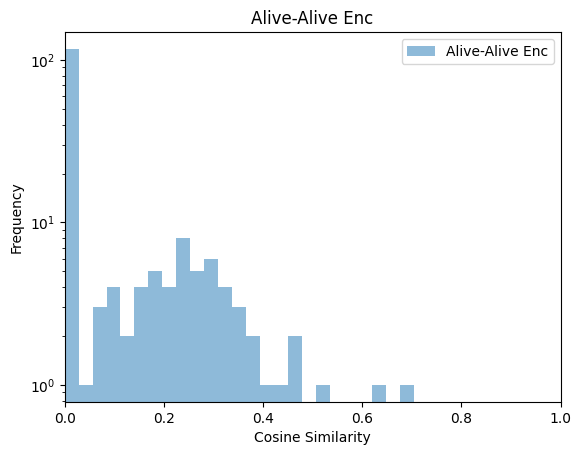

Shape: torch.Size([175, 175])
Max shape: torch.Size([175])


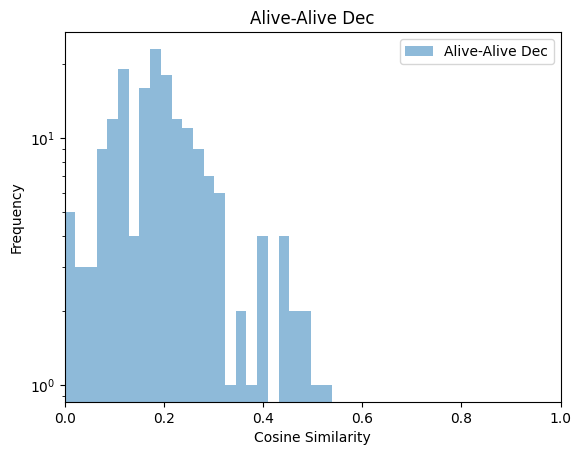

Shape: torch.Size([175, 175])
Max shape: torch.Size([175])


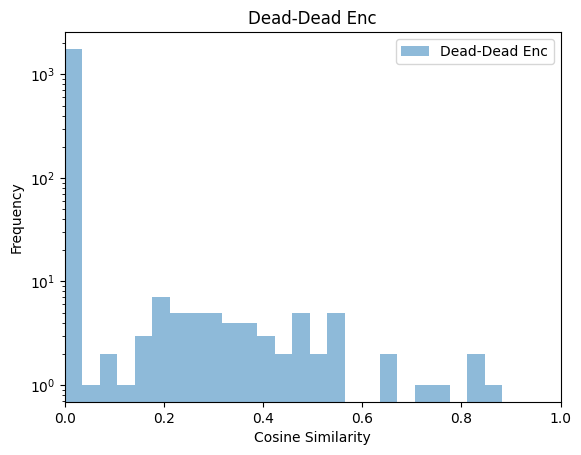

Shape: torch.Size([1825, 1825])
Max shape: torch.Size([1825])


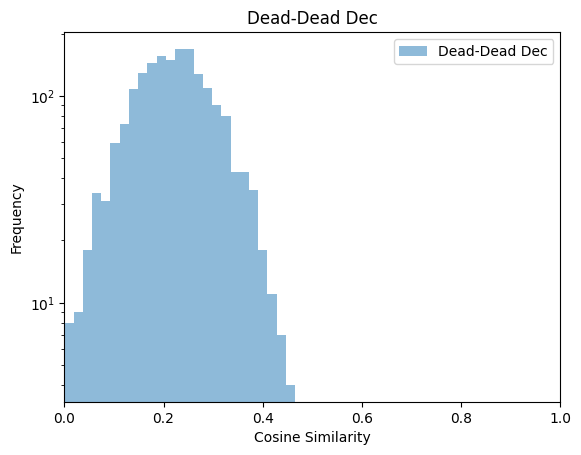

Shape: torch.Size([1825, 1825])
Max shape: torch.Size([1825])


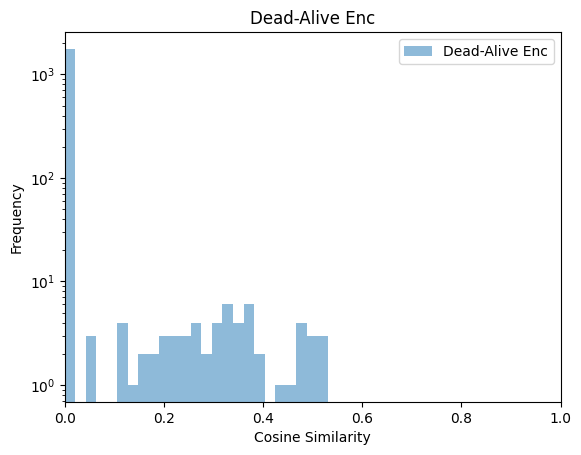

Shape: torch.Size([175, 1825])
Max shape: torch.Size([1825])


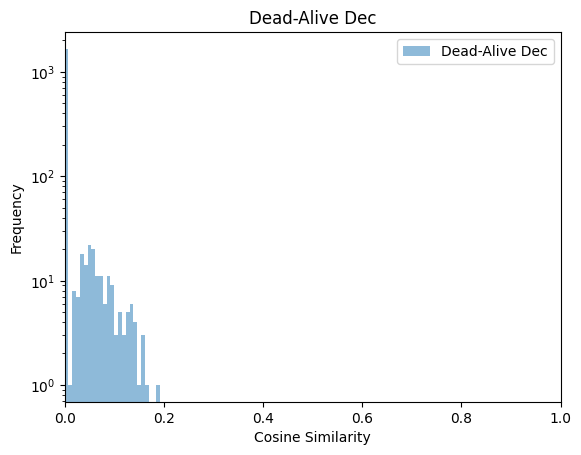

Shape: torch.Size([175, 1825])
Max shape: torch.Size([1825])


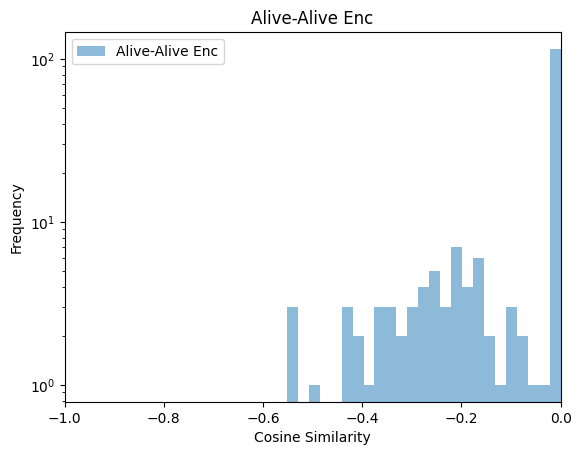

Shape: torch.Size([175, 175])
Max shape: torch.Size([175])


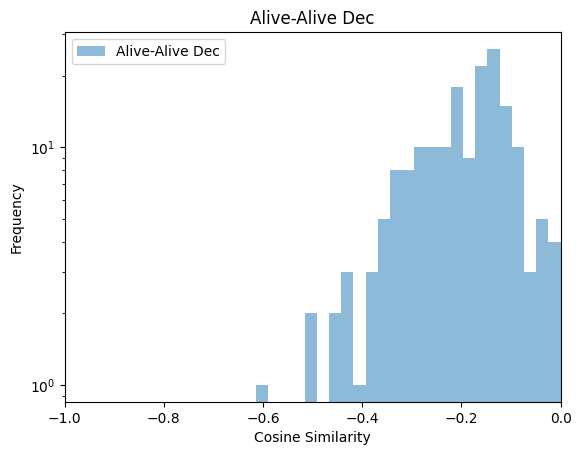

Shape: torch.Size([175, 175])
Max shape: torch.Size([175])


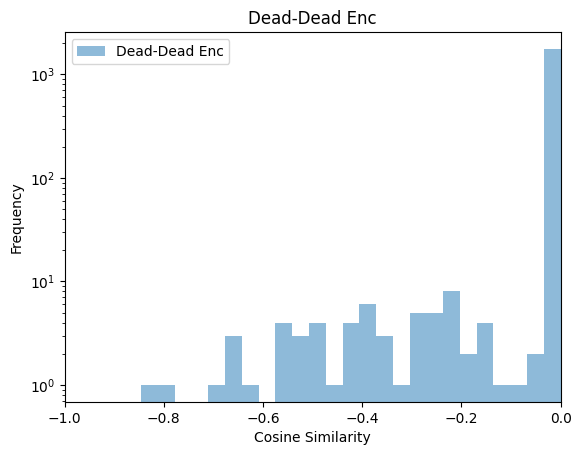

Shape: torch.Size([1825, 1825])
Max shape: torch.Size([1825])


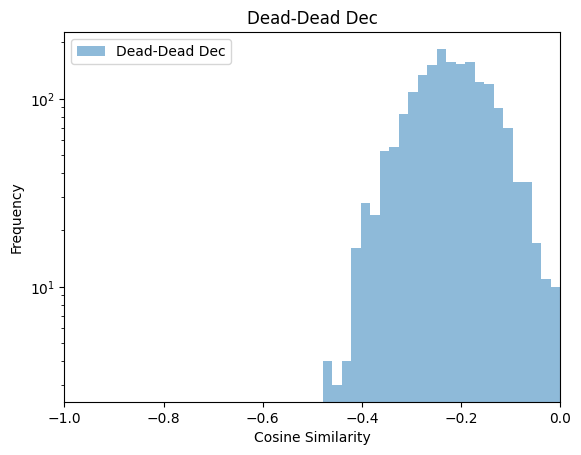

Shape: torch.Size([1825, 1825])
Max shape: torch.Size([1825])


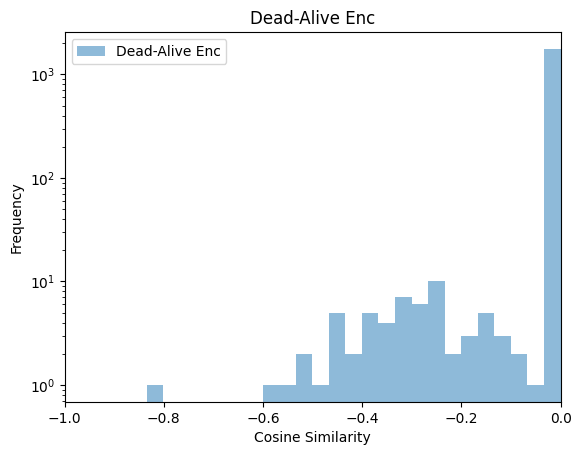

Shape: torch.Size([175, 1825])
Max shape: torch.Size([1825])


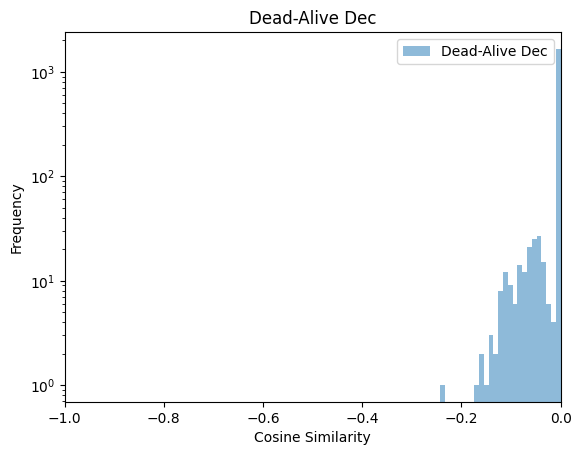

Shape: torch.Size([175, 1825])
Max shape: torch.Size([1825])
Alive-Alive Enc: 0.086
Alive-Alive Dec: 0.200
Dead-Dead Enc: 0.012
Dead-Dead Dec: 0.223
Dead-Alive Enc: 0.010
Dead-Alive Dec: 0.007
Alive-Alive Enc: -0.089
Alive-Alive Dec: -0.202
Dead-Dead Enc: -0.012
Dead-Dead Dec: -0.221
Dead-Alive Enc: -0.010
Dead-Alive Dec: -0.007


In [390]:
# Let's now take the max mean cos-sim
# 1. take max of the lower triangle
# 2. take mean of the max

# 1. lower triangle
alive_enc_vectors = alive_enc_vectors.tril(diagonal=-1)
alive_dec_vectors = alive_dec_vectors.tril(diagonal=-1)
dead_enc_vectors = dead_enc_vectors.tril(diagonal=-1)
dead_dec_vectors = dead_dec_vectors.tril(diagonal=-1)
alive_dead_cos_sim_enc = alive_dead_cos_sim_enc.tril(diagonal=-1)
alive_dead_cos_sim_dec = alive_dead_cos_sim_dec.tril(diagonal=-1)

print(f"Maximums:")
print(f"MMCS alive-alive enc: {alive_enc_vectors.max(dim=0).values.mean():.3f}")
print(f"MMCS alive-alive dec: {alive_dec_vectors.max(dim=1).values.mean():.3f}")

print(f"MMCS dead-dead enc: {dead_enc_vectors.max(dim=0).values.mean():.3f}")
print(f"MMCS dead-dead dec: {dead_dec_vectors.max(dim=1).values.mean():.3f}")

print(f"MMCS dead-alive enc: {alive_dead_cos_sim_enc.max(dim=0).values.mean():.3f}")
print(f"MMCS dead-alive dec: {alive_dead_cos_sim_dec.max(dim=1).values.mean():.3f}")

print(f"Minimums:")
print(f"MMCS alive-alive enc: {alive_enc_vectors.min(dim=0).values.mean():.3f}")
print(f"MMCS alive-alive dec: {alive_dec_vectors.min(dim=1).values.mean():.3f}")

print(f"MMCS dead-dead enc: {dead_enc_vectors.min(dim=0).values.mean():.3f}")
print(f"MMCS dead-dead dec: {dead_dec_vectors.min(dim=1).values.mean():.3f}")

print(f"MMCS dead-alive enc: {alive_dead_cos_sim_enc.min(dim=0).values.mean():.3f}")
print(f"MMCS dead-alive dec: {alive_dead_cos_sim_dec.min(dim=1).values.mean():.3f}")

def get_mmcs(v1, v2, plot_hist=False, title="MMCS", max=True):
    # assert v1.shape[1] == v2.shape[0]
    v1_norm = torch.nn.functional.normalize(v1, dim=0)
    v2_norm = torch.nn.functional.normalize(v2, dim=1)
    mmcs = torch.matmul(v1_norm.T, v2_norm)
    mmcs_lower = mmcs.tril(diagonal=-1)
    if max:
        mmcs_max = mmcs_lower.max(dim=0).values
        mmcs_mean = mmcs_max.mean()
    else:
        mmcs_max = mmcs_lower.min(dim=0).values
        mmcs_mean = mmcs_max.mean()
    if plot_hist:
        plt.hist(mmcs_max.cpu().numpy(), bins=25, alpha=0.5, label=title)
        plt.legend()
        plt.title(title)
        plt.xlabel("Cosine Similarity")
        plt.ylabel("Frequency")
        plt.yscale("log")
        if max:
            plt.xlim(0, 1)
        else:
            plt.xlim(-1, 0)
        plt.show()
    print(f"Shape: {mmcs.shape}")
    print(f"Max shape: {mmcs_max.shape}")
    return mmcs_max, mmcs_mean

mmcs_a_a_enc, mmcs_a_a_enc_mean = get_mmcs(alive_enc_vectors, alive_enc_vectors, plot_hist=True, title="Alive-Alive Enc")
mmcs_a_a_dec, mmcs_a_a_dec_mean = get_mmcs(alive_dec_vectors.T, alive_dec_vectors.T, plot_hist=True, title="Alive-Alive Dec")
mmcs_d_d_enc, mmcs_d_d_enc_mean = get_mmcs(dead_enc_vectors, dead_enc_vectors, plot_hist=True, title="Dead-Dead Enc")
mmcs_d_d_dec, mmcs_d_d_dec_mean = get_mmcs(dead_dec_vectors.T, dead_dec_vectors.T, plot_hist=True, title="Dead-Dead Dec")
mmcs_d_a_enc, mmcs_d_a_enc_mean = get_mmcs(alive_enc_vectors, dead_enc_vectors, plot_hist=True, title="Dead-Alive Enc")
mmcs_d_a_dec, mmcs_d_a_dec_mean = get_mmcs(alive_dec_vectors.T, dead_dec_vectors.T, plot_hist=True, title="Dead-Alive Dec")

min_cs_a_a_enc, min_cs_a_a_enc_mean = get_mmcs(alive_enc_vectors, alive_enc_vectors, plot_hist=True, title="Alive-Alive Enc", max=False)
min_cs_a_a_dec, min_cs_a_a_dec_mean = get_mmcs(alive_dec_vectors.T, alive_dec_vectors.T, plot_hist=True, title="Alive-Alive Dec", max=False)
min_cs_d_d_enc, min_cs_d_d_enc_mean = get_mmcs(dead_enc_vectors, dead_enc_vectors, plot_hist=True, title="Dead-Dead Enc", max=False)
min_cs_d_d_dec, min_cs_d_d_dec_mean = get_mmcs(dead_dec_vectors.T, dead_dec_vectors.T, plot_hist=True, title="Dead-Dead Dec", max=False)
min_cs_d_a_enc, min_cs_d_a_enc_mean = get_mmcs(alive_enc_vectors, dead_enc_vectors, plot_hist=True, title="Dead-Alive Enc", max=False)
min_cs_d_a_dec, min_cs_d_a_dec_mean = get_mmcs(alive_dec_vectors.T, dead_dec_vectors.T, plot_hist=True, title="Dead-Alive Dec", max=False)

print(f"Alive-Alive Enc: {mmcs_a_a_enc_mean:.3f}")
print(f"Alive-Alive Dec: {mmcs_a_a_dec_mean:.3f}")
print(f"Dead-Dead Enc: {mmcs_d_d_enc_mean:.3f}")
print(f"Dead-Dead Dec: {mmcs_d_d_dec_mean:.3f}")
print(f"Dead-Alive Enc: {mmcs_d_a_enc_mean:.3f}")
print(f"Dead-Alive Dec: {mmcs_d_a_dec_mean:.3f}")

print(f"Alive-Alive Enc: {min_cs_a_a_enc_mean:.3f}")
print(f"Alive-Alive Dec: {min_cs_a_a_dec_mean:.3f}")
print(f"Dead-Dead Enc: {min_cs_d_d_enc_mean:.3f}")
print(f"Dead-Dead Dec: {min_cs_d_d_dec_mean:.3f}")
print(f"Dead-Alive Enc: {min_cs_d_a_enc_mean:.3f}")
print(f"Dead-Alive Dec: {min_cs_d_a_dec_mean:.3f}")

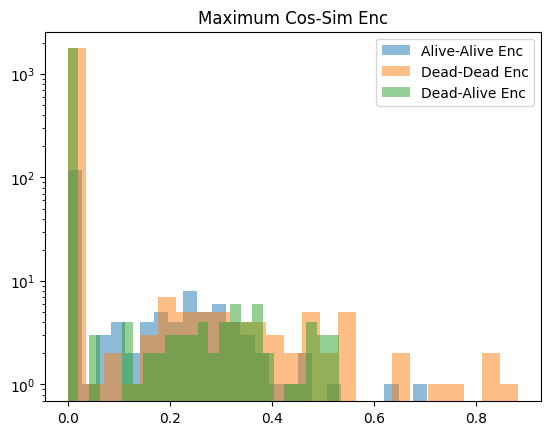

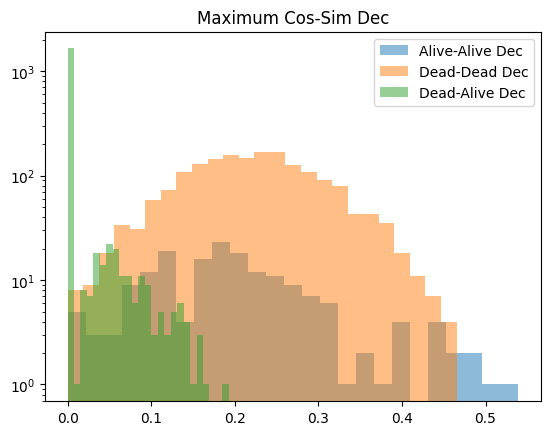

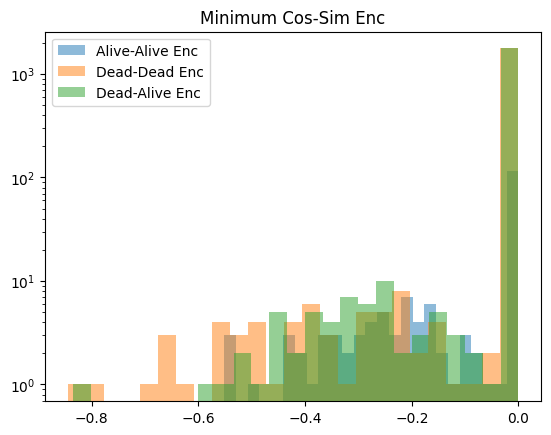

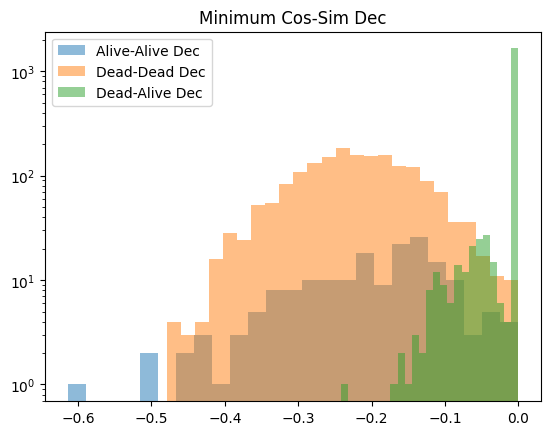

In [391]:
# mmcs_a_a_enc, mmcs_a_a_enc_mean = get_mmcs(alive_enc_vectors, alive_enc_vectors, plot_hist=True, title="Alive-Alive Enc")
# mmcs_a_a_dec, mmcs_a_a_dec_mean = get_mmcs(alive_dec_vectors.T, alive_dec_vectors.T, plot_hist=True, title="Alive-Alive Dec")
# mmcs_d_d_enc, mmcs_d_d_enc_mean = get_mmcs(dead_enc_vectors, dead_enc_vectors, plot_hist=True, title="Dead-Dead Enc")
# mmcs_d_d_dec, mmcs_d_d_dec_mean = get_mmcs(dead_dec_vectors.T, dead_dec_vectors.T, plot_hist=True, title="Dead-Dead Dec")
# mmcs_d_a_enc, mmcs_d_a_enc_mean = get_mmcs(alive_enc_vectors, dead_enc_vectors, plot_hist=True, title="Dead-Alive Enc")
# mmcs_d_a_dec

# Plot encoders together on same plot
plt.hist(mmcs_a_a_enc.cpu().numpy(), bins=25, alpha=0.5, label="Alive-Alive Enc")
plt.hist(mmcs_d_d_enc.cpu().numpy(), bins=25, alpha=0.5, label="Dead-Dead Enc")
plt.hist(mmcs_d_a_enc.cpu().numpy(), bins=25, alpha=0.5, label="Dead-Alive Enc")
plt.title("Maximum Cos-Sim Enc")
plt.yscale("log")
plt.legend()
plt.show()

plt.figure()
plt.hist(mmcs_a_a_dec.cpu().numpy(), bins=25, alpha=0.5, label="Alive-Alive Dec")
plt.hist(mmcs_d_d_dec.cpu().numpy(), bins=25, alpha=0.5, label="Dead-Dead Dec")
plt.hist(mmcs_d_a_dec.cpu().numpy(), bins=25, alpha=0.5, label="Dead-Alive Dec")
plt.title("Maximum Cos-Sim Dec")
plt.yscale("log")
plt.legend()
plt.show()

# repeat for mins
plt.figure()
plt.hist(min_cs_a_a_enc.cpu().numpy(), bins=25, alpha=0.5, label="Alive-Alive Enc")
plt.hist(min_cs_d_d_enc.cpu().numpy(), bins=25, alpha=0.5, label="Dead-Dead Enc")
plt.hist(min_cs_d_a_enc.cpu().numpy(), bins=25, alpha=0.5, label="Dead-Alive Enc")
plt.yscale("log")
plt.title("Minimum Cos-Sim Enc")
plt.legend()
plt.show()

plt.figure()
plt.hist(min_cs_a_a_dec.cpu().numpy(), bins=25, alpha=0.5, label="Alive-Alive Dec")
plt.hist(min_cs_d_d_dec.cpu().numpy(), bins=25, alpha=0.5, label="Dead-Dead Dec")
plt.hist(min_cs_d_a_dec.cpu().numpy(), bins=25, alpha=0.5, label="Dead-Alive Dec")
plt.title("Minimum Cos-Sim Dec")
plt.yscale("log")
plt.legend()
plt.show()

In [402]:
# Now check correlation between all the enc-dec similarities w/ [weight-sim, enc_norm, dec_norm, freq for alive, & normed_neg/pos]
# weight_sim_imp_dead
# alive_weight_sim = weight_importance_alive.cpu().numpy()
def get_correlations(vector, alive=None, title="Correlations"):
    print(f"\nCorrelations for {title}\n----------------------------------")
    np_vector = vector.cpu().numpy()
    assert alive is not None 
    if alive:
        # check_correlation with [weight-sim, enc_norm, dec_norm, freq for alive, & normed_neg/pos]
        corr_weight_sim = np.corrcoef(np_vector, weight_sim_imp_alive.cpu().numpy())[0, 1]
        corr_enc_norm = np.corrcoef(np_vector, alive_enc_norm.cpu().numpy())[0, 1]
        corr_dec_norm = np.corrcoef(np_vector, alive_dec_norm.T.cpu().numpy())[0, 1]
        corr_freq_alive = np.corrcoef(np_vector, alive_freq.cpu().numpy())[0, 1]

        # do other mmcs ones
        corr_mmcs_a_a_enc = np.corrcoef(np_vector, mmcs_a_a_enc.cpu().numpy())[0, 1]
        corr_mmcs_a_a_dec = np.corrcoef(np_vector, mmcs_a_a_dec.cpu().numpy())[0, 1]
        # & minimums
        corr_min_mmcs_a_a_enc = np.corrcoef(np_vector, min_cs_a_a_enc.cpu().numpy())[0, 1]
        corr_min_mmcs_a_a_dec = np.corrcoef(np_vector, min_cs_a_a_dec.cpu().numpy())[0, 1]
        # corr_freq_alive = np.corrcoef(np_vector, alive_freq_alive)[0, 1]
        # corr_normed_neg = np.corrcoef(np_vector, alive_normed_neg)[0, 1]
        # corr_normed_pos = np.corrcoef(np_vector, alive_normed_pos)[0, 1]
        # return corr_weight_sim, corr_enc_norm, corr_dec_norm, corr_freq_alive, corr_normed_neg, corr_normed_pos
        print(f"Correlation with weight-sim: {corr_weight_sim:.3f}" + "**" if abs(corr_weight_sim) > 0.5 else f"Correlation with weight-sim: {corr_weight_sim:.3f}")
        print(f"Correlation with enc_norm: {corr_enc_norm:.3f}" + "**" if abs(corr_enc_norm) > 0.5 else f"Correlation with enc_norm: {corr_enc_norm:.3f}")
        print(f"Correlation with dec_norm: {corr_dec_norm:.3f}" + "**" if abs(corr_dec_norm) > 0.5 else f"Correlation with dec_norm: {corr_dec_norm:.3f}")
        print(f"Correlation with freq_alive: {corr_freq_alive:.3f}" + "**" if abs(corr_freq_alive) > 0.5 else f"Correlation with freq_alive: {corr_freq_alive:.3f}")
        print("------------------Max cos-sim--------------")
        print(f"Correlation with mmcs_a_a_enc: {corr_mmcs_a_a_enc:.3f}" + "**" if abs(corr_mmcs_a_a_enc) > 0.5 else f"Correlation with mmcs_a_a_enc: {corr_mmcs_a_a_enc:.3f}")
        print(f"Correlation with mmcs_a_a_dec: {corr_mmcs_a_a_dec:.3f}" + "**" if abs(corr_mmcs_a_a_dec) > 0.5 else f"Correlation with mmcs_a_a_dec: {corr_mmcs_a_a_dec:.3f}")
        print("------------------Min cos-sim--------------")
        print(f"Correlation with min_mmcs_a_a_enc: {corr_min_mmcs_a_a_enc:.3f}" + "**" if abs(corr_min_mmcs_a_a_enc) > 0.5 else f"Correlation with min_mmcs_a_a_enc: {corr_min_mmcs_a_a_enc:.3f}")
        print(f"Correlation with min_mmcs_a_a_dec: {corr_min_mmcs_a_a_dec:.3f}" + "**" if abs(corr_min_mmcs_a_a_dec) > 0.5 else f"Correlation with min_mmcs_a_a_dec: {corr_min_mmcs_a_a_dec:.3f}")


        # print(f"Correlation with freq_alive: {corr_freq_alive:.3f}")
    #     print(f"Correlation with normed_neg: {corr_normed_neg:.3f}")
    #     print(f"Correlation with normed_pos: {corr_normed_pos:.3f}")
    else:
        # check_correlation with [weight-sim, enc_norm, dec_norm, freq for dead, & normed_neg/pos]
        corr_weight_sim = np.corrcoef(np_vector, weight_sim_imp_dead.cpu().numpy())[0, 1]
        corr_enc_norm = np.corrcoef(np_vector, dead_enc_norm.cpu().numpy())[0, 1]
        corr_dec_norm = np.corrcoef(np_vector, dead_dec_norm.T.cpu().numpy())[0, 1]

        corr_normed_neg = np.corrcoef(np_vector, normed_neg.cpu().numpy())[0, 1]
        corr_normed_pos = np.corrcoef(np_vector, normed_pos.cpu().numpy())[0, 1]

        corr_mmcs_d_d_enc = np.corrcoef(np_vector, mmcs_d_d_enc.cpu().numpy())[0, 1]
        corr_mmcs_d_d_dec = np.corrcoef(np_vector, mmcs_d_d_dec.cpu().numpy())[0, 1]
        corr_mmcs_d_a_enc = np.corrcoef(np_vector, mmcs_d_a_enc.cpu().numpy())[0, 1]
        corr_mmcs_d_a_dec = np.corrcoef(np_vector, mmcs_d_a_dec.cpu().numpy())[0, 1]

        corr_min_mmcs_d_d_enc = np.corrcoef(np_vector, min_cs_d_d_enc.cpu().numpy())[0, 1]
        corr_min_mmcs_d_d_dec = np.corrcoef(np_vector, min_cs_d_d_dec.cpu().numpy())[0, 1]
        corr_min_mmcs_d_a_enc = np.corrcoef(np_vector, min_cs_d_a_enc.cpu().numpy())[0, 1]
        corr_min_mmcs_d_a_dec = np.corrcoef(np_vector, min_cs_d_a_dec.cpu().numpy())[0, 1]
        print(f"Correlation with weight-sim: {corr_weight_sim:.3f}" + "**" if abs(corr_weight_sim) > 0.5 else f"Correlation with weight-sim: {corr_weight_sim:.3f}")
        print(f"Correlation with enc_norm: {corr_enc_norm:.3f}" + "**" if abs(corr_enc_norm) > 0.5 else f"Correlation with enc_norm: {corr_enc_norm:.3f}")
        print(f"Correlation with dec_norm: {corr_dec_norm:.3f}" + "**" if abs(corr_dec_norm) > 0.5 else f"Correlation with dec_norm: {corr_dec_norm:.3f}")
        print(f"Correlation with normed_neg: {corr_normed_neg:.3f}" + "**" if abs(corr_normed_neg) > 0.5 else f"Correlation with normed_neg: {corr_normed_neg:.3f}")
        print(f"Correlation with normed_pos: {corr_normed_pos:.3f}" + "**" if abs(corr_normed_pos) > 0.5 else f"Correlation with normed_pos: {corr_normed_pos:.3f}")
        print("------------------Max cos-sim--------------")
        print(f"Correlation with mmcs_d_d_enc: {corr_mmcs_d_d_enc:.3f}" + "**" if abs(corr_mmcs_d_d_enc) > 0.5 else f"Correlation with mmcs_d_d_enc: {corr_mmcs_d_d_enc:.3f}")
        print(f"Correlation with mmcs_d_d_dec: {corr_mmcs_d_d_dec:.3f}" + "**" if abs(corr_mmcs_d_d_dec) > 0.5 else f"Correlation with mmcs_d_d_dec: {corr_mmcs_d_d_dec:.3f}")
        print(f"Correlation with mmcs_d_a_enc: {corr_mmcs_d_a_enc:.3f}" + "**" if abs(corr_mmcs_d_a_enc) > 0.5 else f"Correlation with mmcs_d_a_enc: {corr_mmcs_d_a_enc:.3f}")
        print(f"Correlation with mmcs_d_a_dec: {corr_mmcs_d_a_dec:.3f}" + "**" if abs(corr_mmcs_d_a_dec) > 0.5 else f"Correlation with mmcs_d_a_dec: {corr_mmcs_d_a_dec:.3f}")
        print("------------------Min cos-sim--------------")
        print(f"Correlation with min_mmcs_d_d_enc: {corr_min_mmcs_d_d_enc:.3f}" + "**" if abs(corr_min_mmcs_d_d_enc) > 0.5 else f"Correlation with min_mmcs_d_d_enc: {corr_min_mmcs_d_d_enc:.3f}")
        print(f"Correlation with min_mmcs_d_d_dec: {corr_min_mmcs_d_d_dec:.3f}" + "**" if abs(corr_min_mmcs_d_d_dec) > 0.5 else f"Correlation with min_mmcs_d_d_dec: {corr_min_mmcs_d_d_dec:.3f}")
        print(f"Correlation with min_mmcs_d_a_enc: {corr_min_mmcs_d_a_enc:.3f}" + "**" if abs(corr_min_mmcs_d_a_enc) > 0.5 else f"Correlation with min_mmcs_d_a_enc: {corr_min_mmcs_d_a_enc:.3f}")
        print(f"Correlation with min_mmcs_d_a_dec: {corr_min_mmcs_d_a_dec:.3f}" + "**" if abs(corr_min_mmcs_d_a_dec) > 0.5 else f"Correlation with min_mmcs_d_a_dec: {corr_min_mmcs_d_a_dec:.3f}")
    return


get_correlations(mmcs_a_a_enc, alive=True, title="Alive-Alive Enc")
get_correlations(mmcs_a_a_dec, alive=True, title="Alive-Alive Dec")
get_correlations(mmcs_d_d_enc, alive=False, title="Dead-Dead Enc")
get_correlations(mmcs_d_d_dec, alive=False, title="Dead-Dead Dec")
get_correlations(mmcs_d_a_enc, alive=False, title="Dead-Alive Enc")
get_correlations(mmcs_d_a_dec, alive=False, title="Dead-Alive Dec")




Correlations for Alive-Alive Enc
----------------------------------
Correlation with weight-sim: 0.199
Correlation with enc_norm: -0.077
Correlation with dec_norm: -0.016
Correlation with freq_alive: 0.240
------------------Max cos-sim--------------
Correlation with mmcs_a_a_enc: 1.000**
Correlation with mmcs_a_a_dec: -0.279
------------------Min cos-sim--------------
Correlation with min_mmcs_a_a_enc: -0.909**
Correlation with min_mmcs_a_a_dec: 0.327

Correlations for Alive-Alive Dec
----------------------------------
Correlation with weight-sim: 0.465
Correlation with enc_norm: -0.035
Correlation with dec_norm: -0.062
Correlation with freq_alive: 0.437
------------------Max cos-sim--------------
Correlation with mmcs_a_a_enc: -0.279
Correlation with mmcs_a_a_dec: 1.000**
------------------Min cos-sim--------------
Correlation with min_mmcs_a_a_enc: 0.324
Correlation with min_mmcs_a_a_dec: -0.747**

Correlations for Dead-Dead Enc
----------------------------------
Correlation with we

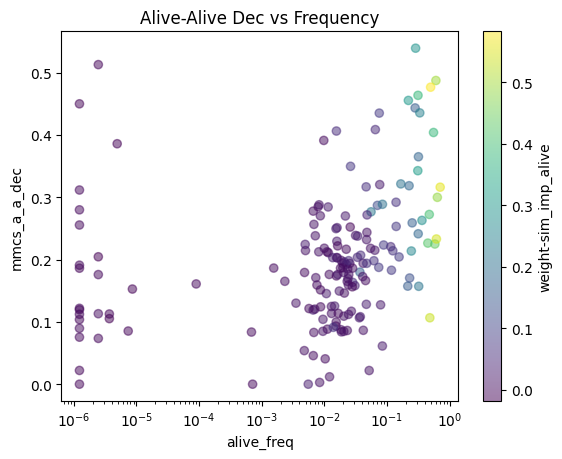

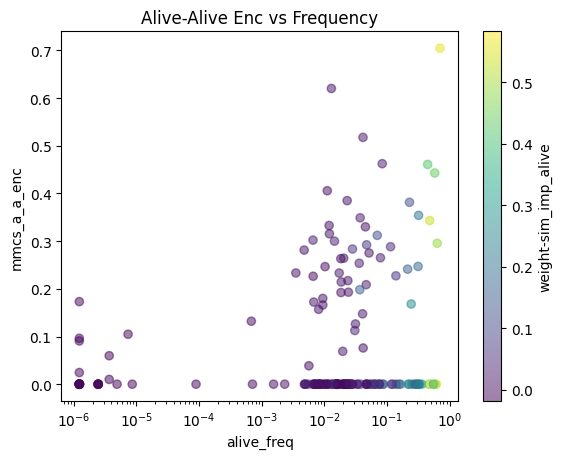

In [385]:
# Plot a_a_dec against freq (logged) & weight-sim (c)
plt.scatter(alive_freq.cpu().numpy(),mmcs_a_a_dec.cpu().numpy(), alpha=0.5, c=weight_sim_imp_alive.cpu().numpy(), cmap="viridis")
plt.xlabel("alive_freq")
plt.ylabel("mmcs_a_a_dec")
plt.xscale("log")
plt.colorbar(label="weight-sim_imp_alive")
plt.title("Alive-Alive Dec vs Frequency")
plt.show()

# Repeat for alive enc
plt.scatter(alive_freq.cpu().numpy(),mmcs_a_a_enc.cpu().numpy(), alpha=0.5, c=weight_sim_imp_alive.cpu().numpy(), cmap="viridis")
plt.xlabel("alive_freq")
plt.ylabel("mmcs_a_a_enc")
plt.xscale("log")
plt.colorbar(label="weight-sim_imp_alive")
plt.title("Alive-Alive Enc vs Frequency")
plt.show()

In [406]:
mmcs_d_d_enc.shape, min_cs_d_d_enc.shape

(torch.Size([1825]), torch.Size([1825]))

torch.Size([175]) torch.Size([175])


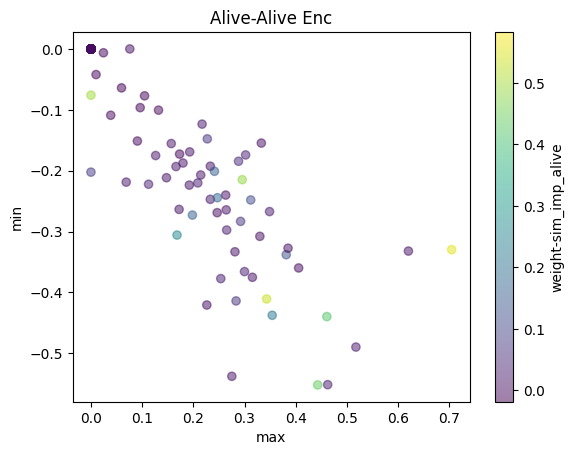

torch.Size([175]) torch.Size([175])


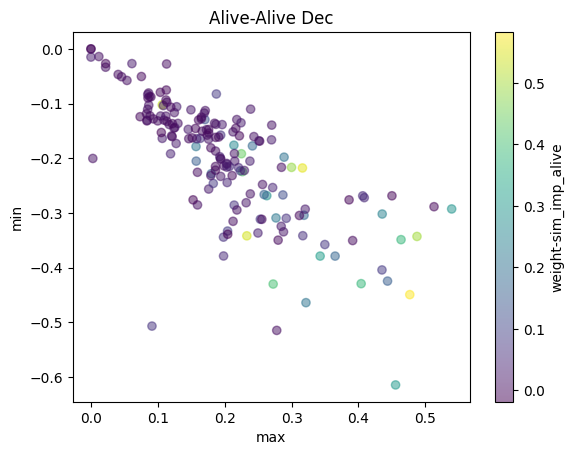

torch.Size([1825]) torch.Size([1825])


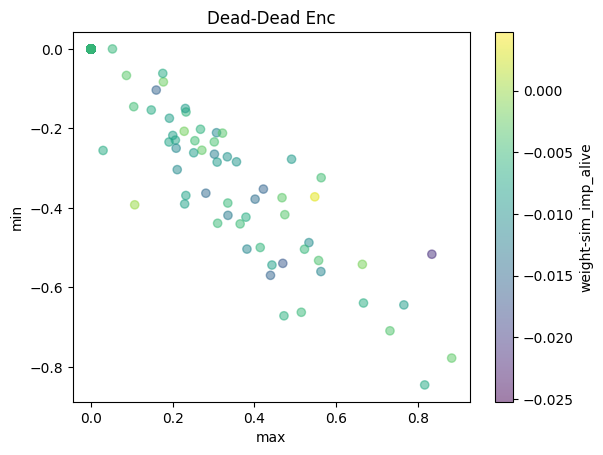

torch.Size([1825]) torch.Size([1825])


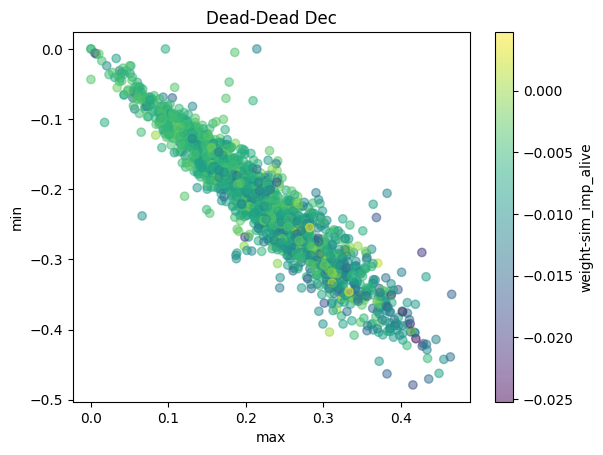

torch.Size([1825]) torch.Size([1825])


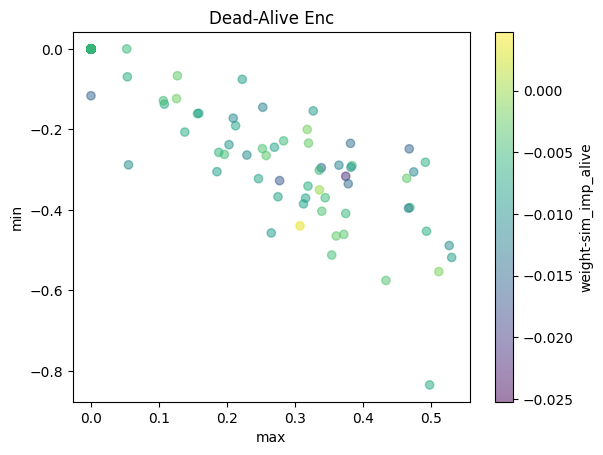

torch.Size([1825]) torch.Size([1825])


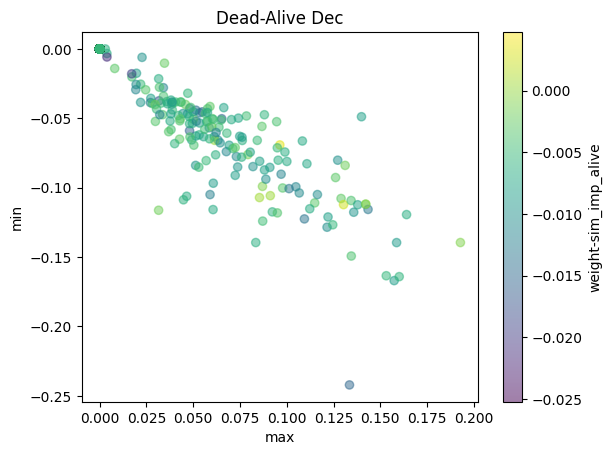

In [408]:
# Correlations for Dead-Alive Enc
# ----------------------------------
# Correlation with weight-sim: -0.026
# Correlation with enc_norm: 0.014
# Correlation with dec_norm: -0.017
# Correlation with normed_neg: -0.016
# Correlation with normed_pos: 0.017
# ------------------Max cos-sim--------------
# Correlation with mmcs_d_d_enc: 0.942**
# Correlation with mmcs_d_d_dec: -0.348
# Correlation with mmcs_d_a_enc: 1.000**
# Correlation with mmcs_d_a_dec: 0.263
# ------------------Min cos-sim--------------
# Correlation with min_mmcs_d_d_enc: -0.958**
# Correlation with min_mmcs_d_d_dec: 0.347
# Correlation with min_mmcs_d_a_enc: -0.949**
# Correlation with min_mmcs_d_a_dec: -0.269

# Plt scatter max & equivalent min
maxes = [mmcs_a_a_enc, mmcs_a_a_dec, mmcs_d_d_enc, mmcs_d_d_dec, mmcs_d_a_enc, mmcs_d_a_dec]
mins = [min_cs_a_a_enc, min_cs_a_a_dec, min_cs_d_d_enc, min_cs_d_d_dec, min_cs_d_a_enc, min_cs_d_a_dec]
labels = ["Alive-Alive Enc", "Alive-Alive Dec", "Dead-Dead Enc", "Dead-Dead Dec", "Dead-Alive Enc", "Dead-Alive Dec"]

for i, (max, min) in enumerate(zip(maxes, mins)):
    weight_sim_c = weight_sim_imp_dead if "Dead" in title_name else weight_sim_imp_alive
    print(max.shape, min.shape)
    plt.figure()
    plt.scatter(max.cpu().numpy(), min.cpu().numpy(), alpha=0.5, c=weight_sim_c.cpu().numpy(), cmap="viridis")
    plt.title(labels[i])
    plt.colorbar(label="weight-sim_imp_alive")
    plt.xlabel("max")
    plt.ylabel("min")
    plt.show()

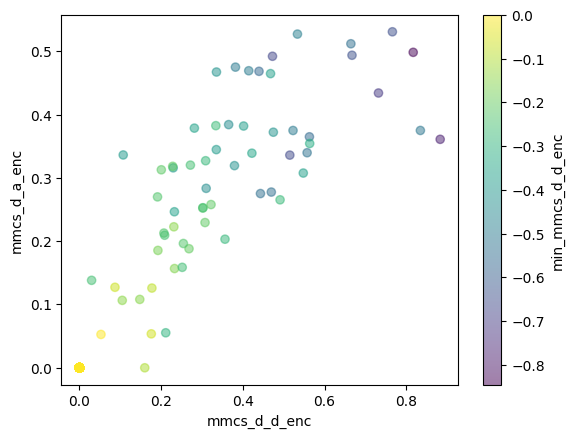

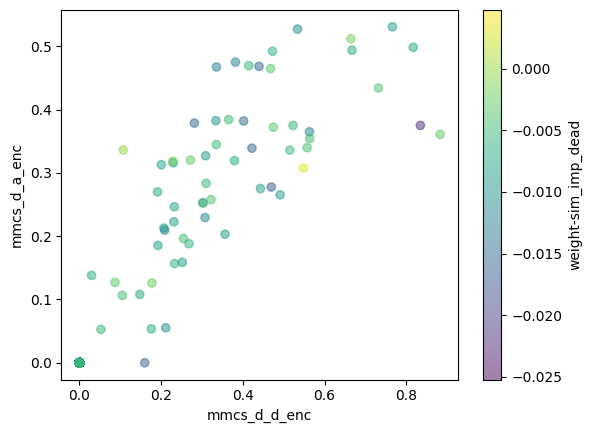

In [418]:
# Correlation with mmcs_d_d_enc: 0.942**
# Correlation with mmcs_d_d_dec: -0.348
# Correlation with mmcs_d_a_enc: 1.000**
# Correlation with mmcs_d_a_dec: 0.263
# ------------------Min cos-sim--------------
# Correlation with min_mmcs_d_d_enc: -0.958**
# Correlation with min_mmcs_d_d_dec: 0.347
# Correlation with min_mmcs_d_a_enc: -0.949**
# Correlation with min_mmcs_d_a_dec: -0.269

plt.scatter(mmcs_d_d_enc.cpu().numpy(), mmcs_d_a_enc.cpu().numpy(), alpha=0.5, c=min_cs_d_d_enc.cpu().numpy(), cmap="viridis")
# plt.scatter(mmcs_d_d_enc.cpu().numpy(), mmcs_d_a_enc.cpu().numpy(), alpha=0.5, c=min_cs_d_a_enc.cpu().numpy(), cmap="viridis")
plt.colorbar(label="min_mmcs_d_d_enc")
plt.xlabel("mmcs_d_d_enc")
plt.ylabel("mmcs_d_a_enc")
plt.show()

plt.scatter(mmcs_d_d_enc.cpu().numpy(), mmcs_d_a_enc.cpu().numpy(), alpha=0.5, c=weight_sim_imp_dead.cpu().numpy(), cmap="viridis")
plt.colorbar(label="weight-sim_imp_dead")
plt.xlabel("mmcs_d_d_enc")
plt.ylabel("mmcs_d_a_enc")
plt.show()

# Compare norm of twins???

In [431]:
mmcs_d_a_enc.shape, mmcs_d_d_enc.shape, dead_encoder_norms.shape
# Not enough, I need to find the norm of the alive components that the dead ones have a max in. 
# Also repeat but for a_d so it's ~275 alive components

(torch.Size([1825]), torch.Size([1825]), torch.Size([1825]))

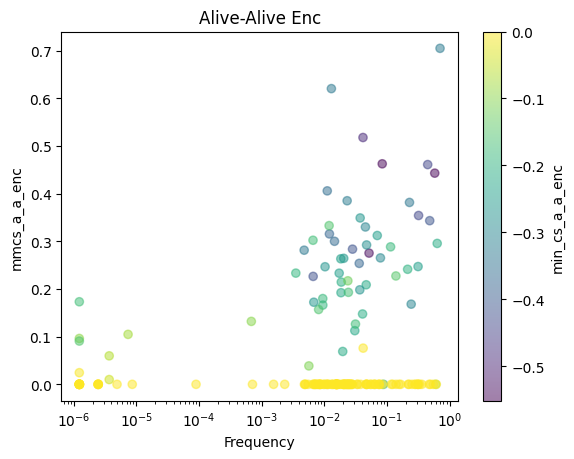

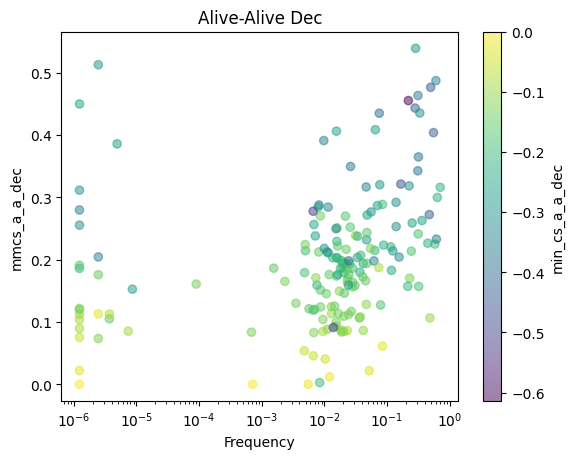

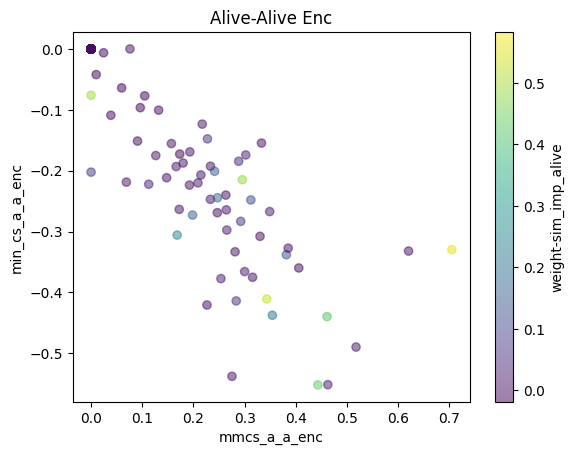

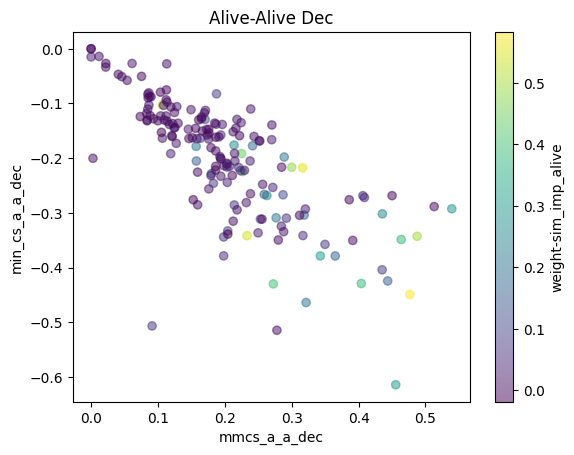

In [417]:
plt.scatter(alive_freq.cpu().numpy(), mmcs_a_a_enc.cpu().numpy(), alpha=0.5, c=min_cs_a_a_enc.cpu().numpy(), cmap="viridis")
plt.colorbar(label="min_cs_a_a_enc")
plt.xlabel("Frequency")
plt.xscale("log")
plt.ylabel("mmcs_a_a_enc")
plt.title("Alive-Alive Enc")
plt.show()

# with w/ Dec
plt.scatter(alive_freq.cpu().numpy(), mmcs_a_a_dec.cpu().numpy(), alpha=0.5, c=min_cs_a_a_dec.cpu().numpy(), cmap="viridis")
plt.colorbar(label="min_cs_a_a_dec")
plt.xlabel("Frequency")
plt.xscale("log")
plt.ylabel("mmcs_a_a_dec")
plt.title("Alive-Alive Dec")
plt.show()

plt.scatter(mmcs_a_a_enc.cpu().numpy(), min_cs_a_a_enc.cpu().numpy(), alpha=0.5, c=weight_sim_imp_alive.cpu().numpy(), cmap="viridis")
plt.colorbar(label="weight-sim_imp_alive")
plt.xlabel("mmcs_a_a_enc")
# plt.xscale("log")
plt.ylabel("min_cs_a_a_enc")
plt.title("Alive-Alive Enc")
plt.show()

# with w/ Dec
plt.scatter(mmcs_a_a_dec.cpu().numpy(), min_cs_a_a_dec.cpu().numpy(), alpha=0.5, c=weight_sim_imp_alive.cpu().numpy(), cmap="viridis")
plt.colorbar(label="weight-sim_imp_alive")
plt.xlabel("mmcs_a_a_dec")
# plt.xscale("log")
plt.ylabel("min_cs_a_a_dec")
plt.title("Alive-Alive Dec")
plt.show()

In [373]:
alive_enc_vectors.shape, weight_sim_imp_alive.shape, mmcs_a_a_enc.shape,mmcs_a_a_dec.shape, mmcs_d_a_enc.shape, mmcs_d_a_dec.shape

(torch.Size([64, 175]),
 torch.Size([175]),
 torch.Size([175]),
 torch.Size([175]),
 torch.Size([1825]),
 torch.Size([1825]))

In [336]:
alive_enc_vectors.max(dim=0).values.shape, alive_dec_vectors.max(dim=1).values.shape, dead_enc_vectors.max(dim=0).values.shape, dead_dec_vectors.max(dim=1).values.shape

(torch.Size([175]), torch.Size([175]), torch.Size([1825]), torch.Size([1825]))

In [255]:
# Scatter plot of normed_pos & normed_neg colored by weight-imp
# plt.scatter(normed_pos.cpu().numpy(), normed_neg.cpu().numpy(), c=weight_sim_imp_dead.cpu().numpy(), cmap="viridis", alpha=0.5)
# plt.scatter(normed_pos.cpu().numpy(), normed_neg.cpu().numpy(), c=weight_sim_imp_dead.cpu().numpy(), cmap="viridis", alpha=0.5)
encoder_norm_dead = encoder_norms[dead_component_mask]
# encoder_norm_alive = encoder_norms[~dead_component_mask]
plt.scatter(normed_neg.cpu().numpy(), weight_sim_imp_dead.cpu().numpy(), c=encoder_norm_dead.cpu().numpy(), cmap="viridis", alpha=0.5)
plt.colorbar(label="% Encoder NormL")
# set color bar min to 0
# plt.clim(0, max(weight_sim_imp_dead.cpu().numpy()))
plt.xlabel("% of batches Better KL")
plt.ylabel("Weight-imp")
plt.show()

NameError: name 'encoder_norms' is not defined

Correlation pos-neg: -0.953
Correlation Worse-KL-dec_norms: 0.280
Correlation Better-KL-dec_norms: -0.260


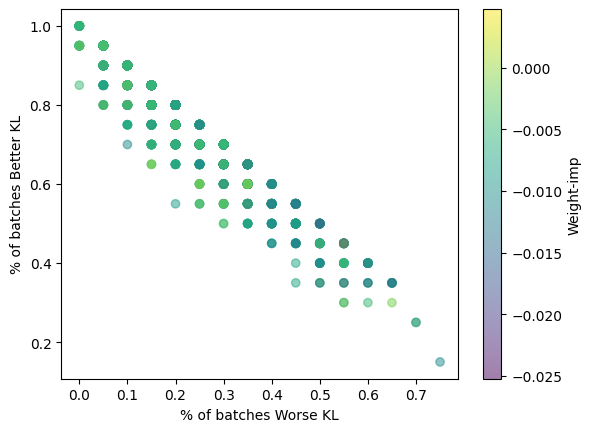

In [253]:
correlation_pos_neg = np.corrcoef(normed_pos.cpu().numpy(), normed_neg.cpu().numpy())[0, 1]
print(f"Correlation pos-neg: {correlation_pos_neg:.3f}")
correlation_pos_dec_norms = np.corrcoef(normed_pos.cpu().numpy(), dec_norms_dead.cpu().numpy())[0, 1]
print(f"Correlation Worse-KL-dec_norms: {correlation_pos_dec_norms:.3f}")
correlation_neg_dec_norms = np.corrcoef(normed_neg.cpu().numpy(), dec_norms_dead.cpu().numpy())[0, 1]
print(f"Correlation Better-KL-dec_norms: {correlation_neg_dec_norms:.3f}")
plt.scatter(normed_pos.cpu().numpy(), normed_neg.cpu().numpy(), c=weight_sim_imp_dead.cpu().numpy(), cmap="viridis", alpha=0.5)
plt.colorbar(label="Weight-imp")
plt.xlabel("% of batches Worse KL")
plt.ylabel("% of batches Better KL")
plt.show()

Correlation: 0.280


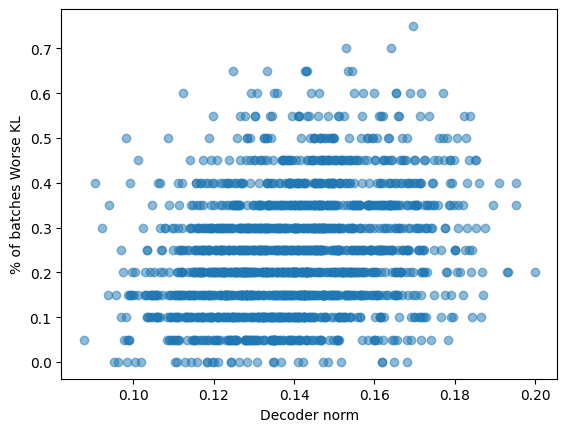

Correlation: -0.260


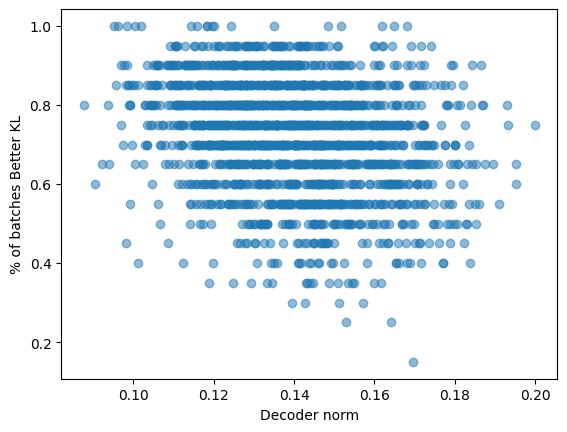

In [254]:
dec_norms_dead.shape
# dead_decoder_norms
correlation = np.corrcoef(dec_norms_dead.cpu().numpy(), normed_pos.cpu().numpy())[0, 1]
print(f"Correlation: {correlation:.3f}")
plt.scatter(dec_norms_dead.cpu().numpy(), normed_pos.cpu().numpy(), alpha=0.5)
plt.xlabel("Decoder norm")
plt.ylabel("% of batches Worse KL")
plt.show()

correlation = np.corrcoef(dec_norms_dead.cpu().numpy(), normed_neg.cpu().numpy())[0, 1]
print(f"Correlation: {correlation:.3f}")
plt.scatter(dec_norms_dead.cpu().numpy(), normed_neg.cpu().numpy(), alpha=0.5)
plt.xlabel("Decoder norm")
plt.ylabel("% of batches Better KL")
plt.show()

In [198]:
kl_mean = per_datapoint_effect[:batch_amount].mean(dim=0)
kl_std = per_datapoint_effect[:batch_amount].std(dim=0)
kl_max = per_datapoint_effect[:batch_amount].max(dim=0).values
kl_min = per_datapoint_effect[:batch_amount].min(dim=0).values
kl_median = per_datapoint_effect[:batch_amount].median(dim=0).values
# Plot as scatter plot
# plt.scatter(kl_mean.cpu().numpy(), kl_std.cpu().numpy())
# # plot mean vs min

# correlation between median & weight-imp
corr_median_weight_imp = np.corrcoef(kl_median.cpu().numpy(), weight_sim_imp_dead.cpu().numpy())[0, 1]
print(f"Correlation median-weight-imp: {corr_median_weight_imp:.3f}")

# correlation between mean & weight-imp
corr_mean_weight_imp = np.corrcoef(kl_mean.cpu().numpy(), weight_sim_imp_dead.cpu().numpy())[0, 1]
print(f"Correlation mean-weight-imp: {corr_mean_weight_imp:.3f}")

# corr between median & dec norm
corr_median_dec_norms = np.corrcoef(kl_median.cpu().numpy(), dec_norms_dead.cpu().numpy())[0, 1]
print(f"Correlation median-dec_norms: {corr_median_dec_norms:.3f}")

# corr between mean & dec norm
corr_mean_dec_norms = np.corrcoef(kl_mean.cpu().numpy(), dec_norms_dead.cpu().numpy())[0, 1]
print(f"Correlation mean-dec_norms: {corr_mean_dec_norms:.3f}")

# Corre between weight-imp and kl

# plt.scatter(kl_mean.cpu().numpy(), kl_min.cpu().numpy())
# plt.xlabel("Mean KL")
# plt.ylabel("min KL")
# plt.show()
# plt.scatter(kl_median.cpu().numpy(), kl_min.cpu().numpy())
# plt.xlabel("Median KL")
# plt.ylabel("min KL")
# plt.show()
# plt.scatter(kl_max.cpu().numpy(), kl_min.cpu().numpy())
# plt.xlabel("Max KL")
# plt.ylabel("min KL")
# plt.show()

Correlation median-weight-imp: -0.175
Correlation mean-weight-imp: -0.195
Correlation median-dec_norms: 0.152
Correlation mean-dec_norms: 0.197


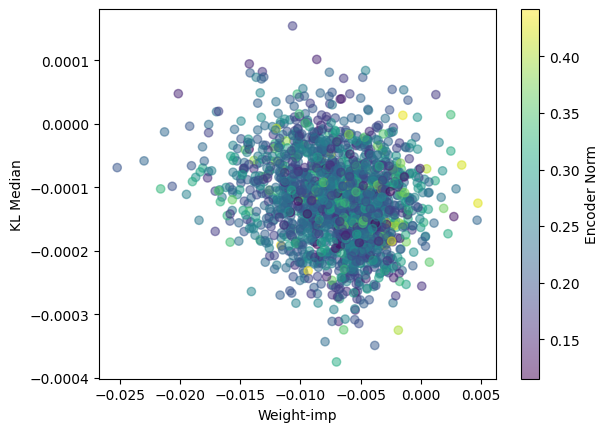

Correlation between weight-imp and kl_mean: -0.195
Correlation between weight-imp and kl_median: -0.175
Correlation between kl_mean and encoder_norms: 0.010
Correlation between kl_median and encoder_norms: 0.013
Correlation between kl_mean and dec_norms: 0.197
Correlation between kl_median and dec_norms: 0.152
Correlation between weight-imp and dec_norms: -0.167


In [292]:
# Plot weight_imp by kl_median
encoder_norms_dead = enc_norms[dead_component_mask]
plt.scatter(weight_sim_imp_dead.cpu().numpy(), kl_mean.cpu().numpy(), alpha=0.5, c=encoder_norms_dead.cpu().numpy(), cmap="viridis")
cbar = plt.colorbar()
cbar.set_label("Encoder Norm")
plt.xlabel("Weight-imp")
plt.ylabel("KL Median")
plt.show()

# Correlation between weight-imp and kl_mean
correlation_weight_imp_kl_mean = np.corrcoef(weight_sim_imp_dead.cpu().numpy(), kl_mean.cpu().numpy())[0, 1]
print(f"Correlation between weight-imp and kl_mean: {correlation_weight_imp_kl_mean:.3f}")

# Correlation between weight-imp and kl_median
correlation_weight_imp_kl_median = np.corrcoef(weight_sim_imp_dead.cpu().numpy(), kl_median.cpu().numpy())[0, 1]
print(f"Correlation between weight-imp and kl_median: {correlation_weight_imp_kl_median:.3f}")

# Correlation between kl_mean and encoder_norms
correlation_kl_mean_encoder_norms = np.corrcoef(kl_mean.cpu().numpy(), encoder_norms_dead.cpu().numpy())[0, 1]
print(f"Correlation between kl_mean and encoder_norms: {correlation_kl_mean_encoder_norms:.3f}")

# Correlation between kl_median and encoder_norms
correlation_kl_median_encoder_norms = np.corrcoef(kl_median.cpu().numpy(), encoder_norms_dead.cpu().numpy())[0, 1]
print(f"Correlation between kl_median and encoder_norms: {correlation_kl_median_encoder_norms:.3f}")

# Correlation between kl_mean and dec_norms
correlation_kl_mean_dec_norms = np.corrcoef(kl_mean.cpu().numpy(), dec_norms_dead.cpu().numpy())[0, 1]
print(f"Correlation between kl_mean and dec_norms: {correlation_kl_mean_dec_norms:.3f}")

# Correlation between kl_median and dec_norms
correlation_kl_median_dec_norms = np.corrcoef(kl_median.cpu().numpy(), dec_norms_dead.cpu().numpy())[0, 1]
print(f"Correlation between kl_median and dec_norms: {correlation_kl_median_dec_norms:.3f}")

# Correlation between weight-imp and dec_norms
correlation_weight_imp_dec_norms = np.corrcoef(weight_sim_imp_dead.cpu().numpy(), dec_norms_dead.cpu().numpy())[0, 1]
print(f"Correlation between weight-imp and dec_norms: {correlation_weight_imp_dec_norms:.3f}")

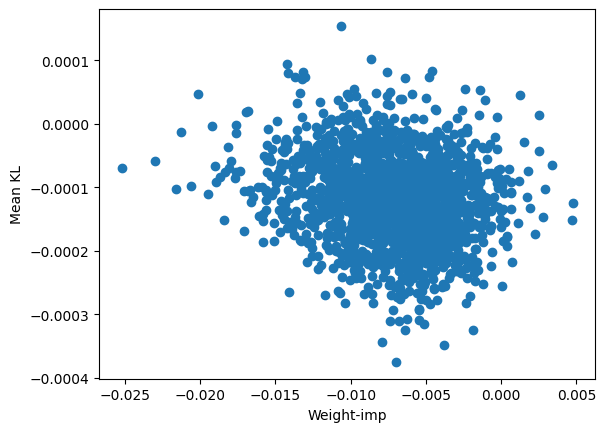

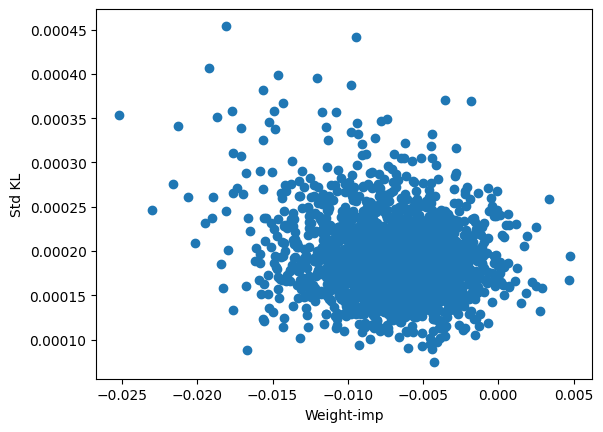

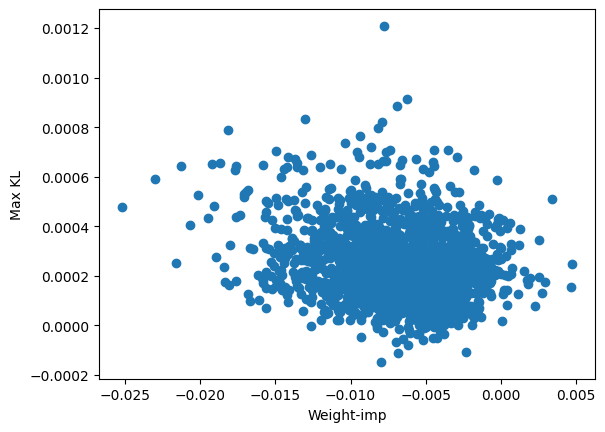

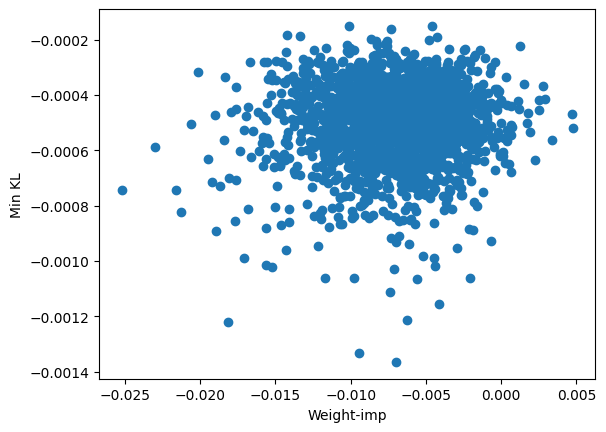

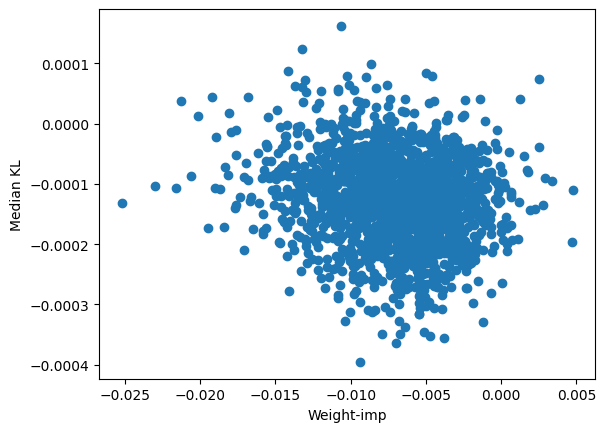

In [155]:
# Scatter plot various stats vs weight-imp & decoder norm
plt.scatter(weight_sim_imp_dead.cpu().numpy(), kl_mean.cpu().numpy())
plt.xlabel("Weight-imp")
plt.ylabel("Mean KL")
plt.show()
plt.scatter(weight_sim_imp_dead.cpu().numpy(), kl_std.cpu().numpy())
plt.xlabel("Weight-imp")
plt.ylabel("Std KL")
plt.show()
plt.scatter(weight_sim_imp_dead.cpu().numpy(), kl_max.cpu().numpy())
plt.xlabel("Weight-imp")
plt.ylabel("Max KL")
plt.show()
plt.scatter(weight_sim_imp_dead.cpu().numpy(), kl_min.cpu().numpy())
plt.xlabel("Weight-imp")
plt.ylabel("Min KL")
plt.show()
plt.scatter(weight_sim_imp_dead.cpu().numpy(), kl_median.cpu().numpy())
plt.xlabel("Weight-imp")
plt.ylabel("Median KL")
plt.show()

In [154]:
weight_sim_importances.shape

torch.Size([2000])

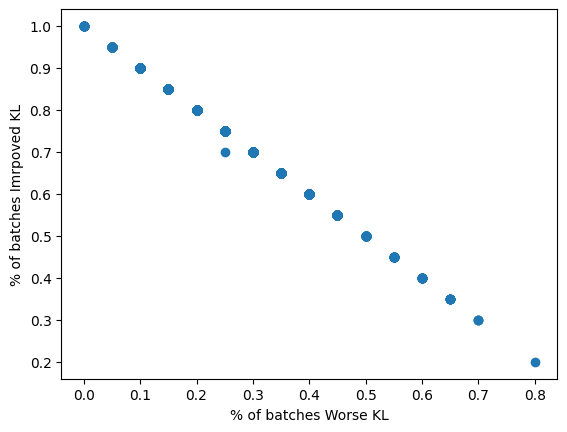

In [146]:
# Scatter plot normed_pos & normed_neg
plt.scatter(normed_pos.cpu().numpy(), normed_neg.cpu().numpy())
plt.xlabel("% of batches Worse KL")
plt.ylabel("% of batches Imrpoved KL")
plt.show()

In [117]:
pos_threshold = 0.01
neg_threshold = -0.01
batch_amount = 20

v, i = per_datapoint_effect[:batch_amount].max(dim=0).values.topk(10)
per_datapoint_effect[:10, i], v
for idx in i:
    # sort by value
    # sorted_indices = torch.argsort(per_datapoint_effect[0, idx])
    # print(f"{per_datapoint_effect[:10, idx].topk(10).values:.1e}")
    # print(f"{per_datapoint_effect[:10, idx].topk(10).values:.1e}")
    # Print in Einstein notation
    print("[", end="")
    values = per_datapoint_effect[:batch_amount, idx].topk(batch_amount).values
    for i, val in enumerate(values):
        print(f"{val:.1e}, ", end="")
    print("]", end="\n")

    # print in einstein notation

    # print(per_datapoint_effec


[2.2e-02, 1.8e-02, 1.7e-02, 1.6e-02, 1.4e-02, 1.4e-02, 1.1e-02, 1.1e-02, 1.0e-02, 1.0e-02, 9.9e-03, 9.2e-03, 8.9e-03, 8.3e-03, 7.9e-03, 7.3e-03, 6.4e-03, 4.9e-03, 4.7e-03, 4.5e-03, ]
[2.1e-02, 1.4e-02, 1.3e-02, 1.2e-02, 1.2e-02, 1.2e-02, 1.0e-02, 9.9e-03, 8.9e-03, 8.6e-03, 8.3e-03, 7.6e-03, 7.5e-03, 7.2e-03, 5.9e-03, 5.7e-03, 5.4e-03, 4.7e-03, 4.6e-03, -7.9e-04, ]
[2.0e-02, 1.3e-02, 1.1e-02, 1.0e-02, 9.5e-03, 9.1e-03, 8.3e-03, 8.1e-03, 7.9e-03, 7.6e-03, 7.4e-03, 7.2e-03, 6.6e-03, 6.1e-03, 6.1e-03, 5.5e-03, 5.2e-03, 4.7e-03, 4.2e-03, 9.9e-04, ]
[2.0e-02, 1.5e-02, 1.4e-02, 1.4e-02, 1.0e-02, 9.8e-03, 9.8e-03, 9.0e-03, 8.8e-03, 8.1e-03, 7.9e-03, 7.2e-03, 6.8e-03, 6.8e-03, 6.5e-03, 6.5e-03, 6.1e-03, 5.6e-03, 4.8e-03, 2.3e-03, ]
[1.9e-02, 1.4e-02, 1.3e-02, 1.2e-02, 1.2e-02, 1.1e-02, 9.6e-03, 9.4e-03, 8.7e-03, 8.5e-03, 7.9e-03, 7.9e-03, 7.6e-03, 7.2e-03, 6.4e-03, 5.2e-03, 5.2e-03, 4.1e-03, 3.7e-03, 1.5e-03, ]
[1.9e-02, 1.6e-02, 1.5e-02, 1.2e-02, 1.2e-02, 1.1e-02, 1.1e-02, 1.0e-02, 9.8e-03, 8.

In [118]:
v, i = per_datapoint_effect[:batch_amount].min(dim=0).values.topk(10, largest=False)
# per_datapoint_effect[:10, i], v
for idx in i:
    # sort by value
    # sorted_indices = torch.argsort(per_datapoint_effect[0, idx])
    # print(f"{per_datapoint_effect[:10, idx].topk(10).values:.1e}")
    # print(f"{per_datapoint_effect[:10, idx].topk(10).values:.1e}")
    # Print in Einstein notation
    print("[", end="")
    values = per_datapoint_effect[:batch_amount, idx].topk(batch_amount, largest=False).values
    for i, val in enumerate(values):
        print(f"{val:.1e}, ", end="")
    print("]", end="\n")

    # print in einstein notation

    # print(per_datapoint_effec


[-7.6e-03, -3.0e-03, -2.3e-03, -2.0e-03, -1.8e-03, -1.4e-03, -1.4e-03, -1.3e-03, -1.1e-03, -1.1e-03, -8.4e-04, -5.2e-04, 1.3e-04, 3.1e-04, 4.8e-04, 4.8e-04, 5.3e-04, 1.2e-03, 1.5e-03, 2.2e-03, ]
[-6.8e-03, -1.6e-03, -1.1e-03, -1.0e-03, -7.4e-04, -4.3e-04, -2.7e-04, 4.1e-04, 4.2e-04, 5.9e-04, 7.3e-04, 7.3e-04, 9.9e-04, 1.0e-03, 1.5e-03, 1.6e-03, 1.8e-03, 1.9e-03, 2.1e-03, 3.1e-03, ]
[-6.4e-03, -2.5e-03, -1.7e-04, 1.0e-03, 1.3e-03, 1.5e-03, 1.9e-03, 1.9e-03, 2.2e-03, 2.4e-03, 2.6e-03, 2.8e-03, 2.8e-03, 3.1e-03, 3.1e-03, 3.1e-03, 4.0e-03, 4.1e-03, 4.7e-03, 5.0e-03, ]
[-5.9e-03, -4.0e-04, -3.2e-04, 7.5e-05, 3.0e-04, 1.6e-03, 1.8e-03, 1.8e-03, 2.2e-03, 2.5e-03, 2.7e-03, 3.1e-03, 3.2e-03, 3.3e-03, 3.5e-03, 3.6e-03, 4.0e-03, 4.8e-03, 5.1e-03, 6.5e-03, ]
[-5.8e-03, -5.1e-04, 1.2e-03, 1.3e-03, 2.2e-03, 2.8e-03, 2.8e-03, 2.9e-03, 3.7e-03, 3.9e-03, 4.0e-03, 4.9e-03, 5.2e-03, 5.6e-03, 6.1e-03, 6.3e-03, 8.5e-03, 8.7e-03, 1.2e-02, 1.2e-02, ]
[-5.7e-03, -3.2e-03, -1.4e-03, -1.3e-03, -1.2e-03, -1.1e-0

In [91]:
per_datapoint_effect[:10, idx].topk(10).values

tensor([ 8.1936e-04,  1.8597e-04,  3.2544e-05, -8.8513e-06, -1.9297e-05,
        -1.7372e-04, -2.0637e-04, -2.4575e-04, -3.6949e-04, -4.0662e-04])

In [ ]:
# Usage example:
# Find dead components
dead_component_mask = freq == 0
dead_component_indices = dead_component_mask.nonzero()[:, 0]

# Estimate importance using weighted co-occurrence
importance_scores, stats = estimate_dead_component_importance(
    model=model,
    eval_loader=eval_loader,
    components=components,
    As=As,
    gates=gates,
    module_name=module_name,
    module_comp=module_comp,
    dead_component_indices=dead_component_indices,
    n_samples_per_batch=20,
    max_batches=10,
    kl_threshold=0.01,
    device=device
)

# Analyze results
print(f"Baseline KL: {stats['baseline_kl']:.4f}")
print(f"All dead KL: {stats['all_dead_kl']:.4f}")
print(f"Found {stats['num_harmful_subsets']} harmful subsets out of {stats['total_samples']} samples ({stats['harmful_ratio']*100:.1f}%)")
print(f"Average harmful subset size: {stats['avg_harmful_subset_size']:.1f}")
print(f"Average KL increase in harmful subsets: {stats['avg_kl_increase_harmful']:.4f}")
print(f"Average normalized score in harmful subsets: {stats['avg_normalized_score_harmful']:.3f}")

# Find most problematic dead components
top_k = 10
top_indices = np.argsort(importance_scores)[::-1][:top_k]
print(f"\\nTop {top_k} most problematic dead components:")
for i, idx in enumerate(top_indices):
    comp_idx = dead_component_indices[idx]
    appearances = stats['component_appearances'][idx]
    print(f"  Component {comp_idx}: Score = {importance_scores[idx]:.4f} (positive: {stats['positive_scores'][idx]:.4f}, negative: {stats['negative_scores'][idx]:.4f}, appearances: {int(appearances)})")

# Look at minimal harmful subsets
print(f"\\nMinimal harmful subsets (removing any component makes them safe):")
for i, subset in enumerate(stats['minimal_harmful_subsets'][:5]):
    component_ids = [dead_component_indices[idx] for idx in subset['indices']]
    print(f"  Subset {i+1} (size={len(subset['indices'])}): KL increase = {subset['kl_increase']:.4f}, normalized = {subset['normalized_score']:.3f}")
    if len(component_ids) <= 10:  # Only show indices for small subsets
        print(f"    Components: {component_ids}")

# Look at maximal safe subsets
print(f"\\nMaximal safe subsets (largest subsets that are still safe):")
for i, subset in enumerate(stats['maximal_safe_subsets'][:5]):
    print(f"  Subset {i+1} (size={len(subset['indices'])}): KL increase = {subset['kl_increase']:.4f}")
    
# Compare sizes
if stats['minimal_harmful_subsets'] and stats['maximal_safe_subsets']:
    avg_minimal_harmful_size = np.mean([len(s['indices']) for s in stats['minimal_harmful_subsets']])
    avg_maximal_safe_size = np.mean([len(s['indices']) for s in stats['maximal_safe_subsets']])
    print(f"\\nAverage minimal harmful subset size: {avg_minimal_harmful_size:.1f}")
    print(f"Average maximal safe subset size: {avg_maximal_safe_size:.1f}")

# Analyze by subset size
print(f"\\nSubset size distribution:")
for size in sorted(stats['subset_size_distribution'].keys())[:10]:
    print(f"  Size {size}: {stats['subset_size_distribution'][size]} samples")

In [ ]:
stats["importance_scores"].shape, stats['positive_scores'].max(), stats['negative_scores'].max()

In [ ]:
stats["positive_scores"], stats["negative_scores"]

In [ ]:
# Example usage code for the improved dead component analysis

# # Find dead components
# dead_component_mask = freq == 0
# dead_component_indices = dead_component_mask.nonzero()[:, 0]

# print(f"Found {len(dead_component_indices)} dead components out of {len(freq)} total")
# print(f"Dead component indices: {dead_component_indices[:10].tolist()}..." if len(dead_component_indices) > 10 else dead_component_indices.tolist())

# # Run the improved analysis
# importance_scores, stats = estimate_dead_component_importance(
#     model=model,
#     eval_loader=eval_loader,
#     components=components,
#     As=As,
#     gates=gates,
#     module_name=module_name,
#     module_comp=module_comp,
#     dead_component_indices=dead_component_indices,
#     n_samples_per_batch=200,  # Increase for better coverage
#     max_batches=20,           # More batches for stable estimates
#     kl_threshold=0.01,
#     marginal_threshold=0.01,  # 1% relative change
#     device=device
# )

# Print basic statistics
print("\n" + "="*80)
print("BASIC STATISTICS")
print("="*80)
print(f"Baseline KL (all dead off): {stats['baseline_kl']:.4f}")
print(f"All dead KL (all dead on): {stats['all_dead_kl']:.4f}")
print(f"Max KL increase possible: {stats['all_dead_kl'] - stats['baseline_kl']:.4f}")
print(f"\nTotal samples evaluated: {stats['total_samples']:,}")
print(f"Unique subsets cached: {stats['subset_cache_size']:,}")
print(f"Harmful subsets found: {stats['num_harmful_subsets']:,} ({stats['harmful_ratio']*100:.1f}%)")

if stats['num_harmful_subsets'] > 0:
    print(f"\nHarmful subset statistics:")
    print(f"  - Average size: {stats['avg_harmful_subset_size']:.1f} components")
    print(f"  - Average KL increase: {stats['avg_kl_increase_harmful']:.4f}")
    print(f"  - Average normalized harm: {stats['avg_normalized_score_harmful']:.3f}")

# Print subset size distribution
print(f"\nSubset size distribution (top 10 sizes):")
size_dist = stats['subset_size_distribution']
for size in sorted(size_dist.keys())[:10]:
    print(f"  Size {size}: {size_dist[size]:,} samples ({size_dist[size]/stats['total_samples']*100:.1f}%)")

# Analyze individual component importance
print("\n" + "="*80)
print("INDIVIDUAL COMPONENT ANALYSIS")
print("="*80)

# Find components with scores
components_with_positive = np.sum(stats['positive_scores'] > 0)
components_with_negative = np.sum(stats['negative_scores'] > 0)
components_with_both = np.sum((stats['positive_scores'] > 0) & (stats['negative_scores'] > 0))

print(f"Components appearing in harmful subsets: {components_with_positive}")
print(f"Components appearing in safe subsets: {components_with_negative}")
print(f"Components appearing in both: {components_with_both}")

# Top harmful components
print(f"\nTop 15 most harmful dead components:")
top_harmful = np.argsort(importance_scores)[::-1][:15]
for rank, idx in enumerate(top_harmful):
    comp_idx = dead_component_indices[idx]
    pos_score = stats['positive_scores'][idx]
    neg_score = stats['negative_scores'][idx]
    net_score = importance_scores[idx]
    print(f"  {rank+1}. Component {comp_idx:4d}: "
          f"Net={net_score:6.4f} (Pos={pos_score:6.4f}, Neg={neg_score:6.4f})")

# Top safe components
print(f"\nTop 10 safest dead components (lowest scores):")
top_safe = np.argsort(importance_scores)[:10]
for rank, idx in enumerate(top_safe):
    comp_idx = dead_component_indices[idx]
    pos_score = stats['positive_scores'][idx]
    neg_score = stats['negative_scores'][idx]
    net_score = importance_scores[idx]
    print(f"  {rank+1}. Component {comp_idx:4d}: "
          f"Net={net_score:6.4f} (Pos={pos_score:6.4f}, Neg={neg_score:6.4f})")

# Minimal harmful subsets analysis
print("\n" + "="*80)
print("MINIMAL HARMFUL SUBSETS")
print("="*80)

if stats['minimal_harmful_subsets']:
    print(f"Found {len(stats['minimal_harmful_subsets'])} minimal harmful subsets\n")
    
    for i, subset in enumerate(stats['minimal_harmful_subsets'][:5]):
        component_ids = [dead_component_indices[idx] for idx in subset['indices']]
        removed_id = dead_component_indices[subset['removed_to_make_safe']] if 'removed_to_make_safe' in subset else None
        
        print(f"Minimal harmful subset {i+1}:")
        print(f"  Size: {subset['size']} components")
        print(f"  KL increase: {subset['kl_increase']:.4f}")
        print(f"  Normalized harm: {subset['normalized_score']:.3f}")
        
        if len(component_ids) <= 10:
            print(f"  Components: {component_ids}")
            if removed_id is not None:
                print(f"  → Remove component {removed_id} to make safe")
        else:
            print(f"  Components: {component_ids[:5]} ... (showing first 5 of {len(component_ids)})")
        
        # Show importance scores of components in this subset
        subset_scores = [(dead_component_indices[idx], importance_scores[idx]) 
                        for idx in subset['indices']]
        subset_scores.sort(key=lambda x: x[1], reverse=True)
        print(f"  Component importance within subset:")
        for comp_id, score in subset_scores[:5]:
            print(f"    - Component {comp_id}: {score:.4f}")
        print()
    
    # Analyze patterns
    all_harmful_components = set()
    for subset in stats['minimal_harmful_subsets']:
        all_harmful_components.update(subset['indices'])
    
    print(f"Total unique components in minimal harmful subsets: {len(all_harmful_components)}")
    print(f"Average minimal harmful subset size: {np.mean([s['size'] for s in stats['minimal_harmful_subsets']]):.1f}")
else:
    print("No minimal harmful subsets found. Try increasing sample size or reducing thresholds.")

# Maximal safe subsets analysis
print("\n" + "="*80)
print("MAXIMAL SAFE SUBSETS")
print("="*80)

if stats['maximal_safe_subsets']:
    print(f"Found {len(stats['maximal_safe_subsets'])} maximal safe subsets\n")
    
    for i, subset in enumerate(stats['maximal_safe_subsets'][:5]):
        component_ids = [dead_component_indices[idx] for idx in subset['indices']]
        next_harmful = dead_component_indices[subset['next_harmful']] if 'next_harmful' in subset else None
        
        print(f"Maximal safe subset {i+1}:")
        print(f"  Size: {subset['size']} components ({subset['size']/len(dead_component_indices)*100:.1f}% of all dead)")
        print(f"  KL increase: {subset['kl_increase']:.4f}")
        print(f"  Safety margin: {subset.get('safety_margin', 0):.4f}")
        
        if len(component_ids) <= 15:
            print(f"  Components: {component_ids}")
        else:
            print(f"  Components: {component_ids[:10]} ... (showing first 10 of {len(component_ids)})")
        
        if next_harmful is not None:
            print(f"  → Adding component {next_harmful} would make it harmful")
        
        # Show score distribution in this subset
        subset_scores = [importance_scores[idx] for idx in subset['indices']]
        print(f"  Score statistics in subset:")
        print(f"    - Mean: {np.mean(subset_scores):.4f}")
        print(f"    - Max: {np.max(subset_scores):.4f}")
        print(f"    - Min: {np.min(subset_scores):.4f}")
        print()
    
    print(f"Largest safe subset size: {max(s['size'] for s in stats['maximal_safe_subsets'])}")
    print(f"Average maximal safe subset size: {np.mean([s['size'] for s in stats['maximal_safe_subsets']]):.1f}")
else:
    print("No maximal safe subsets found. This might indicate:")
    print("  - All components are harmful when activated")
    print("  - Need more samples to find safe combinations")
    print("  - Threshold might be too strict")

# Summary insights
print("\n" + "="*80)
print("SUMMARY INSIGHTS")
print("="*80)

# Compare minimal harmful vs maximal safe sizes
if stats['minimal_harmful_subsets'] and stats['maximal_safe_subsets']:
    avg_minimal_harmful = np.mean([s['size'] for s in stats['minimal_harmful_subsets']])
    avg_maximal_safe = np.mean([s['size'] for s in stats['maximal_safe_subsets']])
    max_safe_size = max(s['size'] for s in stats['maximal_safe_subsets'])
    
    print(f"Average minimal harmful size: {avg_minimal_harmful:.1f} components")
    print(f"Average maximal safe size: {avg_maximal_safe:.1f} components")
    print(f"Largest safe activation: {max_safe_size} components ({max_safe_size/len(dead_component_indices)*100:.1f}% of dead)")
    print(f"Safety threshold: Can activate ~{int(avg_maximal_safe)} components safely")

# Identify critical components (appear frequently in minimal harmful subsets)
if stats['minimal_harmful_subsets']:
    critical_component_counts = defaultdict(int)
    for subset in stats['minimal_harmful_subsets']:
        for idx in subset['indices']:
            critical_component_counts[idx] += 1
    
    print(f"\nMost critical components (appear in many minimal harmful subsets):")
    critical_sorted = sorted(critical_component_counts.items(), key=lambda x: x[1], reverse=True)
    for idx, count in critical_sorted[:10]:
        comp_id = dead_component_indices[idx]
        score = importance_scores[idx]
        print(f"  Component {comp_id}: appears in {count} minimal subsets, importance={score:.4f}")

# Final recommendations
print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

# Calculate percentiles
p90_harmful = np.percentile(importance_scores[importance_scores > 0], 90) if np.any(importance_scores > 0) else 0
p10_harmful = np.percentile(importance_scores[importance_scores > 0], 10) if np.any(importance_scores > 0) else 0

print(f"1. Critical components to investigate (top 10% harmful):")
critical_threshold = p90_harmful
critical_components = [dead_component_indices[i] for i in range(len(importance_scores)) 
                      if importance_scores[i] >= critical_threshold]
print(f"   Components: {critical_components[:10]}... ({len(critical_components)} total)")

print(f"\n2. Safe to activate components (bottom 10% or negative scores):")
safe_threshold = p10_harmful
safe_components = [dead_component_indices[i] for i in range(len(importance_scores)) 
                  if importance_scores[i] <= safe_threshold or importance_scores[i] < 0]
print(f"   Components: {safe_components[:10]}... ({len(safe_components)} total)")

print(f"\n3. Interaction patterns:")
if stats['minimal_harmful_subsets']:
    # Find components that often appear together
    pair_counts = defaultdict(int)
    for subset in stats['minimal_harmful_subsets']:
        indices = subset['indices']
        for i in range(len(indices)):
            for j in range(i+1, len(indices)):
                pair = tuple(sorted([indices[i], indices[j]]))
                pair_counts[pair] += 1
    
    if pair_counts:
        print("   Frequently co-occurring harmful pairs:")
        top_pairs = sorted(pair_counts.items(), key=lambda x: x[1], reverse=True)[:5]
        for (idx1, idx2), count in top_pairs:
            comp1, comp2 = dead_component_indices[idx1], dead_component_indices[idx2]
            print(f"   - Components {comp1} & {comp2}: appear together in {count} minimal subsets")

print(f"\n4. Activation strategy:")
if stats['maximal_safe_subsets']:
    largest_safe = max(s['size'] for s in stats['maximal_safe_subsets'])
    print(f"   - Can safely activate up to {largest_safe} components")
    print(f"   - Avoid activating components with importance > {np.percentile(importance_scores, 75):.4f}")
    print(f"   - Never activate these together: {[dead_component_indices[i] for i in top_harmful[:3]]}")

# Save results for further analysis
print("\n" + "="*80)
print("Results saved to variables:")
print("  - importance_scores: Individual component importance scores")
print("  - stats: Dictionary with all analysis results")
print("  - stats['minimal_harmful_subsets']: List of minimal harmful configurations")
print("  - stats['maximal_safe_subsets']: List of maximal safe configurations")

In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from collections import defaultdict

def estimate_dead_component_importance(
    model,
    eval_loader,
    components,
    As,
    gates,
    module_name,
    module_comp,
    dead_component_indices,
    n_samples_per_batch=100,
    max_batches=10,
    kl_threshold=0.01,  # Minimum KL increase to count as "bad"
    device='cuda'
):
    """
    Estimate importance of dead components using weighted co-occurrence scoring.
    
    Components get weighted points based on their participation in subsets that increase KL divergence.
    The weight is proportional to the KL increase normalized by the maximum possible (all dead).
    
    Args:
        model: The model to evaluate
        eval_loader: DataLoader for evaluation
        components: Component dictionary
        As: Component matrices
        gates: Gate values
        module_name: Name of the module being analyzed
        module_comp: Module component for forward hooks
        dead_component_indices: Indices of dead components
        n_samples_per_batch: Number of subset samples per batch
        max_batches: Maximum number of batches to process
        kl_threshold: Minimum KL increase to count subset as harmful
        device: Device to run on
    
    Returns:
        importance_scores: Score for each dead component (higher = more harmful)
        stats: Dictionary with analysis statistics
    """
    
    num_dead = len(dead_component_indices)
    positive_scores = np.zeros(num_dead)  # Weighted participation in harmful subsets
    negative_scores = np.zeros(num_dead)  # Participation in safe subsets
    
    # Track statistics
    harmful_subsets = []
    subset_size_distribution = defaultdict(int)
    total_samples = 0
    baseline_kls = []
    all_dead_kls = []
    
    eval_iter = iter(eval_loader)
    
    for batch_idx in tqdm(range(min(max_batches, len(eval_loader))), desc="Processing batches"):
        try:
            batch = next(eval_iter)
        except StopIteration:
            break
            
        batch = batch["input_ids"].to(device)
        
        # Get original forward pass
        orig_logits, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
            batch, module_names=module_comp
        )
        
        # Calculate causal importances
        causal_importances, _ = calc_causal_importances(
            pre_weight_acts=pre_weight_acts, As=As, gates=gates, detach_inputs=False
        )
        
        # Baseline: all alive components clamped, all dead at 0
        baseline_mask = {k: v.clamp(0, 1) for k, v in causal_importances.items()}
        baseline_mask[module_name][:, :, dead_component_indices] = 0
        baseline_logits = model.forward_with_components(
            batch, components=components, masks=baseline_mask
        )
        baseline_kl = calc_kl_divergence_lm(baseline_logits, orig_logits).item()
        baseline_kls.append(baseline_kl)
        
        # All dead activated to get normalization factor
        all_dead_mask = baseline_mask.copy()
        all_dead_mask[module_name][:, :, dead_component_indices] = 1
        all_dead_logits = model.forward_with_components(
            batch, components=components, masks=all_dead_mask
        )
        all_dead_kl = calc_kl_divergence_lm(all_dead_logits, orig_logits).item()
        all_dead_kls.append(all_dead_kl)
        max_kl_increase = all_dead_kl - baseline_kl
        
        # Sample random subsets
        for _ in range(n_samples_per_batch):
            # Sample subset size (excluding empty set)
            subset_size = np.random.randint(1, num_dead + 1)
            subset_indices = np.random.choice(num_dead, size=subset_size, replace=False)
            
            # Create mask with this subset activated
            subset_mask = baseline_mask.copy()
            for idx in subset_indices:
                subset_mask[module_name][:, :, dead_component_indices[idx]] = 1
            
            # Calculate KL with subset
            subset_logits = model.forward_with_components(
                batch, components=components, masks=subset_mask
            )
            subset_kl = calc_kl_divergence_lm(subset_logits, orig_logits).item()
            kl_increase = subset_kl - baseline_kl
            
            total_samples += 1
            subset_size_distribution[subset_size] += 1
            
            # Normalized score (0 = no effect, 1 = as bad as all dead)
            normalized_score = kl_increase / max_kl_increase if max_kl_increase > 0 else 0
            
            # If this subset causes significant KL increase, give weighted points to participants
            if kl_increase > kl_threshold:
                for idx in subset_indices:
                    positive_scores[idx] += normalized_score
                
                harmful_subsets.append({
                    'indices': subset_indices.tolist(),
                    'kl_increase': kl_increase,
                    'normalized_score': normalized_score,
                    'size': subset_size
                })
            elif kl_increase < 0.01:  # Safe subset
                for idx in subset_indices:
                    negative_scores[idx] += 1
    
    # Normalize scores by number of samples
    positive_scores /= total_samples
    negative_scores /= total_samples
    
    # Net importance: high if often in harmful subsets, low if often in safe subsets
    importance_scores = positive_scores - 0.1 * negative_scores
    
    # Additional analysis: find minimal harmful subsets
    minimal_harmful_subsets = find_minimal_harmful_subsets(
        harmful_subsets, num_dead, top_k=10
    )
    
    stats = {
        'baseline_kl': np.mean(baseline_kls),
        'all_dead_kl': np.mean(all_dead_kls),
        'total_samples': total_samples,
        'num_harmful_subsets': len(harmful_subsets),
        'harmful_ratio': len(harmful_subsets) / total_samples if total_samples > 0 else 0,
        'avg_harmful_subset_size': np.mean([s['size'] for s in harmful_subsets]) if harmful_subsets else 0,
        'avg_kl_increase_harmful': np.mean([s['kl_increase'] for s in harmful_subsets]) if harmful_subsets else 0,
        'avg_normalized_score_harmful': np.mean([s['normalized_score'] for s in harmful_subsets]) if harmful_subsets else 0,
        'subset_size_distribution': dict(subset_size_distribution),
        'minimal_harmful_subsets': minimal_harmful_subsets,
        'positive_scores': positive_scores,
        'negative_scores': negative_scores
    }
    
    return importance_scores, stats


def find_minimal_harmful_subsets(harmful_subsets, num_components, top_k=10):
    """
    Find minimal harmful subsets (subsets where removing any component makes them safe).
    This helps identify critical interaction patterns.
    """
    if not harmful_subsets:
        return []
    
    # Sort by normalized score (most harmful relative to size)
    sorted_subsets = sorted(harmful_subsets, key=lambda x: x['normalized_score'], reverse=True)
    
    minimal_subsets = []
    for subset in sorted_subsets[:top_k*5]:  # Check more than we need
        indices = set(subset['indices'])
        
        # Check if this is minimal (no proper subset is also harmful)
        is_minimal = True
        for other in harmful_subsets:
            other_indices = set(other['indices'])
            if other_indices < indices:  # Proper subset
                is_minimal = False
                break
        
        if is_minimal:
            minimal_subsets.append(subset)
            if len(minimal_subsets) >= top_k:
                break
    
    return minimal_subsets


# Usage example:
# Find dead components
dead_component_mask = freq == 0
dead_component_indices = dead_component_mask.nonzero()[:, 0]

# Estimate importance using weighted co-occurrence
importance_scores, stats = estimate_dead_component_importance(
    model=model,
    eval_loader=eval_loader,
    components=components,
    As=As,
    gates=gates,
    module_name=module_name,
    module_comp=module_comp,
    dead_component_indices=dead_component_indices,
    n_samples_per_batch=200,
    max_batches=20,
    kl_threshold=0.01,
    device=device
)

# Analyze results
print(f"Baseline KL: {stats['baseline_kl']:.4f}")
print(f"All dead KL: {stats['all_dead_kl']:.4f}")
print(f"Found {stats['num_harmful_subsets']} harmful subsets out of {stats['total_samples']} samples ({stats['harmful_ratio']*100:.1f}%)")
print(f"Average harmful subset size: {stats['avg_harmful_subset_size']:.1f}")
print(f"Average KL increase in harmful subsets: {stats['avg_kl_increase_harmful']:.4f}")
print(f"Average normalized score in harmful subsets: {stats['avg_normalized_score_harmful']:.3f}")

# Find most problematic dead components
top_k = 10
top_indices = np.argsort(importance_scores)[::-1][:top_k]
print(f"\\nTop {top_k} most problematic dead components:")
for i, idx in enumerate(top_indices):
    comp_idx = dead_component_indices[idx]
    print(f"  Component {comp_idx}: Score = {importance_scores[idx]:.4f} (positive: {stats['positive_scores'][idx]:.4f}, negative: {stats['negative_scores'][idx]:.4f})")

# Look at minimal harmful subsets
print(f"\\nMinimal harmful subsets (removing any component makes them safe):")
for i, subset in enumerate(stats['minimal_harmful_subsets'][:5]):
    component_ids = [dead_component_indices[idx] for idx in subset['indices']]
    print(f"  Subset {i+1}: Components {component_ids}, KL increase = {subset['kl_increase']:.4f}, normalized = {subset['normalized_score']:.3f}")

# Analyze by subset size
print(f"\\nSubset size distribution:")
for size in sorted(stats['subset_size_distribution'].keys())[:10]:
    print(f"  Size {size}: {stats['subset_size_distribution'][size]} samples")

In [ ]:
(freq == 0).sum()

In [3]:
# Check most negative cos sim amoung decoder, encoder weights(?)

In [ ]:
exclude_idx = dead_component_mask.tolist()
exclude_indices = [exclude_idx] if isinstance(exclude_idx, int) else exclude_idx
# Create boolean mask for included components
include_mask = torch.tensor([
    i not in exclude_indices for i in range(num_components)
])
include_mask, exclude_indices

In [ ]:
submodule = model.model.get_submodule(module_name)
(submodule.weight **2).sum(), original_loss

In [ ]:
 weight_sim(components, model, exclude_idx = [10, 3])

In [ ]:
num_components, component_params[comp_name].shape, components.items(), target_params[comp_name].shape

In [ ]:
# stochastic_masks, causal_importances
# plot both as a hist
from matplotlib import pyplot as plt
module_name = 'transformer.h.3.mlp.c_fc'
plt.hist(causal_importances[module_name].clamp(min=0).cpu().flatten().numpy(), bins=50)
plt.yscale('log')
plt.title("Causal importances")
plt.show()

plt.hist(stochastic_masks[module_name].clamp(min=0).cpu().flatten().numpy(), bins=50)
plt.title("Stochastic mask")
plt.show()

In [ ]:
# kl_div = F.kl_div(logits_stochastic, orig_logits, reduction='batchmean')
# print(f"KL-divergence stoch: {kl_div}")
# kl_div_o = F.kl_div(orig_logits, logits, reduction='batchmean')
# print(f"KL-divergence orig: {kl_div_o}")

# Above is nans, do log-softmax


In [ ]:
# Let's just plot a bunch of histograms
m_name = "transformer-h-2-mlp-c_fc"
mlp_in_norm = model.gates[m_name].mlp_in.norm(dim=-1)
mlp_out_norm = model.gates[m_name].mlp_out.norm(dim=-1)
from matplotlib import pyplot as plt
plt.hist(mlp_in_norm.cpu().numpy(), bins=50)
plt.title("MLP In Norm")
plt.show()
plt.hist(mlp_out_norm.cpu().numpy(), bins=50)
plt.title("MLP Out Norm")
plt.show()

# biases 
in_bias = model.gates[m_name].in_bias.flatten()
out_bias = model.gates[m_name].out_bias
plt.hist(in_bias.cpu().numpy(), bins=50)
plt.title("MLP In Bias")
plt.show()
plt.hist(out_bias.cpu().numpy(), bins=50)
plt.title("MLP Out Bias")
plt.show()
# weights

In [ ]:
# Plot the range of values for the causal components (ie the target_component_acts)
target_component_acts[m_name.replace("-", ".")][:, :, 0]

In [ ]:
def collate_fn(examples):
    texts = [ex['text'] for ex in examples]
    tokenized = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors='pt'
    )
    return tokenized

dataloader = DataLoader(
    dataset,
    batch_size=32,
    collate_fn=collate_fn,
    shuffle=False
)
module_name = "transformer-h-2-mlp-c_fc"

seq_len = 64

max_datapoints = 1_000
activations_storage = {}
gate_outputs = {}
for module_name, comp_indices in target_modules.items():
    n_components = components[module_name].A.shape[-1]
    activations_storage[module_name] = torch.zeros(max_datapoints, seq_len, n_components)
    gate_outputs[module_name] = torch.zeros(max_datapoints, seq_len, n_components)
module_comp = [key.replace('-', '.') for key in model.components.keys()]
components = {
    k.removeprefix("components.").replace("-", "."): v for k, v in model.components.items()
}
As = {module_name: components[module_name].A for module_name in components}

# If target_modules not specified, track all

total_processed = 0

with torch.no_grad():
    for batch_idx, batch in tqdm(enumerate(dataloader)):
        # print(f"Batch {batch_idx}")
        if total_processed >= max_datapoints:
            break
            
        input_ids = batch['input_ids'].to(device)
        batch_size = input_ids.shape[0]
        
        # Determine how many to process
        n_to_process = min(batch_size, max_datapoints - total_processed)
        
        # Get activations
        _, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
            input_ids[:n_to_process],
            module_names=module_comp
        )
        
        # Calculate component activations
        target_component_acts = calc_component_acts(
            pre_weight_acts=pre_weight_acts, 
            As=As
        )
        masks, sparsity_masks = calc_masks(
                gates=gates, target_component_acts=target_component_acts, detach_inputs=False
        )
        for module_name, comp_indices in target_modules.items():
            if module_name not in target_component_acts:
                continue
            acts = target_component_acts[module_name]
            activations_storage[module_name][total_processed:total_processed + n_to_process] = acts.cpu()
            gate_outputs[module_name][total_processed:total_processed + n_to_process] = masks[module_name].cpu()

        total_processed += n_to_process

In [ ]:
from matplotlib import pyplot as plt
x_acts = activations_storage['transformer.h.2.mlp.c_fc'][:, :, 0].flatten().cpu().numpy()
y_acts = gate_outputs['transformer.h.2.mlp.c_fc'][:, :, 0].flatten().cpu().numpy()
plt.scatter(x_acts, y_acts)
plt.xlabel("Component activations")
plt.ylabel("Gate outputs")
plt.show()

In [ ]:
from matplotlib import pyplot as plt
import numpy as np




# Alternative: If you want to plot different components instead of layers
def plot_components_grid(activations_storage, gate_outputs, n_rows=3, n_cols=4, 
                        same_scale=True, layer_idx=2, component_indices=None):
    """
    Plot multiple components from the same layer in a grid.
    
    Args:
        activations_storage: Dict containing activation data
        gate_outputs: Dict containing gate output data
        n_rows: Number of rows in grid
        n_cols: Number of columns in grid
        same_scale: Whether to use same scale for all plots
        layer_idx: Which layer to plot from
        component_indices: List of component indices to plot (if None, plots 0 to n_rows*n_cols-1)
    """
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    if component_indices is None:
        component_indices = list(range(n_rows * n_cols))
    
    key = f'transformer.h.{layer_idx}.mlp.c_fc'
    
    # Find global scale if needed
    if same_scale:
        global_x_min, global_x_max = float('inf'), float('-inf')
        global_y_min, global_y_max = float('inf'), float('-inf')
        
        for comp_idx in component_indices[:n_rows * n_cols]:
            try:
                x_acts = activations_storage[key][:, :, comp_idx].flatten().cpu().numpy()
                y_acts = gate_outputs[key][:, :, comp_idx].flatten().cpu().numpy()
                
                global_x_min = min(global_x_min, x_acts.min())
                global_x_max = max(global_x_max, x_acts.max())
                global_y_min = min(global_y_min, y_acts.min())
                global_y_max = max(global_y_max, y_acts.max())
            except IndexError:
                pass
    
    # Plot each component
    for i, (ax, comp_idx) in enumerate(zip(axes, component_indices)):
        if i >= n_rows * n_cols:
            break
        
        try:
            x_acts = activations_storage[key][:, :, comp_idx].flatten().cpu().numpy()
            y_acts = gate_outputs[key][:, :, comp_idx].flatten().cpu().numpy()
            
            ax.scatter(x_acts, y_acts, alpha=0.6, s=1)
            
            if i >= (n_rows - 1) * n_cols:
                ax.set_xlabel("Component activations", fontsize=10)
            if i % n_cols == 0:
                ax.set_ylabel("Gate outputs", fontsize=10)
            
            ax.set_title(f"Component {comp_idx}", fontsize=10)
            
            if same_scale:
                ax.set_xlim(global_x_min, global_x_max)
                ax.set_ylim(global_y_min, global_y_max)
            
            ax.grid(True, alpha=0.3)
            
        except IndexError:
            ax.set_visible(False)
    
    plt.tight_layout()
    fig.suptitle(f"Layer {layer_idx}: Activations vs Gate Outputs", fontsize=16, y=1.02)
    plt.show()
# Configuration variables
n_rows = 10  # Number of rows in the grid
n_cols = 5  # Number of columns in the grid
# same_scale = False  # Whether to use the same scale for all subplots
same_scale = True  # Whether to use the same scale for all subplots

# Example usage:
plot_components_grid(activations_storage, gate_outputs, n_rows=n_rows, n_cols=n_cols, same_scale=same_scale, layer_idx=2)

In [ ]:
mod_acts = activations_storage[module_name]

# for i in range(10):
    # plt

plt.scatter(mod_acts[:, 0, 0], pre_weight_acts[:, 0, 0])